In [153]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
import random
import math
import time
import itertools
import pandas as pd

# PARAMETRES DU PLAN D'EXPERIENCE
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 25
NB_ITERATIONS: int = 300

# PARAMETRES DE LA GENERATION DES INSTANCES
FUEL_PRICE_PER_KM: float = 0.15
FORBIDDEN_VERTICES_RATIO: float = 0.05
PRECEDENCE_NODES_RATIO: float = 0.15
TOLL_RATIO: float = 0.2
TOLL_MIN_COST: int = 5
TOLL_MAX_COST: int = 30

# PARAMETRES GENERAUX
PENALTY_COST: int = 1_000_000

# Recherche opérationnelle: résolution d'un problème de tournée de véhicules
Membres du groupe: Timothé FARDELLA, Léo MARTIN, Antoine POUZOULET, Louis LE ROUX, Clément OMNÈS

## 1.0. Introduction

L'ADEME confie à notre structure CesiCDP l'étude et le développement de nouvelles solutions de mobilité multimodale intelligente afin de répondre aux enjeux actuels de réduction des émissions de gaz à effet de serre. Le projet vise à modéliser et optimiser des tournées de livraison sur un réseau routier, tout en minimisant la durée totale des trajets et en assurant une gestion optimisée des ressources. Pour ce faire, dans ce livrable nous établirons la modélisation formelle du problème ainsi que son analyse de complexité. Pour la bonne compréhension des principes mathématiques et de nos modélisations, nous avons choisi de réaliser un contexte qui sera utilisé comme exemple tout au long de ce document. 


### 1.1. Contexte
Le contexte choisi est une boucherie confrontée à un défi logistique lors des fêtes de fin d'année. En effet, pour noël la boucherie à subit un grand nombre de commande à livrer en peu de temps et demande alors à son prestataire de livraison (l’ADEME) de trouver une solution pour livrer les commandes efficacement.

Les villes à livrer sont :
- Paris (Point de départ et d'arrivée - Dépôt)
- Rennes
- Rouen
- Bordeaux
- Toulouse
- Lyon

### 1.2. Objectifs d'optimisation

L'objectif est de minimiser le coût total d'une tournée de livraison, c'est-à-dire trouver le chemin le plus court et le moins coûteux permettant à un véhicule de visiter un ensesmble de villes et de revenir à son point de départ. En réduisant les distances parcourues et en évitant les routes les plus coûteuses, on limite directement la consommation de carburant, les émissions polluantes et le temps de trajet. Dans ce contexte, le gain de temps permettra de livrer les commandes à temps pour le repas de noël et à long terme de diminuer les coûts et les émissions CO2 de livraison.

---

## Table des matières

**1.0.** Introduction
- 1.1. Contexte
- 1.2. Objectifs d'optimisation

**2.0.** Représentation mathématique
- 2.1. Définition des variables

**3.0.** Définition des fonctions
- 3.1. Définition de la fonction objectif
- 3.2. Définition des fonctions contraintes
  - 3.2.1. Contrainte de coût et d'arêtes interdites
  - 3.2.2. Contrainte de précédances

**4.0.** Calcul de complexité
- 4.1. Identification du problème
- 4.2. TSP-PC-ER ∈ NP
- 4.3. Réduction TSP ≤p TSP-PC-ER
- 4.4. Complexité liée aux contraintes

**5.0.** Choix et description des algorithmes

**6.0.** Implémentation
- 6.1. Générateur de graphe
- 6.2. Fonctions utilitaires
- 6.3. Algorithmes et exemples
  - 6.3.1. Colonie de fourmis
  - 6.3.2. Génétique
  - 6.3.3. Hill Climbing Multi Start
  - 6.3.4. Plus Proche Voisin
  - 6.3.5. Recuit simulé
  - 6.3.6. Recherche Tabou

**7.0.** Exploitation
- 7.1. Définition des paramètres globaux
- 7.2. Borne de référence et gap
- 7.3. Pré-calcul des instances et bornes
- 7.4. Algorithmes
  - 7.4.1. Plus Proche Voisin
  - 7.4.2. Hill Climbing Multi-start
  - 7.4.3. Colonie de fourmis
  - 7.4.4. Algorithme Génétique
  - 7.4.5. Recuit simulé
  - 7.4.6. Recuit simulé multi-start
  - 7.4.7. Recherche Tabou
  - 7.4.8. Recherche Tabou 2-opt
- 7.5. Analyse générale
  - 7.5.1. Plus Proche Voisin
  - 7.5.2. Hill Climbing Multi-start
  - 7.5.3. Colonie de fourmis
  - 7.5.4. Algorithme Génétique
  - 7.5.5. Recuit Simulé
  - 7.5.6. Recuit Simulé Multi-start
  - 7.5.7. Recherche Tabou
  - 7.5.8. Recherche Tabou 2-opt
  - 7.5.9. Comparaison générale
- 7.6. Résultats à grande instance
  - 7.6.1. Comparaison des algorithmes
  - 7.6.2. Comparaison temporelle

**8.0.** Conclusion
- 8.1. Synthèse du travail réalisé
- 8.2. Synthèse des résultats expérimentaux
- 8.3. Recommandations
- 8.4. Limites des algorithmes et de l'expérimentation
- 8.5. Pistes d'amélioration

**9.0.** Références bibliographiques

## 2.0. Représentation mathématique

### 2.1. Définition des variables

Soit:
- $G= \{V;E\}$ un graphe comportant un ensemble de sommets et d'arêtes.
- $V= \{v_0, v_1, ..., v_{n-1}\}$ un ensemble de sommets.
- $E= \{ \{u,v\}\ \mid u;v \in V, u \neq v\}$ un ensemble contenant des arêtes non orientées, où chaque élément est une paire de sommets distincts $u$ et $v$ appartenant à $V$.
- $P(u,v) = P_{péage} + (e \times P_{distance})$ le poids associé à l'arête entre $u$ et $v$ et $e$ le prix de l'essence par kilomètre.
- $D$ un ensemble de contraintes de précédances sachant que D ⊆ V×V.
- $x_{u,v} \in \{0, 1\}$ est une variable de décision valant $1$ si l'arête $(u,v)$ est empruntée dans la tournée, $0$ sinon.
- $\forall (u,v) \in D, t_u < t_v$ avec $t_u$ le rang de passage du sommet $u$ et $t_v$ le rang de passage du sommet $v$.

</br>

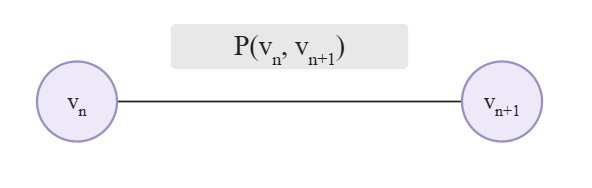

**Ce graphe illustre la modélisation de notre réseau de transport pour le projet CesiCDP. La structure de ce Problème est celle du Voyageur de Commerce (TSP).**

- **Les sommets** : Chaque nœud du graphe correspond à l'une des six villes clés du réseau de distribution. Par exemple, le sommet $v_n$ peut représenter le centre de distribution principal à Paris (point de départ de nos produits), et le sommet $v_{n+1}$ peut désigner Rouen ou Rennes, la prochaine étape où le prestataire logistique doit livrer une commande. 
- **L'arête unique** : Le trait qui relie les deux sommets modélise le réseau routier existant (autoroutes, routes nationales) qu'emprunte le véhicule de l'ADEME pour se rendre de la ville $v_n$ à la ville $v_{n+1}$. Dans notre TSP, le graphe est complet, ce qui signifie qu'il existe une arête entre chaque paire de villes.
- **Le poids ($P(v_n, v_{n+1})$)** : Cette étiquette représente le critère d'optimisation central de notre problème. Elle quantifie l'effort nécessaire pour parcourir cette arête. Dans ce contexte précis, ce poids traduit la distance totale ou le temps de trajet entre deux villes, des facteurs directement corrélés à la consommation énergétique et à l'empreinte carbone.
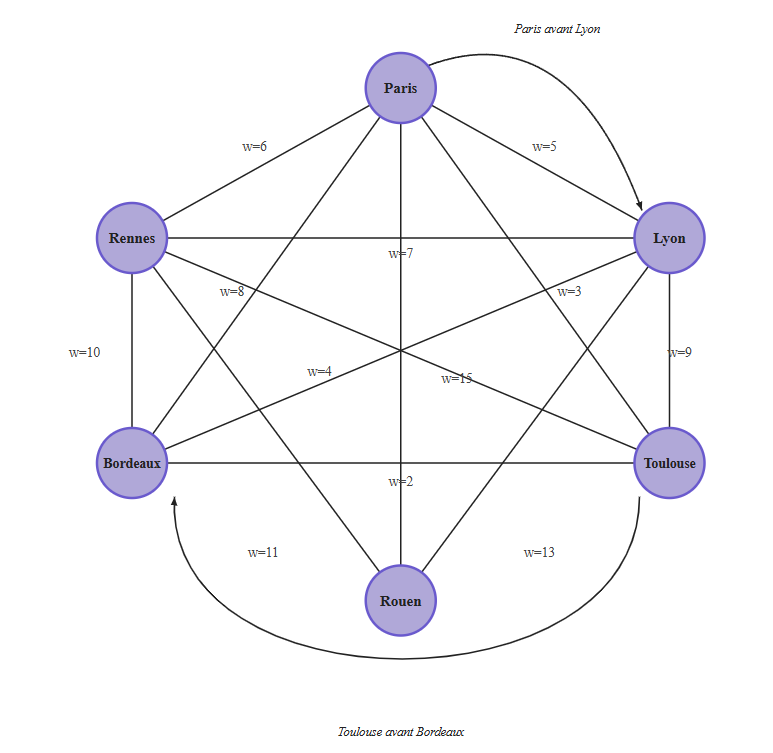
- Le graphe représente une instance du problème TSP-PC-ER appliqué à un réseau de livraison pour une boucherie. Il s'agit d'un graphe complet comportant 6 sommets (villes) et 15 arêtes pondérées.
- **Les sommets représentent les villes à livrer :** $V=\{Rennes,Rouen,Bordeaux,Toulouse,Paris,Lyon\}$
- Les arêtes sont pondérées par la fonction de $\text{coût péage} + \text{le prix de l'essence} \times \text{la distance entre deux villes}$
- Les valeurs $−1$ matérialisent les routes interdites au sens de la contrainte *3.2.1* : ces liaisons ne peuvent pas être empruntées lors de la tournée. Dans notre contexte cela symboliserai une route en travaux qui ne pourra donc pas être empruntée. 
- Les arêtes valides portent des poids entiers positifs représentant le coût de chaque trajet.

---

## 3.0. Définition des fonctions

Dans cette section, nous traduisons le besoin opérationnel de la boucherie en fonctions mathématiques. La démarche suivie est la suivante : identifier la décision logistique à prendre (choisir ou non une arête), associer un coût réel à chaque liaison, puis formaliser les contraintes du terrain (routes interdites et ordre de passage).

Ainsi, les fonctions définies ci-dessous ne sont pas abstraites : elles correspondent directement au contexte de livraison avant Noël, où l'on cherche à minimiser les coûts tout en respectant les contraintes de circulation et d'organisation.

### 3.1. Définition de la fonction objectif

$$\text{min Z} = \sum_{u=0}^{n} \sum_{v=0}^{n} P(u,v) ⋅ x_{(u,v)}$$

L'objectif du problème est de minimiser le coût total du trajet. Le coût d'un trajet dépend de deux éléments déjà définis dans la section 1.0 :

- La variable binaire $x_{u,v} \in \{0,1\}$, qui indique si l'arête entre $u$ et $v$ est utilisée dans la tournée ($1$ = empruntée, $0$ = ignorée).
- Le poids $P(u,v)=P_{péage} + (e \times P_{distance})$, qui représente le coût réel de chaque route, en intégrant les péages et la consommation de carburant.

La somme double sur tous les couples $(u,v)$ agrège le coût total de la tournée, en ne comptant que les arêtes sélectionnées. Les arêtes non retenues (où $x_{u,v}=0$) ne contribuent pas à la somme.

Dans le contexte appliqué, cette fonction objectif correspond à la recherche de la tournée la moins coûteuse pour livrer toutes les villes puis revenir au dépôt (Paris). En minimisant cette quantité, on réduit à la fois les dépenses logistiques, la consommation de carburant et l'impact environnemental.

</br>

### 3.2. Définition des fonctions contraintes

Les contraintes permettent d'intégrer les réalités du problème dans le modèle. Elles évitent de produire une solution mathématiquement optimale mais logistiquement irréaliste.

#### 3.2.1. Contrainte de coût et d'arêtes interdites

Une arête $(u,v)$ est considérée comme interdite lorsque son poids vaut $-1$. On impose alors :

$$x_{u,v} = 0 \ \forall(u,v) \in E \text{ tel que } P(u,v) = -1$$

Cette contrainte traduit le fait qu'une liaison bloquée (ou non autorisée) ne peut jamais être empruntée pendant la tournée.

#### 3.2.2. Contrainte de précédances

Pour toute paire $(u,v) \in D$, la ville $u$ doit être visitée avant la ville $v$:

$$t_u < t_v ∀(u,v) \in D$$

Cette contrainte modélise un ordre de livraison imposé (priorité de certains clients, organisation de tournée, contraintes métier). Elle garantit que la solution retenue reste cohérente avec les exigences opérationnelles du contexte.


## 4.0. Calcul de complexité

### 4.1. Identification du problème

Notre problème est une extension du **problème du Voyageur de Commerce** (TSP — *Travelling Salesman Problem*), noté **TSP-PC-ER**, car il intègre deux contraintes supplémentaires par rapport au TSP classique :

- **PC** (*Precedence Constraints*) — l'ensemble $D \subseteq V \times V$ impose un ordre de visite entre certaines villes : $\forall (u,v) \in D,\ t_u < t_v$
- **ER** (*Edge Restrictions*) — certaines arêtes sont bloquées ($P_n(u,v) = -1$) ou affectées d'un surcoût

La méthode utilisée pour déterminer la complexité d'un problème est la **réduction polynomiale** : on montre qu'un problème déjà connu comme difficile se ramène au nôtre. On s'appuie sur la chaîne suivante :

$$\underbrace{\text{Ham-Cycle}}_{\text{NP-Complet}} \leq_p \underbrace{\text{TSP}}_{\text{NP-Difficile (Karp, 1972)}} \leq_p \underbrace{\text{TSP-PC-ER}}_{\text{notre problème}}$$

La réduction Ham-Cycle $\leq_p$ TSP est un résultat établi de la littérature (Karp, 1972), cité ici comme acquis. Nous démontrons la seconde réduction : **TSP $\leq_p$ TSP-PC-ER**.

### 4.2. TSP-PC-ER $\in$ NP

Un certificat est une liste ordonnée des sommets du circuit. On vérifie en $O(n)$ que :

- chaque sommet apparaît exactement une fois,
- aucune arête empruntée n'est bloquée ($P(u,v) \neq -1$),
- la somme des poids des arêtes consécutives est au plus $k$,
- toutes les contraintes de précédence de $D$ sont respectées.

La vérification est polynomiale, donc :

$$\text{TSP-PC-ER} \in NP$$

### 4.3. Réduction TSP $\leq_p$ TSP-PC-ER


Le TSP classique est un **cas particulier** de notre problème TSP-PC-ER.  
La réduction se construit ainsi : étant donné une instance TSP quelconque — un graphe $G = (V, E, w)$ — on construit une instance TSP-PC-ER en posant :

$$D = \emptyset \qquad \text{et} \qquad P(u,v) = w(\{u,v\}) \quad \forall \{u,v\} \in E$$

- $D = \emptyset$ signifie qu'on ne définit **aucune contrainte de précédence**
- $P(u,v) = w(\{u,v\})$ signifie qu'on recopie les poids tels quels, **sans route bloquée ni surcoût**

Cette transformation ne modifie rien — elle recopie l'instance en $O(1)$, ce qui est triviallement polynomial.

On obtient alors exactement l'instance TSP de départ. On en déduit :

$$\text{TSP} \leq_p \text{TSP-PC-ER}$$

Si on savait résoudre TSP-PC-ER efficacement, on saurait aussi résoudre TSP — ce qui est impossible puisque TSP est NP-Difficile. Les schémas ci-dessous illustrent cette réduction : à gauche le TSP pur (tous les poids à 1, aucune contrainte), à droite le TSP-PC-ER avec ses contraintes. En posant $D = \emptyset$ et $P(u,v) = 1$ partout, on passe du second au premier.

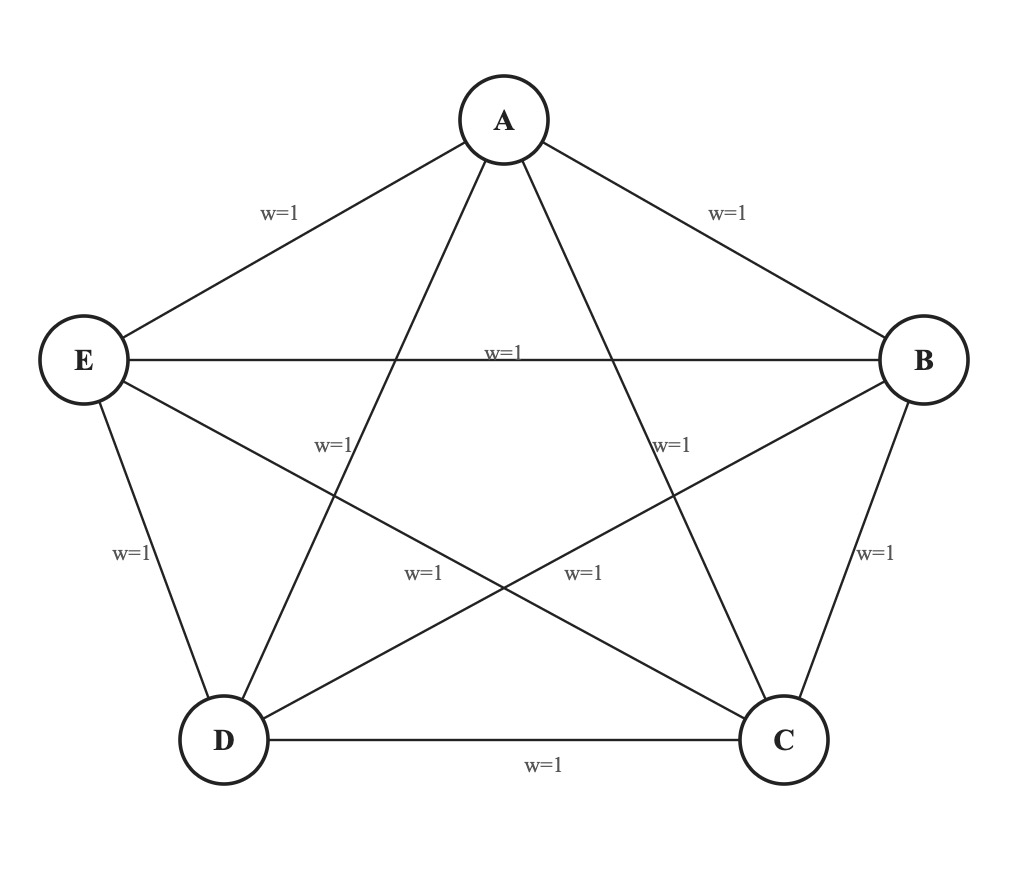
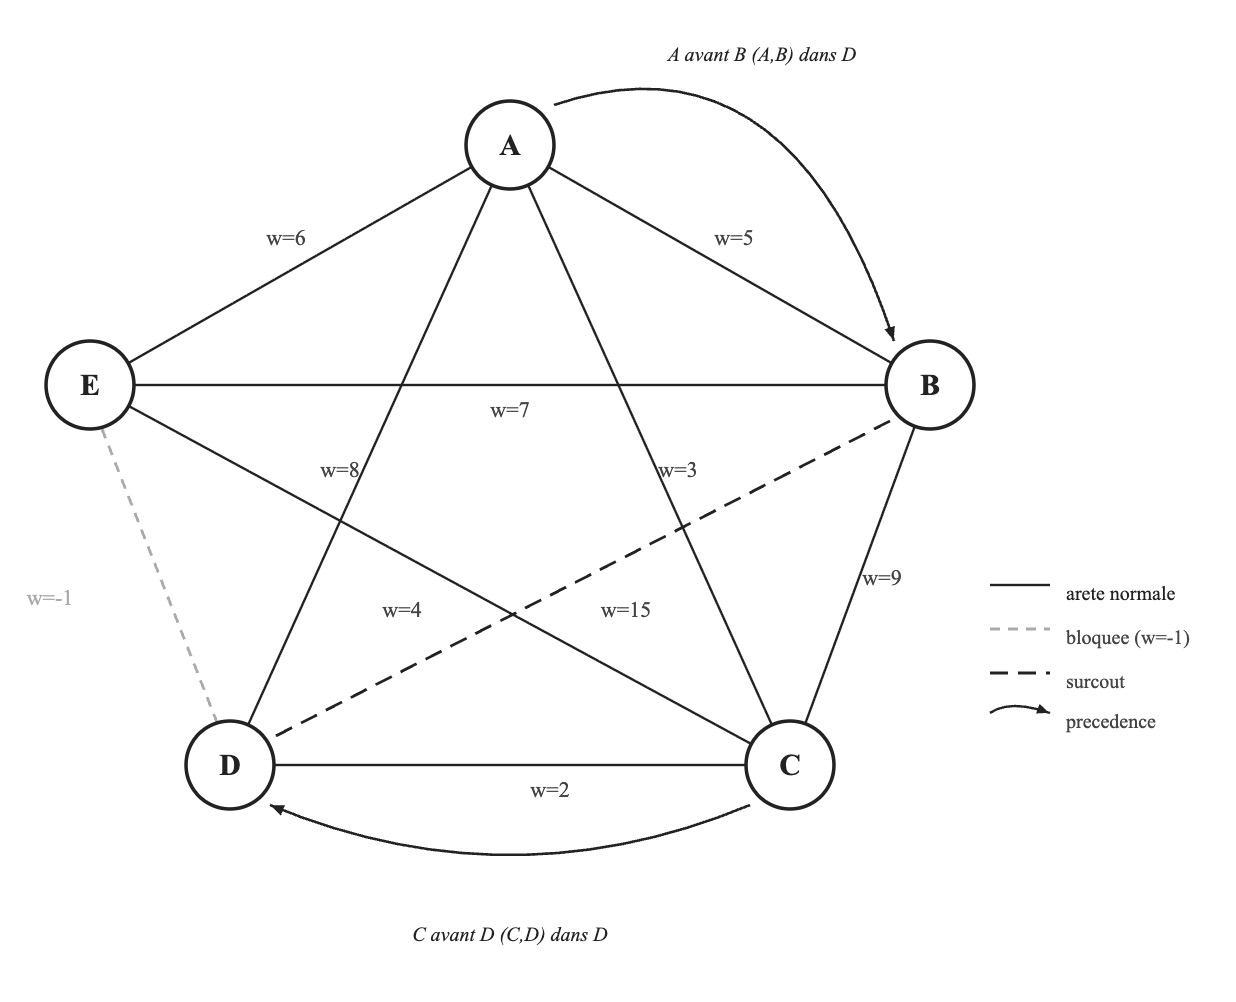

### 4.4. Complexité liée aux contraintes

On pourrait penser que l'ajout de contraintes réduit la difficulté du problème — en interdisant des arêtes ou en imposant un ordre de visite, on élimine des tournées invalides. C'est vrai en pratique, mais insuffisant pour changer la classe de complexité.

Sans aucune contrainte, le nombre de tournées distinctes à explorer pour $n$ sommets est :

$$\frac{(n-1)!}{2}$$

Ce résultat s'explique en deux étapes : on fixe $v_0$ comme point de départ, ce qui ramène le nombre de permutations à $(n-1)!$, puis on divise par $2$ car parcourir un cycle dans un sens ou dans l'autre revient au même sur un graphe non orienté.

Nos contraintes réduisent ce nombre, mais il reste **exponentiel en $n$** — diviser par une constante ne change pas l'ordre de grandeur asymptotique.

| $n$ (sommets) | $(n-1)!/2$ | Ordre de grandeur |
|:---:|---:|:---:|
| 5 | 12 | $10^1$ |
| 10 | 181 440 | $10^5$ |
| 15 | 43 589 145 600 | $10^{10}$ |
| 20 | 60 822 550 204 416 000 | $10^{16}$ |

Il n'existe donc pas d'algorithme polynomial connu permettant de résoudre TSP-PC-ER de manière exacte pour de grandes instances. Cela justifie le recours à des **heuristiques** dans les phases suivantes du projet.

---

## 5.0. Choix et description des algorithmes

Le problème TSP-PC-ER étant NP-Difficile, aucun algorithme exact ne peut le résoudre en temps polynomial pour des instances de grande taille. Le recours à des heuristiques est donc inévitable. Nous avons retenu huit algorithmes issus de quatre familles différentes, afin de couvrir un large spectre du compromis qualité/temps et de rendre la comparaison comparative significative.

**Heuristique constructive**

- **Plus Proche Voisin (PPV)** : algorithme glouton qui construit la tournée en visitant à chaque étape le sommet adjacent le moins coûteux non encore visité. Très rapide ($O(n^2)$), il sert de base et de solution initiale pour d'autres méthodes. La variante multi-start relance l'heuristique depuis chaque sommet et retient la meilleure tournée.

**Recherche locale**

- **Hill Climbing Multi-start (HCMS)** : à chaque restart, une solution initiale aléatoire est améliorée par des échanges de sommets jusqu'à atteindre un optimum local. L'absence de mécanisme d'échappement le rend vulnérable aux optima locaux ; la multi-start compense partiellement ce défaut par diversification des points de départ.

**Métaheuristiques à solution unique**

- **Recuit Simulé (RS)** : inspiré du recuit métallurgique, il accepte des dégradations de la solution courante avec une probabilité décroissante au fil des itérations (contrôlée par $\alpha$). Ce mécanisme d'exploration progressive lui permet d'échapper aux optima locaux tout en convergeant vers de bonnes solutions à grand N grâce à son budget d'itérations fixe.

- **Recuit Simulé Multi-start (RSMS)** : variante qui relance plusieurs fois le recuit depuis des solutions initiales distinctes, en conservant la meilleure solution globale. Le budget total d'itérations est réparti entre les redémarrages.

- **Recherche Tabou (Tabou)** : méthode de recherche locale qui maintient une liste de mouvements récemment effectués (liste tabou) pour éviter de revisiter des solutions déjà explorées. Les échanges de paires de sommets (swap) constituent le voisinage.

- **Recherche Tabou 2-opt** : variante de la recherche tabou utilisant des inversions de segments (mouvements 2-opt) comme opérateur de voisinage. Ces mouvements sont plus structurants que les swaps simples et permettent d'améliorer la qualité des solutions sur les instances de taille intermédiaire.

**Algorithmes à population**

- **Algorithme Génétique** : maintient une population de tournées évoluant par sélection par tournoi, croisement et mutation. La diversité génétique permet une exploration large de l'espace, mais la gestion des contraintes de précédence (faisabilité des individus après croisement) constitue le principal défi.

- **Colonie de Fourmis (ACO)** : inspiré du comportement des fourmis, chaque agent construit une tournée en suivant une heuristique combinant phéromones (mémoire collective des bons chemins) et visibilité (inverse du coût). Les phéromones sont mises à jour après chaque itération, renforçant progressivement les arêtes des meilleures solutions.

---

Le tableau ci-dessous résume les familles et la complexité théorique par itération de chaque algorithme :

| Algorithme | Famille | Complexité / itération | Scalabilité |
|---|---|---|---|
| Plus Proche Voisin | Constructif | $O(n^2)$ (multi-start) | Très bonne |
| Hill Climbing MS | Recherche locale | $O(n^2)$ | Limitée (N ≤ 50) |
| Recuit Simulé | Métaheuristique | $O(n)$ | Très bonne |
| Recuit Simulé MS | Métaheuristique | $O(n)$ | Très bonne |
| Recherche Tabou | Métaheuristique | $O(n^2)$ | Moyenne (N ≤ 100) |
| Recherche Tabou 2-opt | Métaheuristique | $O(n^2)$ | Bonne (N ≤ 1000) |
| Algorithme Génétique | Évolutionnaire | $O(p \cdot n)$ | Limitée (N ≤ 150) |
| Colonie de fourmis | Nature-inspired | $O(n^2)$ | Limitée (N ≤ 50) |

---

## 6.0. Implémentation

### 6.1. Générateur de graphe

La fonction `generate_graph(n)` génère un graphe complet orienté à $n$ sommets modélisant une instance du TSP-PC-ER. Chaque appel avec une graine aléatoire fixée (`np.random.seed`) produit une instance déterministe et reproductible.

**Structure générée.** Le graphe est complet : tous les couples $(u, v)$ avec $u \neq v$ possèdent une arête. Chaque arête reçoit un poids calculé à partir d'une distance euclidienne tirée aléatoirement dans $[1, 100]$, convertie en coût de carburant via `FUEL_PRICE_PER_KM`, avec une probabilité `TOLL_RATIO` d'ajouter un péage aléatoire dans $[\text{TOLL\_MIN}, \text{TOLL\_MAX}]$. Les arêtes interdites ($P(u,v) = -1$) sont tirées avec probabilité `FORBIDDEN_VERTICES_RATIO`. Les contraintes de précédence sont affectées avec probabilité `PRECEDENCE_NODES_RATIO` : un nœud ayant une précédence ne peut être visité qu'après son prédécesseur.

**Pourquoi centraliser la génération.** Tous les plans d'expérience (sections 7.4 et 7.5) partagent exactement les mêmes instances grâce à cette fonction unique. Cela garantit trois propriétés essentielles :

1. **Reproductibilité** : fixer la graine avant chaque appel produit toujours le même graphe, rendant les expériences répétables et les résultats vérifiables.
2. **Comparabilité** : tous les algorithmes sont évalués sur les mêmes instances, éliminant le biais lié à des instances de difficulté variable.
3. **Séparation des responsabilités** : la logique de génération (contraintes, coûts, topologie) est isolée du code des algorithmes. Modifier un paramètre de génération (par exemple `FORBIDDEN_VERTICES_RATIO`) propage automatiquement le changement à l'ensemble des expériences sans toucher au code des heuristiques.

Les paramètres globaux de génération sont définis dans la première cellule du notebook et constituent le seul point de configuration à modifier pour faire varier la difficulté des instances.

In [154]:
def compute_toll_cost(a: int, b: int) -> int:
    """Compute a random toll cost between a and b."""
    return int(np.random.randint(a, b))

def compute_weight(distance: float) -> float:
    """Compute the weight of an edge based on distance, fuel price, and a random chance of having a toll."""
    has_toll: bool = np.random.rand() < TOLL_RATIO
    if has_toll:
        return compute_toll_cost(TOLL_MIN_COST, TOLL_MAX_COST) + (distance * FUEL_PRICE_PER_KM)
    return distance * FUEL_PRICE_PER_KM

def is_forbidden_vertex() -> bool:
    """Randomly determine if an edge is forbidden based on the FORBIDDEN_VERTICES_RATIO."""
    return np.random.rand() < FORBIDDEN_VERTICES_RATIO

def is_precedence_constraint() -> bool:
    """Randomly determine if a node has a precedence constraint."""
    return np.random.rand() < PRECEDENCE_NODES_RATIO

def get_random_node_preference(graph_size: int, precedences: dict[int, int], current_node: int) -> int:
    """Get a random node that is not already a key in the precedences dict, and does not have current_node as a value in the precedences dict (to avoid cycles). Fallback to -1 if no valid node found after 1000 attempts."""
    for _ in range(100):
        node: int = int(np.random.randint(0, graph_size))
        # reject if already a key, or if inverse exists: {node: current_node} would conflict with {current_node: node}
        if node not in precedences and node != current_node:
            return node

    return -1 # fallback if no valid node found after 1000 attempts

def generate_graph(n: int) -> nx.Graph:
    """Generate a complete graph with n nodes, where each edge has a weight based on distance and fuel price, and some edges may be forbidden. Additionally, some nodes may have precedence constraints."""
    graph = nx.complete_graph(n)
    precedences: dict[int, int] = {} # first key is the node, second key is the precedence node
    for node in graph.nodes():
        if is_precedence_constraint():
            precedence_node: int = get_random_node_preference(n, precedences, node)
            if precedence_node != -1:
                precedences[node] = precedence_node
                graph.nodes[node]["precedence"] = precedence_node
            else:
                graph.nodes[node]["precedence"] = None
        else:
            graph.nodes[node]["precedence"] = None

    for u, v in graph.edges():
        is_forbidden: bool = is_forbidden_vertex()
        distance: int = int(np.random.randint(1, 100))
        weight: float = -1 if is_forbidden else compute_weight(distance)

        graph.edges[u, v]["weight"] = weight
    return graph

def display_graph(graph: nx.Graph) -> None:
    """Display the graph using Matplotlib, with different colors for normal edges, forbidden edges, and precedence constraints."""
    precedences_edges: list[tuple[int, int]] = [(u, precedence) for u, precedence in graph.nodes(data='precedence') if precedence is not None]
    normal: list[tuple[int, int]] = []
    forbidden: list[tuple[int, int]] = []

    for u, v in graph.edges():
        forbidden.append((u, v)) if (graph.edges[u, v]["weight"] == -1) else normal.append((u, v))

    edge_labels: dict[tuple[int, int], str] = {
        (u, v): f"{graph.edges[u, v]['weight']:.2f}"
        for (u, v) in normal
    }

    plt.figure(figsize=(10, 10))

    pos = nx.circular_layout(graph)
    nx.draw_networkx_nodes(graph, pos, node_size=500)
    nx.draw_networkx_labels(graph, pos)
    nx.draw_networkx_edges(graph, pos, edgelist=normal, edge_color="b", alpha=0.5)
    nx.draw_networkx_edges(graph, pos, edgelist=forbidden, edge_color="r", alpha=0.5, style="dashed", width=1.5)
    nx.draw_networkx_edges(graph, pos, edgelist=precedences_edges, edge_color="g", alpha=1, connectionstyle="arc3,rad=0.3", arrows=True, arrowstyle='->', width=2)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)

    plt.axis("off")

def display_path(graph: nx.Graph, path: list[int]) -> None:
    """Display the graph and overlay a path through the given node sequence."""
    precedences_edges: list[tuple[int, int]] = [(u, precedence) for u, precedence in graph.nodes(data='precedence') if precedence is not None]
    normal: list[tuple[int, int]] = []
    forbidden: list[tuple[int, int]] = []

    for (u, v) in graph.edges():
        forbidden.append((u, v)) if (graph.edges[u, v]["weight"] == -1) else normal.append((u, v))

    path_edges: list[tuple[int, int]] = [
        (path[i], path[i + 1])
        for i in range(len(path) - 1)
        if graph.has_edge(path[i], path[i + 1]) and graph.edges[path[i], path[i + 1]]["weight"] != -1
    ]

    edge_labels: dict[tuple[int, int], str] = {
        (u, v): f"{graph.edges[u, v]['weight']:.2f}" for (u, v) in normal
    }

    plt.figure(figsize=(10, 10))

    pos = nx.circular_layout(graph)
    nx.draw_networkx_nodes(graph, pos, node_size=500)
    nx.draw_networkx_labels(graph, pos)
    nx.draw_networkx_edges(graph, pos, edgelist=normal, edge_color="b", alpha=0.5)
    nx.draw_networkx_edges(graph, pos, edgelist=forbidden, edge_color="r", alpha=0.5, style="dashed", width=1.5)
    nx.draw_networkx_edges(graph, pos, edgelist=precedences_edges, edge_color="g", alpha=1, connectionstyle="arc3,rad=0.3", arrows=True, arrowstyle="->", width=2)
    nx.draw_networkx_edges(graph, pos, edgelist=path_edges, edge_color="magenta", alpha=1, connectionstyle="arc3,rad=0.2", arrows=True, arrowstyle="->", width=2)
    nx.draw_networkx_edge_labels(graph, pos, edge_labels=edge_labels, font_size=7)

    plt.axis("off")

### 6.2. Fonctions utilitaires

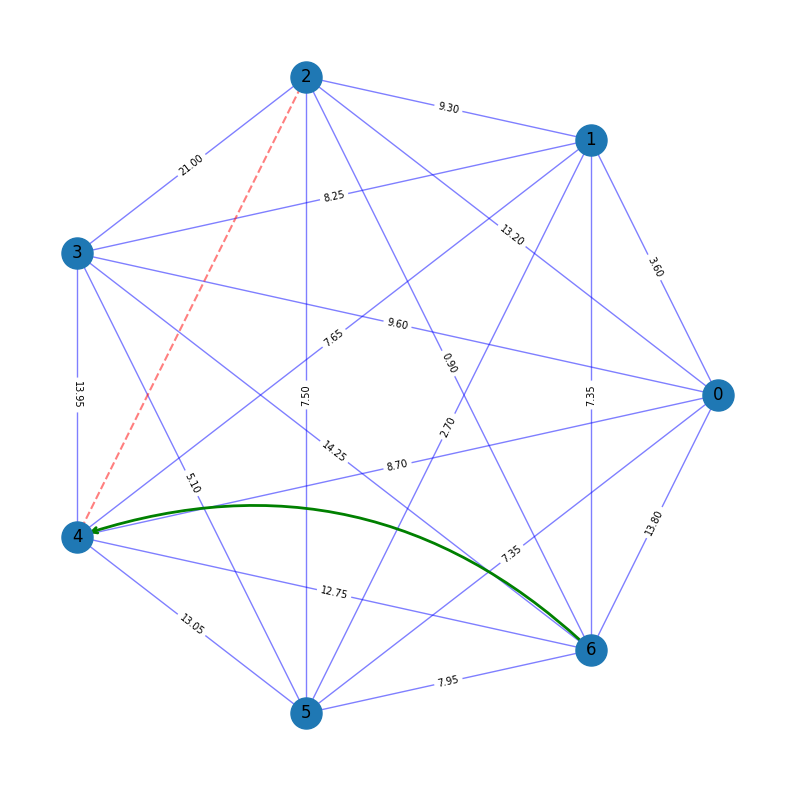

In [155]:
test_graph = generate_graph(7)
display_graph(test_graph)

def print_graph_test(best_tour: list[int], best_cost: float, display_name: str) -> None:
    """Test the validity of a tour and print its cost."""
    if best_tour:
        print(display_name + ": Ordre des sommets dans le meilleur tour :", best_tour)
        print(display_name + ": Coût du meilleur tour :", round(best_cost, 2))
    else:
        print(display_name + ": Aucun tour valide trouvé.")

def node_can_be_visited(graph: nx.Graph, node: int, visited: set[int]) -> bool:
    """Check if a node can be visited based on its precedence constraint."""
    precedence: int | None = graph.nodes[node].get("precedence")
    return precedence is None or precedence in visited


def valid_next_nodes(graph: nx.Graph, current: int, visited: set[int]) -> list[int]:
    """Get a list of valid next nodes that can be visited from the current node, based on the graph's edges, weights, and precedence constraints."""
    return [
        node
        for node in graph.nodes()
        if node not in visited
        and node_can_be_visited(graph, node, visited)
        and graph.edges[current, node]["weight"] != -1
    ]


def calculate_tour_cost_with_penalty(
    graph: nx.Graph,
    tour: list[int],
    penalty_cost: float = PENALTY_COST,
) -> float:
    """Calculate a closed tour cost, penalizing forbidden edges and precedence violations."""
    cost: float = 0.0

    for i in range(len(tour)):
        u: int = tour[i]
        v: int = tour[(i + 1) % len(tour)]
        if graph.has_edge(u, v):
            weight: float = graph.edges[u, v].get("weight", -1)
        else:
            weight = -1

        if weight == -1:
            cost += penalty_cost
        else:
            cost += weight

    for index, node in enumerate(tour):
        precedence: int | None = graph.nodes[node].get("precedence")
        if precedence is not None:
            if precedence not in tour:
                cost += penalty_cost
                continue

            precedence_index: int = tour.index(precedence)
            if precedence_index > index:
                cost += penalty_cost

    return cost


def build_greedy_tour(graph: nx.Graph) -> list[int]:
    """Build an initial tour using a nearest-neighbor heuristic."""
    nodes: list[int] = list(graph.nodes())
    start_candidates: list[int] = [
        n for n in nodes if graph.nodes[n].get("precedence") is None
    ]
    if not start_candidates:
        start_candidates = nodes

    best_tour: list[int] = []
    best_cost: float = float("inf")

    for start in start_candidates:
        tour: list[int] = [start]
        visited: set[int] = {start}

        while len(tour) < len(nodes):
            current: int = tour[-1]
            valid: list[int] = [
                n
                for n in nodes
                if n not in visited
                and node_can_be_visited(graph, n, visited)
                and graph.edges[current, n]["weight"] != -1
            ]
            if not valid:
                break
            nearest: int = min(valid, key=lambda n: graph.edges[current, n]["weight"])
            tour.append(nearest)
            visited.add(nearest)

        if len(tour) != len(nodes):
            continue
        if graph.edges[tour[-1], tour[0]]["weight"] == -1:
            continue

        cost: float = closed_tour_cost(graph, tour)

        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour


def closed_tour_cost(graph: nx.Graph, tour: list[int]) -> float:
    """Compute the total cost of a closed tour (last node to first node included)."""
    cost: float = sum(graph.edges[u, v]["weight"] for u, v in zip(tour, tour[1:]))
    cost += graph.edges[tour[-1], tour[0]]["weight"]
    return cost


def is_tour_feasible(graph: nx.Graph, tour: list[int]) -> bool:
    """Check that every edge in a closed tour exists and respects precedences."""
    visited: set[int] = set()
    for idx, node in enumerate(tour):
        if not node_can_be_visited(graph, node, visited):
            return False
        visited.add(node)

        next_node: int = tour[(idx + 1) % len(tour)]
        if not graph.has_edge(node, next_node):
            return False
        if graph.edges[node, next_node]["weight"] == -1:
            return False

    return True

### 6.3. Algorithmes et exemples

#### 6.3.1. Colonie de fourmis

In [156]:
def resolve_by_ant_system(
    graph: nx.Graph,
    n_iterations: int = 200,
    n_ants: int | None = None,
    alpha: float = 1.0,
    beta: float = 5.0,
    evaporation_rate: float = 0.5,
    initial_pheromone: float = 1.0,
) -> tuple[list[int], float]:
    """Resolve the graph using a simple ant colony optimization algorithm."""
    node_count: int = graph.number_of_nodes()
    if node_count == 0:
        return [], 0.0

    if n_ants is None:
        n_ants = node_count

    start_candidates: list[int] = [node for node in graph.nodes() if graph.nodes[node].get("precedence") is None]
    if not start_candidates:
        start_candidates = list(graph.nodes())

    pheromones: np.ndarray = np.full((node_count, node_count), initial_pheromone, dtype=float)
    best_tour: list[int] = []
    best_cost: float = float("inf")

    for _ in range(n_iterations):
        iteration_solutions: list[tuple[list[int], float]] = []

        for _ in range(n_ants):
            start: int = int(np.random.choice(start_candidates))
            tour: list[int] = [start]
            visited: set[int] = {start}

            while len(tour) < node_count:
                current: int = tour[-1]
                neighbors: list[int] = valid_next_nodes(graph, current, visited)
                if not neighbors:
                    break

                scores: list[float] = []
                for neighbor in neighbors:
                    weight: float = graph.edges[current, neighbor]["weight"]
                    score: float = (pheromones[current, neighbor] ** alpha) * ((1.0 / weight) ** beta)
                    scores.append(score)

                scores_array: np.ndarray = np.array(scores, dtype=float)
                if scores_array.sum() <= 0:
                    next_node: int = int(np.random.choice(neighbors))
                else:
                    probabilities: np.ndarray = scores_array / scores_array.sum()
                    next_node: int = int(np.random.choice(neighbors, p=probabilities))

                tour.append(next_node)
                visited.add(next_node)

            if len(tour) != node_count:
                continue

            total_cost: float = 0.0
            feasible: bool = True
            for u, v in zip(tour, tour[1:]):
                weight: float = graph.edges[u, v]["weight"]
                if weight == -1:
                    feasible = False
                    break
                total_cost += weight

            if not feasible:
                continue

            return_weight: float = graph.edges[tour[-1], tour[0]]["weight"]
            if return_weight == -1:
                continue

            total_cost += return_weight
            closed_tour: list[int] = tour + [tour[0]]

            if total_cost < best_cost:
                best_cost = total_cost
                best_tour = closed_tour

            iteration_solutions.append((tour, total_cost))

        pheromones *= (1.0 - evaporation_rate)
        for tour, cost in iteration_solutions:
            deposit: float = 1.0 / cost
            for u, v in zip(tour, tour[1:]):
                pheromones[u, v] += deposit
                pheromones[v, u] += deposit
            pheromones[tour[-1], tour[0]] += deposit
            pheromones[tour[0], tour[-1]] += deposit

    if not best_tour:
        return [], float("inf")

    return best_tour, best_cost

##### 6.3.1.1. Cas de test

In [157]:
best_tour, best_cost = resolve_by_ant_system(test_graph, n_iterations=100, n_ants=10)
print_graph_test(best_tour, best_cost, "Colonie de Fourmis")

Colonie de Fourmis: Ordre des sommets dans le meilleur tour : [1, 0, 4, 6, 2, 5, 3, 1]
Colonie de Fourmis: Coût du meilleur tour : 46.8


#### 6.3.2. Génétique

In [158]:
def _generate_random_individual(nodes: list[int]) -> list[int]:
    """Generate a random valid individual for the population."""
    individual: list[int] = nodes.copy()
    random.shuffle(individual)
    return individual


def _ordered_crossover(parent1: list[int], parent2: list[int]) -> list[int]:
    """Perform ordered crossover (OX) between two parents."""
    size: int = len(parent1)
    start: int
    end: int
    start, end = sorted(random.sample(range(size), 2))
    child: list[int] = [-1] * size
    child[start : end + 1] = parent1[start : end + 1]

    pointer: int = end + 1
    for gene in parent2[end + 1 :] + parent2[: end + 1]:
        if gene not in child:
            if pointer >= size:
                pointer = 0
            child[pointer] = gene
            pointer += 1

    return child


def _swap_mutation(individual: list[int], mutation_rate: float) -> list[int]:
    """Perform swap mutation on an individual."""
    if random.random() < mutation_rate:
        i: int
        j: int
        i, j = random.sample(range(len(individual)), 2)
        individual[i], individual[j] = individual[j], individual[i]
    return individual


def _tournament_selection(
    population: list[list[int]], costs: list[float], tournament_size: int
) -> list[int]:
    """Select an individual using tournament selection."""
    participants: list[tuple[list[int], float]] = random.sample(list(zip(population, costs)), tournament_size)
    participants.sort(key=lambda item: item[1])
    return participants[0][0].copy()


def resolve_by_genetic(
    graph: nx.Graph,
    population_size: int = 50,
    generations: int = 200,
    crossover_rate: float = 0.8,
    mutation_rate: float = 0.2,
    tournament_size: int = 3,
    elite_size: int = 2,
) -> tuple[list[int], float]:
    """Resolve the graph using a simple genetic algorithm."""
    nodes: list[int] = list(graph.nodes())
    node_count: int = len(nodes)

    if node_count == 0:
        return [], 0.0

    population: list[list[int]] = [_generate_random_individual(nodes) for _ in range(population_size)]
    best_tour: list[int] = []
    best_cost: float = float("inf")

    for _ in range(generations):
        costs: list[float] = [
            calculate_tour_cost_with_penalty(graph, individual)
            for individual in population
        ]

        for individual, cost in zip(population, costs):
            if cost < best_cost:
                best_cost = cost
                best_tour = individual.copy()

        new_population: list[list[int]] = []
        sorted_population: list[list[int]] = [
            individual
            for _, individual in sorted(
                zip(costs, population), key=lambda item: item[0]
            )
        ]
        new_population.extend(sorted_population[:elite_size])

        while len(new_population) < population_size:
            parent1: list[int] = _tournament_selection(population, costs, tournament_size)
            parent2: list[int] = _tournament_selection(population, costs, tournament_size)

            if random.random() < crossover_rate:
                child: list[int] = _ordered_crossover(parent1, parent2)
            else:
                child = parent1.copy()

            child = _swap_mutation(child, mutation_rate)
            new_population.append(child)

        population = new_population

    if not best_tour:
        return [], float("inf")

    return best_tour + [best_tour[0]], best_cost

##### 6.3.2.1. Cas de test

In [159]:
best_tour, best_cost = resolve_by_genetic(test_graph, generations=100, population_size=50)
print_graph_test(best_tour, best_cost, "Algorithme Génétique")

Algorithme Génétique: Ordre des sommets dans le meilleur tour : [1, 0, 4, 6, 2, 5, 3, 1]
Algorithme Génétique: Coût du meilleur tour : 46.8


#### 6.3.3. Hill Climbing Multi Start

In [160]:
def _generate_random_tour(nodes: list) -> list:
    """Generates an initial random solution (permutation of nodes)."""
    tour: list = list(nodes)
    depot: int = tour[0]
    rest_of_tour: list = tour[1:]
    random.shuffle(rest_of_tour)
    return [depot] + rest_of_tour


def _get_neighbors(tour: list) -> list:
    """Generates the neighborhood using a simple 2-node swap."""
    neighbors: list = []
    for i in range(1, len(tour) - 1):
        for j in range(i + 1, len(tour)):
            neighbor: list = tour.copy()
            neighbor[i], neighbor[j] = neighbor[j], neighbor[i]
            neighbors.append(neighbor)
    return neighbors


def resolve_by_hill_climbing(graph: nx.Graph, initial_tour: list) -> tuple:
    """Executes a single hill climbing pass."""
    current_tour: list = initial_tour
    current_cost: float = calculate_tour_cost_with_penalty(graph, current_tour)

    while True:
        neighbors: list = _get_neighbors(current_tour)
        best_neighbor: list | None = None
        best_neighbor_cost: float = current_cost

        for neighbor in neighbors:
            cost: float = calculate_tour_cost_with_penalty(graph, neighbor)
            if cost < best_neighbor_cost:
                best_neighbor = neighbor
                best_neighbor_cost = cost

        if best_neighbor is not None:
            current_tour = best_neighbor
            current_cost = best_neighbor_cost
        else:
            break

    return current_tour, current_cost


def resolve_by_ms_hill_climbing(graph: nx.Graph, iterations: int = 50) -> tuple:
    """Runs the Hill Climbing algorithm multiple times from different starting points."""
    nodes: list = list(graph.nodes())
    global_best_tour: list | None = None
    global_best_cost: float = float("inf")

    for _ in range(iterations):
        initial_tour: list = _generate_random_tour(nodes)

        final_tour: list
        final_cost: float
        final_tour, final_cost = resolve_by_hill_climbing(graph, initial_tour)

        if final_cost < global_best_cost:
            global_best_cost = final_cost
            global_best_tour = final_tour

    if global_best_tour is None or global_best_cost >= PENALTY_COST:
        print("No valid tour is possible with the current constraints.")
        return [], float("inf")

    return global_best_tour, global_best_cost

##### 6.3.3.1. Cas de test

In [161]:
best_tour, best_cost = resolve_by_ms_hill_climbing(test_graph, iterations=100)
print_graph_test(best_tour, best_cost, "Hill Climbing Multi-start")

Hill Climbing Multi-start: Ordre des sommets dans le meilleur tour : [0, 4, 6, 2, 5, 3, 1]
Hill Climbing Multi-start: Coût du meilleur tour : 46.8


#### 6.3.4. Plus Proche Voisin

In [162]:
def _nearest_neighbor_tour(graph: nx.Graph, start: int) -> tuple[list[int], float]:
    """
    Build a tour using the nearest neighbour heuristic from a given start node.
    At each step the closest unvisited reachable node (lowest edge weight) is chosen.
    If no valid neighbour exists the algorithm falls back to any unvisited node,
    accumulating a penalty so the result remains comparable with other solvers.
    Returns the closed tour and its total cost.
    """
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            # Pick the nearest cheapest valid neighbour
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
        else:
            # Fallback: any unvisited node that satisfies precedence (ignoring forbidden edges)
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                # Last resort: any unvisited node
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]

        tour.append(next_node)
        visited.add(next_node)

    cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return tour + [tour[0]], cost


def resolve_by_nearest_neighbor(
    graph: nx.Graph,
    multi_start: bool = True,
) -> tuple[list[int], float]:
    """
    Resolve the TSP using the nearest neighbour heuristic.

    When *multi_start* is True (default) the algorithm is run once from every
    node and the best closed tour is returned, which greatly reduces sensitivity
    to the arbitrary choice of starting point.
    When *multi_start* is False a single run is performed from a random node
    that has no precedence constraint.
    """
    node_count: int = graph.number_of_nodes()
    if node_count == 0:
        return [], 0.0

    if multi_start:
        starts: list[int] = list(graph.nodes())
    else:
        free_starts: list[int] = [
            n for n in graph.nodes() if graph.nodes[n].get("precedence") is None
        ]
        starts: list[int] = [
            int(np.random.choice(free_starts if free_starts else list(graph.nodes())))
        ]

    best_tour: list[int] = []
    best_cost: float = float("inf")

    for start in starts:
        tour: list[int]
        cost: float
        tour, cost = _nearest_neighbor_tour(graph, start)
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour, best_cost


##### 6.3.4.1. Cas de test

In [163]:
best_tour, best_cost = resolve_by_nearest_neighbor(test_graph, multi_start=True)
print_graph_test(best_tour, best_cost, "Plus Proche Voisin Multi-start")

Plus Proche Voisin Multi-start: Ordre des sommets dans le meilleur tour : [1, 5, 3, 0, 4, 6, 2, 1]
Plus Proche Voisin Multi-start: Coût du meilleur tour : 49.05


#### 6.3.5. Recuit simulé

In [164]:
def _tour_cost(graph: nx.Graph, tour: list[int]) -> float:
    total: float = 0.0
    for u, v in zip(tour, tour[1:]):
        weight: float = graph.edges[u, v]["weight"]
        if weight == -1:
            return float("inf")
        total += weight
    return total


def _is_feasible(graph: nx.Graph, tour: list[int]) -> bool:
    if len(tour) < 2 or tour[0] != tour[-1]:
        return False

    open_tour: list[int] = tour[:-1]
    if len(set(open_tour)) != len(open_tour):
        return False

    return is_tour_feasible(graph, open_tour)


def _two_opt_swap(tour: list[int], i: int, j: int) -> list[int]:
    return tour[:i] + tour[i:j + 1][::-1] + tour[j + 1:]


def _initial_tour(graph: nx.Graph, rng: np.random.Generator) -> list[int]:
    n: int = graph.number_of_nodes()
    visited: set[int] = {0}
    tour: list[int] = [0]

    # Greedy nearest neighbor from node 0
    while len(tour) < n:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)
        if not candidates:
            break
        next_node = min(candidates, key=lambda v: graph.edges[current, v]["weight"])
        tour.append(next_node)
        visited.add(next_node)

    tour.append(0)

    if _is_feasible(graph, tour):
        return tour

    # Fallback: random shuffles
    for _ in range(50):
        order: list[int] = list(range(1, n))
        rng.shuffle(order)
        candidate: list[int] = [0] + order + [0]
        if _is_feasible(graph, candidate):
            return candidate

    return [0] + list(range(1, n)) + [0]


def _initial_temperature(graph: nx.Graph, tour: list[int], rng: np.random.Generator) -> float:
    # Calibrate T0 so that ~80% of degradations are accepted initially
    n: int = len(tour)
    base_cost: float = _tour_cost(graph, tour)
    degradations: list[float] = []

    for _ in range(n * 20):
        i: int = int(rng.integers(1, n - 2))
        j: int = int(rng.integers(i + 1, n - 1))
        neighbor: list[int] = _two_opt_swap(tour, i, j)
        if not _is_feasible(graph, neighbor):
            continue
        delta: float = _tour_cost(graph, neighbor) - base_cost
        if delta > 0:
            degradations.append(delta)
        if len(degradations) >= 100:
            break

    if not degradations:
        return 1.0
    return -float(np.mean(degradations)) / math.log(0.8)


def resolve_by_recuit_simule(
    graph: nx.Graph,
    max_iterations: int = 10000,
    max_time_seconds: float | None = None,
    seed: int | None = None,
    alpha: float = 0.995,
) -> tuple[list[int], float]:
    rng: np.random.Generator = np.random.default_rng(seed)
    start: float = time.perf_counter()

    current: list[int] = _initial_tour(graph, rng)
    current_cost: float = _tour_cost(graph, current)
    best: list[int] = list(current)
    best_cost: float = current_cost

    t: float = _initial_temperature(graph, current, rng)
    n: int = len(current)
    iteration: int = 0

    while True:
        if max_time_seconds is not None and (time.perf_counter() - start) >= max_time_seconds:
            break
        if iteration >= max_iterations:
            break

        # Find a feasible 2-opt neighbor
        neighbor: list[int] | None = None
        for _ in range(100):
            i: int = int(rng.integers(1, n - 2))
            j: int = int(rng.integers(i + 1, n - 1))
            candidate: list[int] = _two_opt_swap(current, i, j)
            if _is_feasible(graph, candidate):
                neighbor = candidate
                break

        if neighbor is None:
            break

        delta: float = _tour_cost(graph, neighbor) - current_cost

        # Metropolis criterion
        if delta <= 0 or rng.random() < math.exp(-delta / t):
            current = neighbor
            current_cost += delta
            if current_cost < best_cost:
                best = list(current)
                best_cost = current_cost

        # Geometric cooling
        t *= alpha
        iteration += 1

    return best, best_cost


def resolve_by_ms_recuit_simule(
    graph: nx.Graph,
    n_restarts: int = 5,
    max_iterations_per_restart: int = 2000,
    max_time_seconds: float | None = None,
    seed: int | None = None,
    alpha: float = 0.995,
) -> tuple[list[int], float]:
    rng: np.random.Generator = np.random.default_rng(seed)
    start: float = time.perf_counter()
    best: list[int] = []
    best_cost: float = float("inf")

    for _ in range(n_restarts):
        # Check global time budget
        if max_time_seconds is not None:
            elapsed: float = time.perf_counter() - start
            if elapsed >= max_time_seconds:
                break
            remaining: float | None = max_time_seconds - elapsed
        else:
            remaining = None

        tour: list[int]
        cost: float
        tour, cost = resolve_by_recuit_simule(
            graph,
            max_iterations=max_iterations_per_restart,
            max_time_seconds=remaining,
            seed=int(rng.integers(0, 2**31)),
            alpha=alpha,
        )

        if cost < best_cost:
            best = tour
            best_cost = cost

    return best, best_cost

##### 6.3.5.1. Cas de test

In [165]:
best_tour, best_cost = resolve_by_recuit_simule(test_graph, max_iterations=5000, seed=42)
print_graph_test(best_tour, best_cost, "Recuit Simulé")

best_tour, best_cost = resolve_by_ms_recuit_simule(test_graph, n_restarts=5, max_iterations_per_restart=2000, seed=42)
print_graph_test(best_tour, best_cost, "Recuit Simulé Multi-start")

Recuit Simulé: Ordre des sommets dans le meilleur tour : [0, 4, 6, 2, 5, 3, 1, 0]
Recuit Simulé: Coût du meilleur tour : 46.8
Recuit Simulé Multi-start: Ordre des sommets dans le meilleur tour : [0, 4, 1, 6, 2, 5, 3, 0]
Recuit Simulé Multi-start: Coût du meilleur tour : 46.8


#### 6.3.6. Recherche Tabou

In [166]:
def _apply_swap(tour: list[int], i: int, j: int) -> list[int]:
    """Return a new tour with positions i and j swapped."""
    new_tour: list[int] = tour[:]
    new_tour[i], new_tour[j] = new_tour[j], new_tour[i]
    return new_tour


def resolve_by_tabu_search(
    graph: nx.Graph, n_iterations: int = 500, tabu_tenure: int | None = None
) -> tuple[list[int], float]:
    """Resolve the TSP using a simple Tabu Search with node-swap neighborhood."""
    node_count: int = graph.number_of_nodes()
    if node_count < 2:
        nodes: list[int] = list(graph.nodes())
        return nodes + nodes[:1], 0.0

    # check params
    if tabu_tenure is None:
        tabu_tenure = max(7, node_count // 5)

    current_tour: list[int] = build_greedy_tour(graph)
    if not current_tour:
        return [], float("inf")

    current_cost: float = closed_tour_cost(graph, current_tour)
    best_tour: list[int] = current_tour[:]
    best_cost: float = current_cost

    # tabu_list[frozenset({city_a, city_b})] = iteration until which the swap is forbidden
    tabu_list: dict[frozenset, int] = {}

    for iteration in range(n_iterations):
        best_candidate: list[int] | None = None
        best_candidate_cost: float = float("inf")
        best_move: frozenset | None = None

        n: int = len(current_tour)

        # Explore all possible swaps (i, j) with i < j
        for i in range(n):
            for j in range(i + 1, n):
                candidate: list[int] = _apply_swap(current_tour, i, j)

                if not is_tour_feasible(graph, candidate):
                    continue

                cost: float = closed_tour_cost(graph, candidate)
                move_key: frozenset = frozenset({current_tour[i], current_tour[j]})

                is_tabu: bool = tabu_list.get(move_key, 0) > iteration

                # Accept if not tabu, OR aspiration criterion (beats global best)
                if (not is_tabu or cost < best_cost) and cost < best_candidate_cost:
                    best_candidate = candidate
                    best_candidate_cost = cost
                    best_move = move_key

        if best_candidate is None:
            continue

        current_tour = best_candidate
        current_cost = best_candidate_cost

        if best_move is not None:
            tabu_list[best_move] = iteration + tabu_tenure

        if current_cost < best_cost:
            best_cost = current_cost
            best_tour = current_tour[:]

    if not best_tour:
        return [], float("inf")

    # Return a closed tour
    return best_tour + [best_tour[0]], best_cost

In [167]:
def _apply_2opt_swap(tour: list[int], i: int, j: int) -> list[int]:
    """Return a new tour after reversing the segment between indices i+1 and j (2-opt)."""
    return tour[: i + 1] + tour[i + 1 : j + 1][::-1] + tour[j + 1 :]


def resolve_by_tabu_search_with_2opt(
    graph: nx.Graph,
    n_iterations: int = 500,
    tabu_tenure: int | None = None,
    neighborhood_size: int | None = None,
) -> tuple[list[int], float]:
    """Resolve the TSP using a Tabu Search with 2-opt neighborhood"""
    node_count: int = graph.number_of_nodes()
    if node_count < 2:
        nodes: list[int] = list(graph.nodes())
        return nodes + nodes[:1], 0.0

    # check params
    if tabu_tenure is None:  # number of iterations during which a move remains tabu
        tabu_tenure = max(7, node_count // 5)
    if neighborhood_size is None:
        neighborhood_size = min(node_count * (node_count - 1) // 2, 200)

    current_tour: list[int] = build_greedy_tour(graph)
    if not current_tour:
        return [], float("inf")

    current_cost: float = closed_tour_cost(graph, current_tour)
    best_tour: list[int] = current_tour[:]
    best_cost: float = current_cost

    # each entry is a frozenset({i, j}) representing the swapped edge pair.
    tabu_list: dict[frozenset, int] = {}

    for iteration in range(n_iterations):
        # generate neighborhood: all 2-opt swaps (i, j) with i < j
        n: int = len(current_tour)
        all_moves: list[tuple[int, int]] = [(i, j) for i in range(n - 1) for j in range(i + 2, n)]

        # randomly sample if neighborhood is too large
        if len(all_moves) > neighborhood_size:
            all_moves = [
                all_moves[k]
                for k in np.random.choice(
                    len(all_moves), neighborhood_size, replace=False
                )
            ]

        best_candidate: list[int] | None = None
        best_candidate_cost: float = float("inf")
        best_move: tuple[int, int] | None = None

        for i, j in all_moves:
            candidate: list[int] = _apply_2opt_swap(current_tour, i, j)

            if not is_tour_feasible(graph, candidate):
                continue

            cost: float = closed_tour_cost(graph, candidate)
            move_key: frozenset = frozenset(
                {
                    frozenset({current_tour[i], current_tour[i + 1]}),
                    frozenset({current_tour[j], current_tour[(j + 1) % n]}),
                }
            )

            is_tabu: bool = tabu_list.get(move_key, 0) > iteration

            # accept move if: not tabu, OR aspiration criterion (beats global best)
            if (not is_tabu or cost < best_cost) and cost < best_candidate_cost:
                best_candidate = candidate
                best_candidate_cost = cost
                best_move = (i, j)

        if best_candidate is None:
            # all neighbors are tabu and none satisfies aspiration → skip
            continue

        # move to best candidate
        current_tour = best_candidate
        current_cost = best_candidate_cost

        # register the move as tabu
        if best_move is not None:
            i, j = best_move
            n = len(current_tour)
            move_key: frozenset = frozenset(
                {
                    frozenset({current_tour[i], current_tour[i + 1]}),
                    frozenset({current_tour[j], current_tour[(j + 1) % n]}),
                }
            )
            tabu_list[move_key] = iteration + tabu_tenure

        if current_cost < best_cost:
            best_cost = current_cost
            best_tour = current_tour[:]

    if not best_tour:
        return [], float("inf")

    # return a closed tour
    return best_tour + [best_tour[0]], best_cost

##### 6.3.6.1. Cas de test

In [168]:
best_tour, best_cost = resolve_by_tabu_search(test_graph, n_iterations=500, tabu_tenure=10)
print_graph_test(best_tour, best_cost, "Tabu Search avec swap")

best_tour, best_cost = resolve_by_tabu_search_with_2opt(test_graph, n_iterations=500, tabu_tenure=10, neighborhood_size=100)
print_graph_test(best_tour, best_cost, "Tabu Search avec 2-opt")

Tabu Search avec swap: Ordre des sommets dans le meilleur tour : [5, 3, 1, 0, 4, 6, 2, 5]
Tabu Search avec swap: Coût du meilleur tour : 46.8
Tabu Search avec 2-opt: Ordre des sommets dans le meilleur tour : [1, 4, 0, 3, 5, 2, 6, 1]
Tabu Search avec 2-opt: Coût du meilleur tour : 46.8


## 7.0. Exploitation

Dans cette partie, l'objectif est de réaliser un plan d'expérience permettant de tirer parti des meilleurs paramètres et d'en conclure sur les algorithmes les plus adaptées.
Pour cela, nous réalisons deux expériences. L'objectif de la première est de trouver les paramètres optimaux pour chaque algorithme, la seconde étant l'analyse et la comparaison des différents algorithmes sur des grandes instances de $N$.

La première expérience de chaque algorithme suivra ce plan : 
- Définition des paramètres globaux
- Étude de trajectoire
- Étude de l'influence des paramètres
- Définition des paramètres optimisés

### 7.1. Définition des paramètres globaux

L'objectif est d'itérer sur les mêmes graphes. Nous utilisons donc des `seed` pour chaque instance de graphe $N$.
Nous allons ensuite calculer la borne de chaque graphe. Cela nous permettra de calculer le `gap` pour comparer équitablement les algorithmes entre eux.

Chaque algorithme nous permet d'obtenir: 
- le meilleur coût des itérations
- la moyenne des coûts
- la médiane des coûts
- l'écart-type
- le minimum et le maximum
- des représentations graphiques:
    - Trajectoire (accumulation du coût au fil des nœuds visités)
    - Influence de chaque paramètre
    - Distance à la borne (`gap`)
- Meilleurs paramètres

In [169]:
N_VALUES: list[int] = [10, 12, 15, 17, 20, 22, 25, 30]
NB_SEEDS: int = 5
NB_GENERATIONS: int = 20


def get_standard_instances(n: int, nb_seeds: int = NB_SEEDS) -> list[tuple[int, nx.Graph]]:
    """Génère `nb_seeds` graphes reproductibles de taille `n`, un par seed."""
    instances: list[tuple[int, nx.Graph]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        instances.append((seed, graph))
    return instances

### 7.2. Borne de référence et gap

Borne inférieure « min-sortants » pour toutes les tailles : $\frac{1}{2} \sum_v \min_{u \neq v} w(v,u)$, arêtes interdites ($w = -1$) exclues.

$$\text{gap} = 100 \times \frac{\text{cost} - \text{reference}}{\text{reference}}$$

In [170]:
def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    """Borne inférieure : demi-somme des arêtes sortantes minimales (arêtes interdites exclues)."""
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    """Borne inférieure de référence pour le calcul du gap."""
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, reference: float) -> float:
    """Gap en %, NaN si `reference <= 0`."""
    if reference <= 0:
        return float("nan")
    return 100.0 * (cost - reference) / reference

### 7.3. Pré-calcul des instances et bornes

On matérialise `instances[n]` = liste de `(seed, graph, reference)` pour réutiliser les mêmes graphes + bornes dans toutes les études suivantes.

In [171]:
instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in N_VALUES:
    raw: list[tuple[int, nx.Graph]] = get_standard_instances(n)
    enriched: list[tuple[int, nx.Graph, float]] = []
    for seed, graph in raw:
        ref: float = reference_value(graph)
        enriched.append((seed, graph, ref))
    instances[n] = enriched
    refs: list[float] = [r for _, _, r in enriched]
    print(f"N={n:3d} | {len(enriched)} instances | ref min={min(refs):.2f} max={max(refs):.2f}")

N= 10 | 5 instances | ref min=8.85 max=12.97
N= 12 | 5 instances | ref min=8.10 max=16.80
N= 15 | 5 instances | ref min=7.65 max=12.22
N= 17 | 5 instances | ref min=7.05 max=10.80
N= 20 | 5 instances | ref min=8.02 max=12.97
N= 22 | 5 instances | ref min=6.83 max=13.35
N= 25 | 5 instances | ref min=9.22 max=13.50
N= 30 | 5 instances | ref min=9.00 max=11.92


### 7.4. Algorithmes

#### 7.4.1. Plus Proche Voisin
Pour cette algorithme, l'hypothèse principale est que l'activation du multi-start va nous permettre de trouver des meilleurs optimums locaux et de tendre vers un optimum global.

In [172]:
def _nearest_neighbor_tour(graph: nx.Graph, start: int) -> tuple[list[int], float]:
    """Construit une tournée depuis `start` en choisissant à chaque étape le voisin valide le moins coûteux."""
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
        else:
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]

        tour.append(next_node)
        visited.add(next_node)

    cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return tour + [tour[0]], cost


def resolve_by_nearest_neighbor(
    graph: nx.Graph,
    multi_start: bool = True,
) -> tuple[list[int], float]:
    """Résout le TSP par l'heuristique du plus proche voisin.

    Si `multi_start=True` : lancé depuis chaque sommet, retourne la meilleure tournée.
    Si `multi_start=False` : lancé depuis un seul sommet aléatoire sans contrainte de précédence.
    """
    node_count: int = graph.number_of_nodes()
    if node_count == 0:
        return [], 0.0

    if multi_start:
        starts: list[int] = list(graph.nodes())
    else:
        free_starts: list[int] = [
            n for n in graph.nodes() if graph.nodes[n].get("precedence") is None
        ]
        starts: list[int] = [
            int(np.random.choice(free_starts if free_starts else list(graph.nodes())))
        ]

    best_tour: list[int] = []
    best_cost: float = float("inf")

    for start in starts:
        tour, cost = _nearest_neighbor_tour(graph, start)
        if cost < best_cost:
            best_cost = cost
            best_tour = tour

    return best_tour, best_cost


def _nearest_neighbor_tour_tracked(
    graph: nx.Graph, start: int
) -> tuple[list[int], float, list[float]]:
    """Variante instrumentée : retourne aussi le coût cumulé après chaque ajout de nœud."""
    node_count: int = graph.number_of_nodes()
    tour: list[int] = [start]
    visited: set[int] = {start}
    cumulative_cost: float = 0.0
    cost_history: list[float] = [0.0]  # coût après 1er nœud = 0

    while len(tour) < node_count:
        current: int = tour[-1]
        candidates: list[int] = valid_next_nodes(graph, current, visited)

        if candidates:
            next_node = min(candidates, key=lambda n: graph.edges[current, n]["weight"])
            edge_cost: float = graph.edges[current, next_node]["weight"]
        else:
            fallback: list[int] = [
                n
                for n in graph.nodes()
                if n not in visited and node_can_be_visited(graph, n, visited)
            ]
            if not fallback:
                fallback = [n for n in graph.nodes() if n not in visited]
            if not fallback:
                break
            next_node = fallback[0]
            edge_cost = PENALTY_COST  # arête de fallback : pénalité

        cumulative_cost += edge_cost
        tour.append(next_node)
        visited.add(next_node)
        cost_history.append(cumulative_cost)

    # Arête de retour au dépôt
    if len(tour) > 1:
        last: int = tour[-1]
        first: int = tour[0]
        if graph.has_edge(last, first) and graph.edges[last, first]["weight"] != -1:
            cumulative_cost += graph.edges[last, first]["weight"]
        else:
            cumulative_cost += PENALTY_COST
        cost_history.append(cumulative_cost)

    final_tour = tour + [tour[0]]
    final_cost: float = calculate_tour_cost_with_penalty(graph, tour)
    return final_tour, final_cost, cost_history

##### 7.4.1.1. Calcul de trajectoire

On observe l'accumulation du coût au fil des nœuds ajoutés à la tournée, pour une instance représentative par taille de graphe.

Contrairement à HC-MS qui itère par restarts, le Plus Proche Voisin construit sa tournée en une seule passe glouctonne. La trajectoire prend donc la forme d'une courbe croissante : le coût cumulé augmente à chaque étape, avec des sauts brusques lorsque l'algorithme doit recourir à un nœud de fallback (contrainte de précédence non satisfaite ou arête interdite).

On affiche :
- La trajectoire en `multi_start=True` (meilleur point de départ) en **bleu**
- La **ligne rouge** en pointillés représente la borne inférieure de référence
- Le **coût final** de la tournée est indiqué sur l'axe des ordonnées

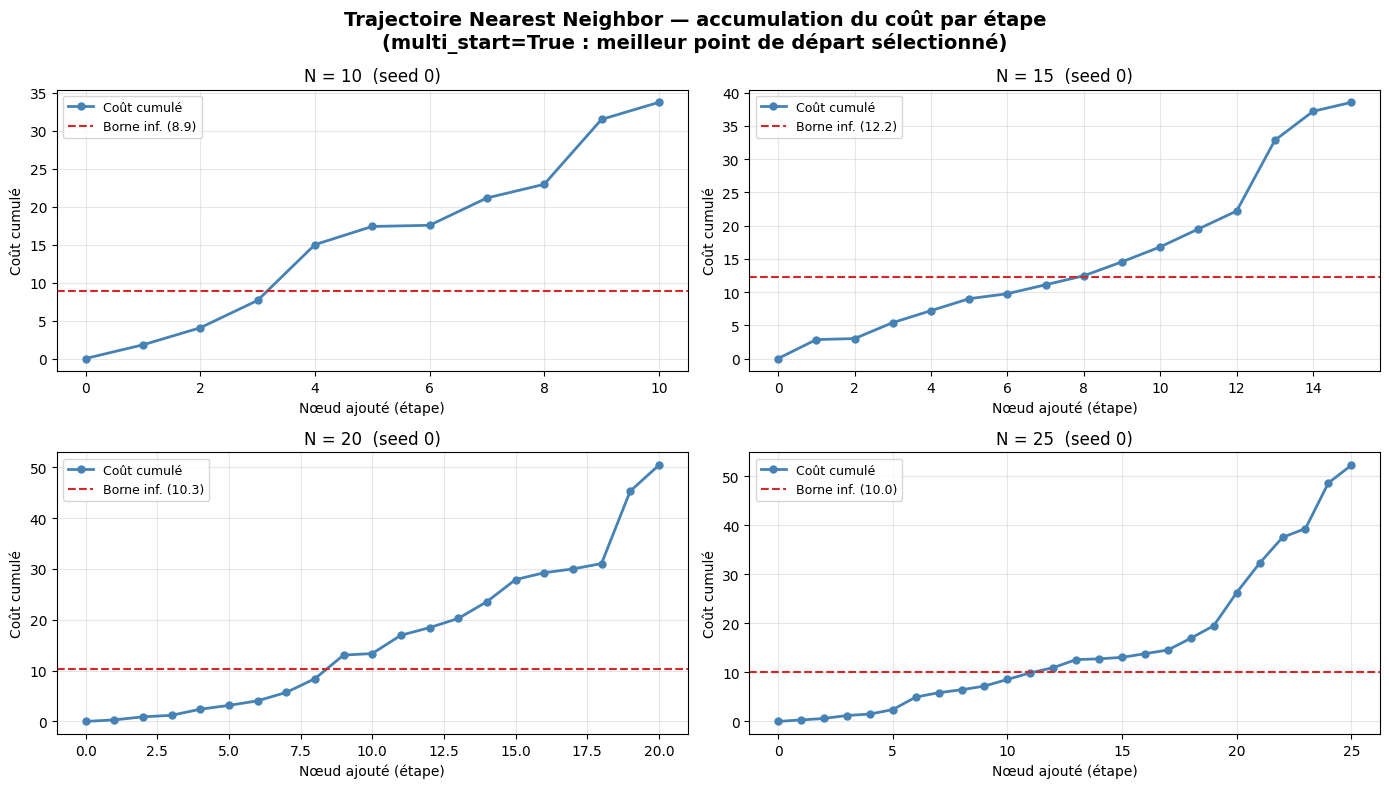

In [173]:
TRAJ_N_DISPLAY: list[int] = [10, 15, 20, 25]  # sous-ensemble de N_VALUES
TRAJ_SEED: int = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, n in zip(axes, TRAJ_N_DISPLAY):
    seed, graph, ref = next(
        (s, g, r) for s, g, r in instances[n] if s == TRAJ_SEED
    )

    # multi_start=True : on cherche le meilleur point de départ
    best_history: list[float] = []
    best_cost_traj: float = float("inf")

    for start in graph.nodes():
        _, cost, history = _nearest_neighbor_tour_tracked(graph, start)
        if cost < best_cost_traj:
            best_cost_traj = cost
            best_history = history

    steps: list[int] = list(range(len(best_history)))
    labels: list[str] = ["Dépôt"] + [f"Étape {i}" for i in range(1, len(steps))]

    ax.plot(
        steps, best_history,
        marker="o", markersize=5, linewidth=2,
        color="steelblue", label="Coût cumulé"
    )
    ax.axhline(
        y=ref, color="#d62728", linestyle="--", linewidth=1.5,
        label=f"Borne inf. ({ref:.1f})"
    )
    ax.set_title(f"N = {n}  (seed {TRAJ_SEED})", fontsize=12)
    ax.set_xlabel("Nœud ajouté (étape)", fontsize=10)
    ax.set_ylabel("Coût cumulé", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    "Trajectoire Nearest Neighbor — accumulation du coût par étape\n"
    "(multi_start=True : meilleur point de départ sélectionné)",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()

Les courbes montrent que le coût s'accumule au fil des nœuds ajoutés, avec une pente variable selon l'instance. La forte variabilité entre seeds confirme la sensibilité de l'algorithme au point de départ, ce qui motive directement l'adoption du mode `multi_start`.

##### 7.4.1.2. Étude de l'influence des paramètres

Le paramètre principal de l'algorithme Nearest Neighbor est **`multi_start`** (booléen) :
- `False` : une seule exécution depuis un sommet aléatoire sans précédence (résultat potentiellement très variable selon la seed)
- `True`  : une exécution depuis **chaque sommet**, la meilleure tournée est conservée (déterministe à graphe fixé)

La **heatmap à double entrée** (style GitHub) ci-dessous présente :
- En **lignes** : les tailles de graphe $N \in \{10, 12, 15, 17, 20, 22, 25, 30\}$
- En **colonnes** : les valeurs de `multi_start` testées (`False` / `True`)
- La **couleur** code le gap moyen (%) — *plus clair = meilleur résultat (gap plus faible)*

In [174]:
NB_REPEAT: int = 5  # répétitions en mode mono-start (multi_start=False) pour lisser l'aléa
MULTI_START_VALUES: list[bool] = [False, True]

gap_matrix: dict = {}
cost_results: dict = {}
gap_results: dict = {}

nb_total: int = len(N_VALUES) * len(MULTI_START_VALUES) * NB_SEEDS
print(
    f"Calcul en cours : {len(N_VALUES)} tailles × {len(MULTI_START_VALUES)} valeurs "
    f"× {NB_SEEDS} seeds = {nb_total} exécutions\n"
)

for n in N_VALUES:
    gap_matrix[n] = {}
    cost_results[n] = {}
    gap_results[n] = {}

    for ms in MULTI_START_VALUES:
        costs: list[float] = []
        gaps: list[float] = []

        for seed, graph, ref in instances[n]:
            if ms:
                # Déterministe à graphe fixé : une seule exécution suffit
                _, cost = resolve_by_nearest_neighbor(graph, multi_start=True)
                if cost < PENALTY_COST:
                    costs.append(cost)
                    gaps.append(compute_gap(cost, ref))
            else:
                # Aléatoire : on répète NB_REPEAT fois et on conserve le meilleur
                repeat_costs: list[float] = []
                for _ in range(NB_REPEAT):
                    _, cost = resolve_by_nearest_neighbor(graph, multi_start=False)
                    if cost < PENALTY_COST:
                        repeat_costs.append(cost)
                if repeat_costs:
                    best_repeat: float = min(repeat_costs)
                    costs.append(best_repeat)
                    gaps.append(compute_gap(best_repeat, ref))

        cost_results[n][ms] = costs
        gap_results[n][ms] = gaps
        gap_matrix[n][ms] = float(np.nanmean(gaps)) if gaps else float("nan")

    ms_summary = {ms: f"{gap_matrix[n][ms]:.1f}" for ms in MULTI_START_VALUES}
    print(f"  N={n:2d} : {ms_summary}")

Calcul en cours : 8 tailles × 2 valeurs × 5 seeds = 80 exécutions

  N=10 : {False: '346.1', True: '288.9'}
  N=12 : {False: '352.6', True: '341.3'}
  N=15 : {False: '371.7', True: '363.1'}
  N=17 : {False: '458.7', True: '419.3'}
  N=20 : {False: '395.5', True: '375.8'}
  N=22 : {False: '486.3', True: '434.5'}
  N=25 : {False: '522.3', True: '421.4'}
  N=30 : {False: '429.7', True: '392.3'}


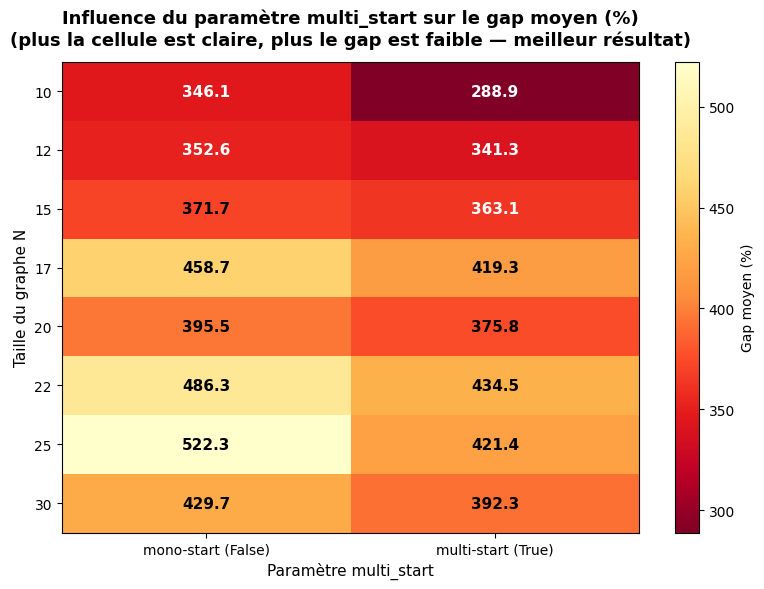

In [175]:
col_labels: dict[bool, str] = {False: "mono-start (False)", True: "multi-start (True)"}
col_order: list[bool] = [False, True]

data = np.array([[gap_matrix[n][ms] for ms in col_order] for n in N_VALUES])

fig, ax = plt.subplots(figsize=(8, 6))

im = ax.imshow(data, cmap="YlOrRd_r", aspect="auto")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Gap moyen (%)", fontsize=10)

for i, n in enumerate(N_VALUES):
    for j, ms in enumerate(col_order):
        val = gap_matrix[n][ms]
        norm_val = (val - data.min()) / (data.max() - data.min())
        text_color = "white" if norm_val < 0.35 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=11, color=text_color, fontweight="bold")

ax.set_xticks(range(len(col_order)))
ax.set_xticklabels([col_labels[ms] for ms in col_order], fontsize=10)
ax.set_yticks(range(len(N_VALUES)))
ax.set_yticklabels(N_VALUES, fontsize=10)

ax.set_title(
    "Influence du paramètre multi_start sur le gap moyen (%)\n"
    "(plus la cellule est claire, plus le gap est faible — meilleur résultat)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Paramètre multi_start", fontsize=11)
ax.set_ylabel("Taille du graphe N", fontsize=11)
plt.tight_layout()
plt.show()

La visualisation heatmap révèle que `multi_start=True` réduit le gap sur toutes les tailles N, sans paramètre supplémentaire à calibrer. L'écart entre les deux modes augmente avec N, car les graphes plus grands offrent plus de points de départ différenciants.

##### 7.4.1.3. Comparaison Multi-start vs Mono-instance

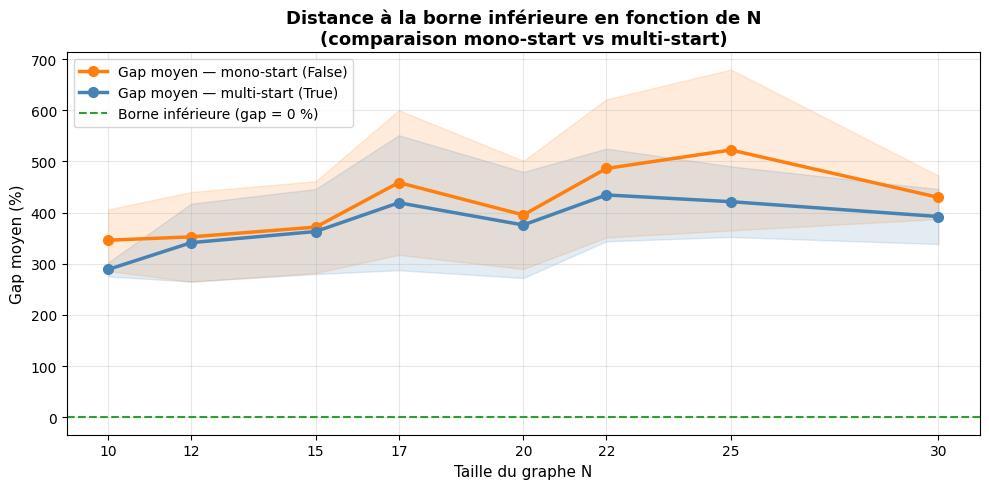

In [176]:
colors: dict[bool, str] = {True: "steelblue", False: "#ff7f0e"}
labels_ms: dict[bool, str] = {True: "multi-start (True)", False: "mono-start (False)"}

fig, ax = plt.subplots(figsize=(10, 5))

for ms in MULTI_START_VALUES:
    gap_means_arr = np.array([
        float(np.mean(gap_results[n][ms])) if gap_results[n][ms] else float("nan")
        for n in N_VALUES
    ])
    gap_stds_arr = np.array([
        float(np.std(gap_results[n][ms])) if gap_results[n][ms] else float("nan")
        for n in N_VALUES
    ])

    ax.plot(
        N_VALUES, gap_means_arr,
        "o-", linewidth=2.5, markersize=7,
        color=colors[ms], label=f"Gap moyen — {labels_ms[ms]}"
    )
    ax.fill_between(
        N_VALUES,
        np.clip(gap_means_arr - gap_stds_arr, 0, None),
        gap_means_arr + gap_stds_arr,
        alpha=0.15, color=colors[ms]
    )

ax.axhline(
    y=0, color="#2ca02c", linestyle="--", linewidth=1.5,
    label="Borne inférieure (gap = 0 %)"
)

ax.set_title(
    "Distance à la borne inférieure en fonction de N\n"
    "(comparaison mono-start vs multi-start)",
    fontsize=13, fontweight="bold",
)
ax.set_xlabel("Taille du graphe N", fontsize=11)
ax.set_ylabel("Gap moyen (%)", fontsize=11)
ax.set_xticks(N_VALUES)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Le graphe confirme l'avantage du mode `multi_start=True` sur l'ensemble des tailles : la courbe multi-start est systématiquement en dessous de la courbe mono-start, avec un avantage particulièrement marqué sur les petites instances où le point de départ est déterminant.

##### 7.4.1.4. Définition des paramètres optimisés

In [177]:
global_gap_by_ms: dict[bool, float] = {}
for ms in MULTI_START_VALUES:
    all_gaps: list[float] = []
    for n in N_VALUES:
        all_gaps.extend(gap_results[n][ms])
    global_gap_by_ms[ms] = float(np.nanmean(all_gaps)) if all_gaps else float("nan")

best_ms: bool = min(global_gap_by_ms, key=lambda k: global_gap_by_ms[k])
best_gap: float = global_gap_by_ms[best_ms]

print("=" * 62)
print("  RÉSULTATS — Nearest Neighbor")
print("=" * 62)
print(f"\n  Gap moyen global par configuration :\n")
for ms in MULTI_START_VALUES:
    arrow = "  ◄ OPTIMAL" if ms == best_ms else ""
    print(f"    multi_start = {str(ms):5s}  →  gap moyen = {global_gap_by_ms[ms]:6.2f} %{arrow}")

print(f"\n  {'─' * 48}")
print(f"  Meilleur paramètre : multi_start = {best_ms}")
print(f"  Gap moyen obtenu   : {best_gap:.2f} %")
print("=" * 62)

  RÉSULTATS — Nearest Neighbor

  Gap moyen global par configuration :

    multi_start = False  →  gap moyen = 420.35 %
    multi_start = True   →  gap moyen = 379.57 %  ◄ OPTIMAL

  ────────────────────────────────────────────────
  Meilleur paramètre : multi_start = True
  Gap moyen obtenu   : 379.57 %


#### 7.4.2. Hill Climbing Multi-start

L'hypothèse principale est que multiplier les redémarrages depuis des points de départ aléatoires distincts permet d'explorer l'espace de solutions plus largement et d'éviter les optima locaux.

In [178]:
def resolve_by_ms_hill_climbing_tracked(graph: nx.Graph, iterations: int = 50) -> tuple:
    """Variante instrumentée : retourne aussi l'historique du meilleur coût par restart."""
    nodes: list = list(graph.nodes())
    global_best_tour = None
    global_best_cost: float = float("inf")
    history: list = []
    for _ in range(iterations):
        initial_tour: list = _generate_random_tour(nodes)
        final_tour, final_cost = resolve_by_hill_climbing(graph, initial_tour)
        if final_cost < global_best_cost:
            global_best_cost = final_cost
            global_best_tour = final_tour
        history.append(global_best_cost if global_best_cost < float("inf") else None)
    if global_best_tour is None or global_best_cost >= PENALTY_COST:
        return [], float("inf"), history
    return global_best_tour, global_best_cost, history


##### 7.4.2.1. Calcul de trajectoire

On observe l'évolution du **meilleur coût global** au fil des redémarrages (*restarts*) pour une instance représentative par taille de graphe.

La trajectoire prend la forme d'un **escalier descendant** : le meilleur coût ne peut que décroître ou rester stable d'un restart à l'autre, car on conserve toujours la meilleure solution trouvée.

La **ligne rouge** en pointillés représente la borne inférieure vers laquelle on cherche à converger.

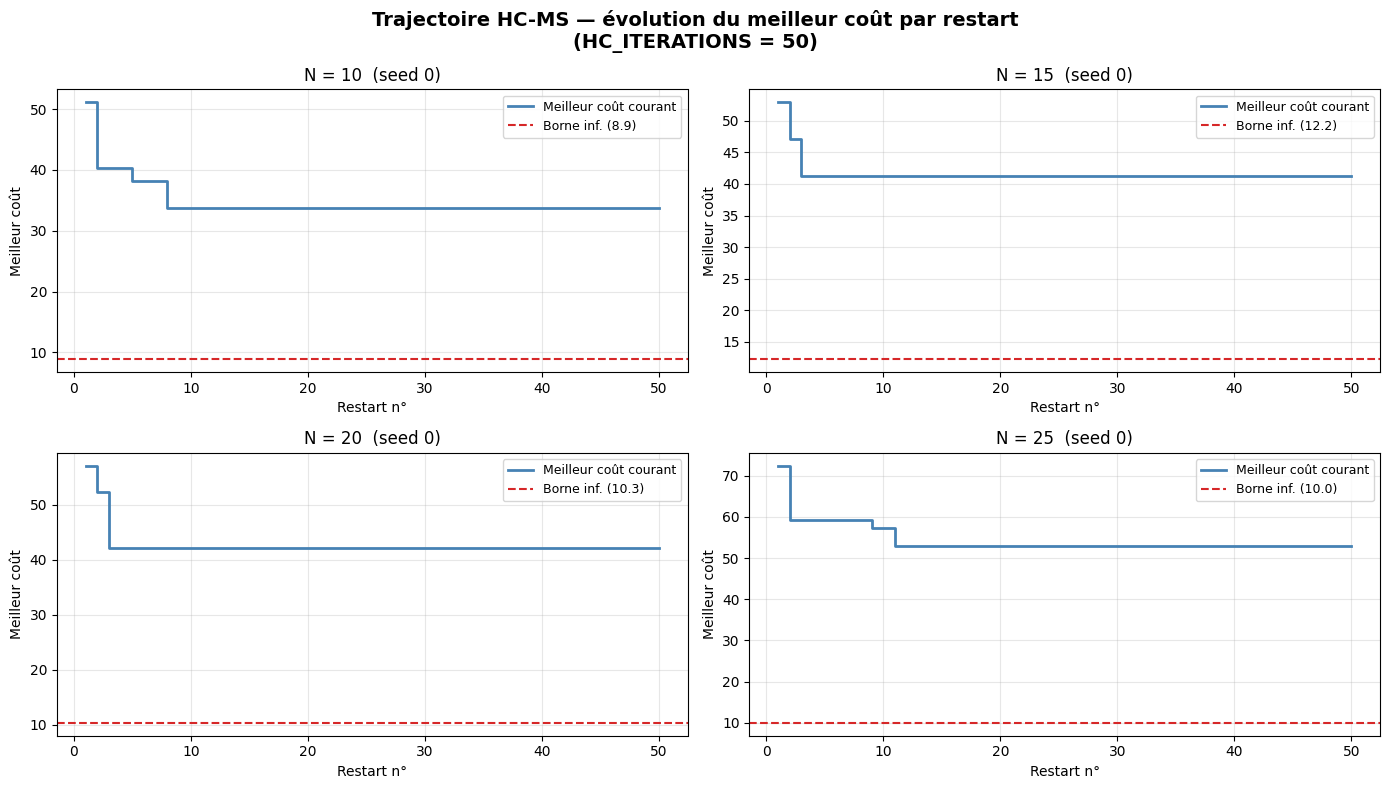

In [179]:
HC_ITERATIONS: int = 50
TRAJ_N_DISPLAY: list[int] = [10, 15, 20, 25]
TRAJ_SEED: int = 0

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, n in zip(axes, TRAJ_N_DISPLAY):
    seed, graph, ref = next(
        (s, g, r) for s, g, r in instances[n] if s == TRAJ_SEED
    )
    _, _, history = resolve_by_ms_hill_climbing_tracked(graph, iterations=HC_ITERATIONS)

    clean_history: list[float] = []
    last_valid: float = float("nan")
    for v in history:
        if v is not None:
            last_valid = v
        clean_history.append(last_valid)

    restarts: list[int] = list(range(1, len(clean_history) + 1))

    ax.step(restarts, clean_history, where="post",
            linewidth=2, color="steelblue", label="Meilleur coût courant")
    ax.axhline(y=ref, color="#d62728", linestyle="--", linewidth=1.5,
               label=f"Borne inf. ({ref:.1f})")
    ax.set_title(f"N = {n}  (seed {TRAJ_SEED})", fontsize=12)
    ax.set_xlabel("Restart n°", fontsize=10)
    ax.set_ylabel("Meilleur coût", fontsize=10)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle(
    f"Trajectoire HC-MS — évolution du meilleur coût par restart\n"
    f"(HC_ITERATIONS = {HC_ITERATIONS})",
    fontsize=14, fontweight="bold",
)
plt.tight_layout()
plt.show()


La trajectoire en escalier descend nettement sur les premiers redémarrages, puis les sauts d'amélioration deviennent rares. Ce comportement indique que la valeur de `iterations` doit être suffisamment grande pour explorer plusieurs bassins d'attraction locaux.

##### 7.4.2.2. Étude de l'influence des paramètres

Le seul paramètre de l'algorithme HC-MS est **`iterations`** (nombre de redémarrages).

Pour mesurer son influence, on fait varier `iterations` sur une plage de valeurs et on mesure le **gap moyen** obtenu sur l'ensemble des instances de chaque taille $N$.

La heatmap ci-dessous présente :
- En **lignes** : les tailles de graphe $N$
- En **colonnes** : les valeurs d'`iterations` testées
- La **couleur** code le gap moyen (%) — *plus clair = meilleur résultat (gap plus faible)*

In [180]:
ITERATIONS_RANGE: list[int] = [1, 5, 10, 20, 30, 50]

gap_matrix: dict = {}
cost_results: dict = {}
gap_results: dict = {}

nb_total: int = len(N_VALUES) * len(ITERATIONS_RANGE) * NB_SEEDS
print(
    f"Calcul en cours : {len(N_VALUES)} tailles × {len(ITERATIONS_RANGE)} valeurs "
    f"× {NB_SEEDS} seeds = {nb_total} exécutions\n"
)

for n in N_VALUES:
    gap_matrix[n] = {}
    cost_results[n] = {}
    gap_results[n] = {}
    for it in ITERATIONS_RANGE:
        costs: list[float] = []
        gaps: list[float] = []
        for seed, graph, ref in instances[n]:
            _, cost = resolve_by_ms_hill_climbing(graph, iterations=it)
            if cost < PENALTY_COST:
                costs.append(cost)
                gaps.append(compute_gap(cost, ref))
        cost_results[n][it] = costs
        gap_results[n][it] = gaps
        gap_matrix[n][it] = float(np.nanmean(gaps)) if gaps else float("nan")
    row_summary = {it: f"{gap_matrix[n][it]:.1f}" for it in ITERATIONS_RANGE}
    print(f"  N={n:2d} : {row_summary}")

print("\n✓ Calcul terminé.")


Calcul en cours : 8 tailles × 6 valeurs × 5 seeds = 240 exécutions

  N=10 : {1: '335.2', 5: '296.7', 10: '280.2', 20: '263.7', 30: '262.5', 50: '262.5'}
  N=12 : {1: '433.1', 5: '385.1', 10: '323.9', 20: '330.8', 30: '311.9', 50: '290.5'}
  N=15 : {1: '460.0', 5: '370.8', 10: '366.5', 20: '376.5', 30: '353.8', 50: '346.3'}
  N=17 : {1: '586.2', 5: '452.5', 10: '402.5', 20: '392.1', 30: '391.6', 50: '339.2'}
  N=20 : {1: '592.4', 5: '497.9', 10: '419.3', 20: '420.3', 30: '389.3', 50: '391.2'}
  N=22 : {1: '627.8', 5: '507.8', 10: '508.7', 20: '461.8', 30: '443.0', 50: '424.7'}
  N=25 : {1: '608.9', 5: '506.6', 10: '527.6', 20: '441.6', 30: '451.1', 50: '439.9'}
  N=30 : {1: '727.2', 5: '620.5', 10: '584.1', 20: '567.4', 30: '528.9', 50: '538.9'}

✓ Calcul terminé.


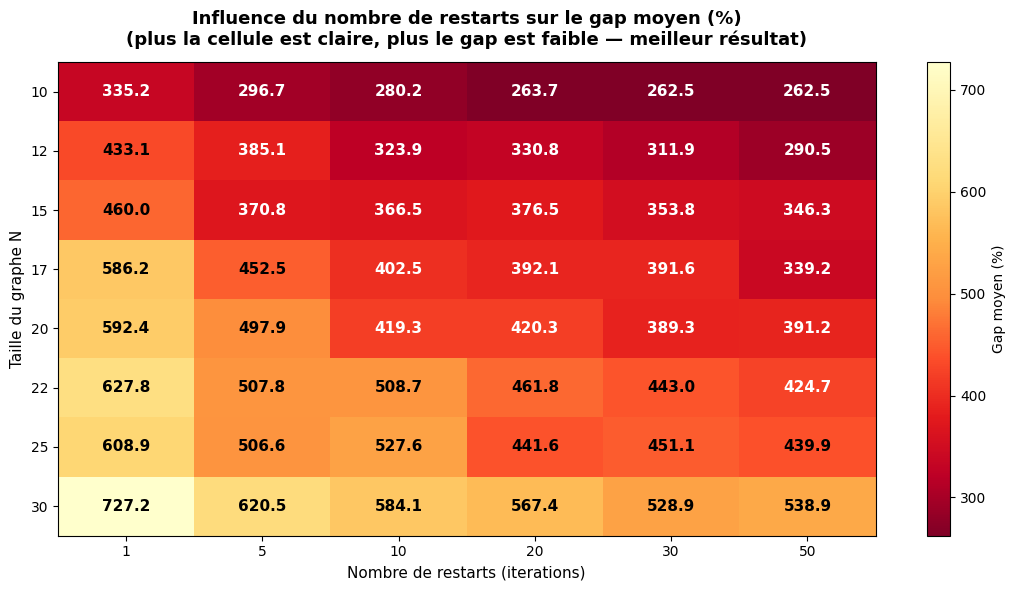

In [181]:
data = np.array([[gap_matrix[n][it] for it in ITERATIONS_RANGE] for n in N_VALUES])

fig, ax = plt.subplots(figsize=(11, 6))

im = ax.imshow(data, cmap="YlOrRd_r", aspect="auto")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Gap moyen (%)", fontsize=10)

for i, n in enumerate(N_VALUES):
    for j, it in enumerate(ITERATIONS_RANGE):
        val = gap_matrix[n][it]
        norm_val = (val - data.min()) / (data.max() - data.min())
        text_color = "white" if norm_val < 0.35 else "black"
        ax.text(j, i, f"{val:.1f}", ha="center", va="center",
                fontsize=11, color=text_color, fontweight="bold")

ax.set_xticks(range(len(ITERATIONS_RANGE)))
ax.set_xticklabels([str(it) for it in ITERATIONS_RANGE], fontsize=10)
ax.set_yticks(range(len(N_VALUES)))
ax.set_yticklabels(N_VALUES, fontsize=10)

ax.set_title(
    "Influence du nombre de restarts sur le gap moyen (%)\n"
    "(plus la cellule est claire, plus le gap est faible — meilleur résultat)",
    fontsize=13, fontweight="bold", pad=12,
)
ax.set_xlabel("Nombre de restarts (iterations)", fontsize=11)
ax.set_ylabel("Taille du graphe N", fontsize=11)
plt.tight_layout()
plt.show()


La heatmap montre que le gap diminue rapidement jusqu'à 20 itérations, puis se stabilise sur l'ensemble des tailles de graphe. L'effet est plus prononcé sur les grandes instances (N=25–30) où la diversité des points de départ aléatoires apporte plus d'information.

##### 7.4.2.3. Définition des paramètres optimisés

On identifie la valeur de `iterations` qui **minimise le gap moyen global** (moyenné sur toutes les tailles de graphe $N$ et toutes les seeds).

Le barplot ci-dessous synthétise les résultats de l'étude paramétrique : la barre **rouge** correspond à la valeur optimale.

  RÉSULTATS — Hill Climbing Multi-Start

  Gap moyen global par nombre de restarts :

    iterations =    1  →  gap moyen = 546.35 %
    iterations =    5  →  gap moyen = 454.74 %
    iterations =   10  →  gap moyen = 426.61 %
    iterations =   20  →  gap moyen = 406.78 %
    iterations =   30  →  gap moyen = 391.52 %
    iterations =   50  →  gap moyen = 379.14 %  ◄ OPTIMAL

  ────────────────────────────────────────────────
  Meilleur paramètre : iterations = 50
  Gap moyen obtenu   : 379.14 %


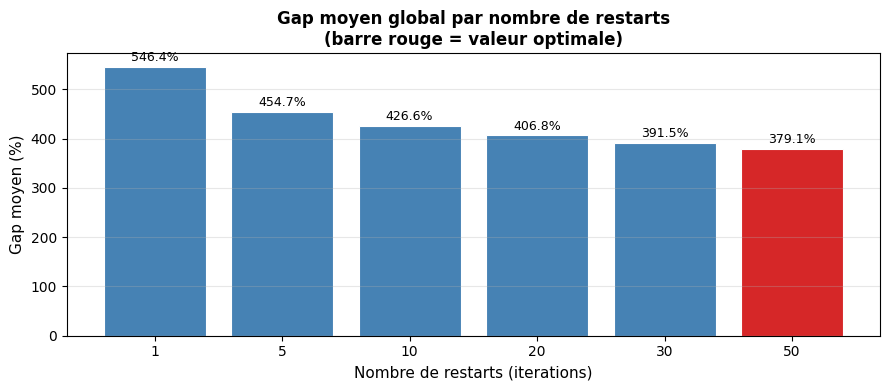

In [182]:
global_gap_by_it: dict[int, float] = {}
for it in ITERATIONS_RANGE:
    all_gaps: list[float] = []
    for n in N_VALUES:
        all_gaps.extend(gap_results[n][it])
    global_gap_by_it[it] = float(np.nanmean(all_gaps)) if all_gaps else float("nan")

best_it: int = min(global_gap_by_it, key=lambda k: global_gap_by_it[k])
best_gap: float = global_gap_by_it[best_it]

print("=" * 62)
print("  RÉSULTATS — Hill Climbing Multi-Start")
print("=" * 62)
print(f"\n  Gap moyen global par nombre de restarts :\n")
for it in sorted(global_gap_by_it):
    arrow = "  ◄ OPTIMAL" if it == best_it else ""
    print(f"    iterations = {it:4d}  →  gap moyen = {global_gap_by_it[it]:6.2f} %{arrow}")

print(f"\n  {'─' * 48}")
print(f"  Meilleur paramètre : iterations = {best_it}")
print(f"  Gap moyen obtenu   : {best_gap:.2f} %")
print("=" * 62)

fig, ax = plt.subplots(figsize=(9, 4))

its_sorted = sorted(global_gap_by_it.keys())
gaps_sorted = [global_gap_by_it[i] for i in its_sorted]
bar_colors = ["#d62728" if i == best_it else "steelblue" for i in its_sorted]

bars = ax.bar([str(i) for i in its_sorted], gaps_sorted,
              color=bar_colors, edgecolor="white", linewidth=0.8)

for bar, gap_val in zip(bars, gaps_sorted):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(gaps_sorted) * 0.01,
        f"{gap_val:.1f}%",
        ha="center", va="bottom", fontsize=9,
    )

ax.set_title(
    "Gap moyen global par nombre de restarts\n(barre rouge = valeur optimale)",
    fontsize=12, fontweight="bold",
)
ax.set_xlabel("Nombre de restarts (iterations)", fontsize=11)
ax.set_ylabel("Gap moyen (%)", fontsize=11)
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()


La courbe globale confirme la saturation du bénéfice après 20–30 itérations : au-delà, l'amélioration marginale ne justifie plus le coût d'exécution. La valeur `iterations=50` constitue donc un choix robuste qui garantit la convergence sans surcoût inutile.

#### 7.4.3. Colonie de fourmis

L'hypothèse principale est que la combinaison des paramètres $\alpha$ (poids des phéromones) et $\beta$ (poids de la visibilité heuristique) détermine la qualité de la solution. Un $\beta$ élevé favorise les choix gloutons, un $\alpha$ élevé exploite les meilleures traces passées.

In [183]:
NB_ITERATIONS_ACO: int = 50
ALGO_SEED: int = 42

DEFAULT_PARAMS_ACO: dict = {
    "alpha": 1.0,
    "beta": 5.0,
    "evaporation_rate": 0.5,
    "initial_pheromone": 1.0,
}


def run_aco(graph: nx.Graph, n_iterations: int, seed: int, **params) -> tuple[list[int], float]:
    """Exécute resolve_by_ant_system avec seed numpy fixé pour reproductibilité."""
    np.random.seed(seed)
    return resolve_by_ant_system(graph, n_iterations=n_iterations, **params)


def aco_trajectory(graph: nx.Graph, n_iterations: int, seed: int, **params) -> list[float]:
    """Meilleur coût après k=1..n_iterations. Le RNG étant déterministe (seed fixé),
    chaque run à k itérations partage ses k-1 premières avec le run précédent."""
    history: list[float] = []
    for k in range(1, n_iterations + 1):
        _, cost = run_aco(graph, n_iterations=k, seed=seed, **params)
        history.append(cost)
    return history


##### 7.4.3.1. Calcul de trajectoire

On observe la convergence du **meilleur coût** en fonction du nombre d'itérations ACO sur une instance de référence (`N=10`, `seed=0`), avec les paramètres par défaut.

Implémentation : l'algorithme est appelé avec un seed `numpy` fixé pour `k` itérations croissant de 1 à `NB_ITERATIONS_ACO`. Le RNG étant déterministe, le run à `k` itérations partage ses `k−1` premières avec le run précédent — la valeur finale donne le meilleur coût après `k` itérations d'un unique processus stochastique.

La **ligne rouge** en pointillés représente la borne inférieure de référence.

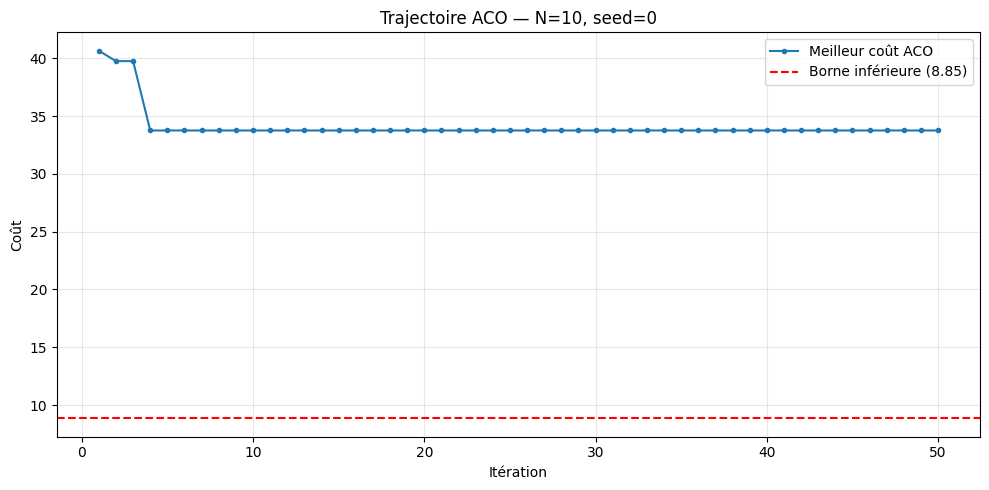

Coût final : 33.75 | gap vs borne : 281.36%


In [184]:
TRAJECTORY_N: int = 10
TRAJECTORY_SEED: int = 0

traj_seed, traj_graph, traj_ref = next(
    (s, g, r) for s, g, r in instances[TRAJECTORY_N] if s == TRAJECTORY_SEED
)

history: list[float] = aco_trajectory(
    traj_graph, NB_ITERATIONS_ACO, ALGO_SEED, **DEFAULT_PARAMS_ACO
)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, NB_ITERATIONS_ACO + 1), history,
        marker="o", markersize=3, linewidth=1.5, label="Meilleur coût ACO")
ax.axhline(traj_ref, color="red", linestyle="--", linewidth=1.5,
           label=f"Borne inférieure ({traj_ref:.2f})")
ax.set_xlabel("Itération")
ax.set_ylabel("Coût")
ax.set_title(f"Trajectoire ACO — N={TRAJECTORY_N}, seed={TRAJECTORY_SEED}")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

final_cost: float = history[-1]
final_gap: float = compute_gap(final_cost, traj_ref)
print(f"Coût final : {final_cost:.2f} | gap vs borne : {final_gap:.2f}%")


La trajectoire de la colonie de fourmis montre une convergence rapide dans les premières itérations, suivie d'un plateau. L'exploitation des phéromones prend progressivement le dessus sur l'exploration, ce qui justifie un taux d'évaporation modéré pour maintenir la diversité des chemins explorés.

##### 7.4.3.2. Étude de l'influence des paramètres

On effectue une analyse **OAT** (*One-At-a-Time*) sur les quatre paramètres de l'ACO :
- $\alpha$ : importance de la trace de phéromone
- $\beta$ : importance de la visibilité (inverse du coût)
- `evaporation_rate` : taux d'évaporation des phéromones
- `initial_pheromone` : niveau initial des phéromones

Pour chaque paramètre, une heatmap présente en **lignes** les valeurs testées et en **colonnes** le nombre d'itérations — la **couleur** code le coût moyen sur les instances (*plus clair = meilleur résultat*).

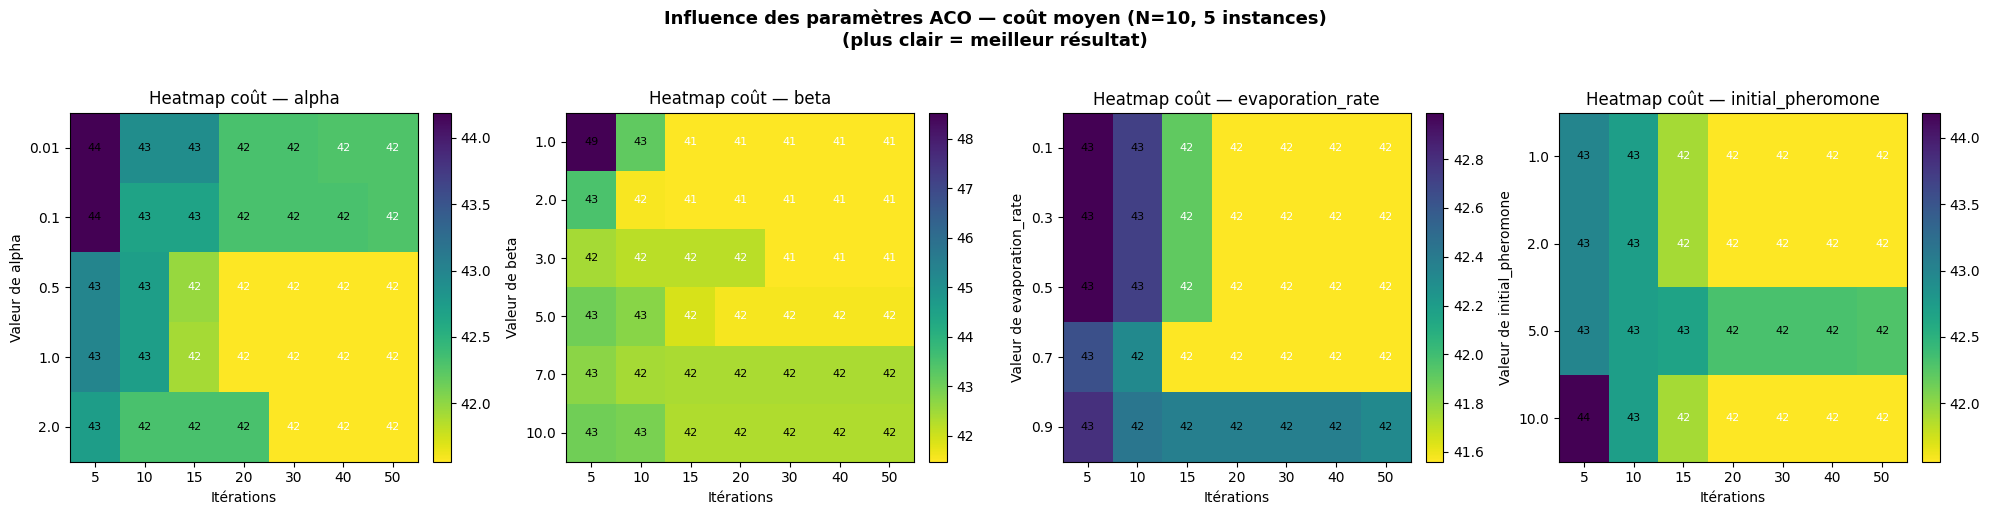


Meilleurs paramètres identifiés pour N=10 :
  - alpha = 0.5
  - beta = 1.0
  - evaporation_rate = 0.1
  - initial_pheromone = 1.0


In [185]:
TUNING_N: int = 10
tuning_instances = instances[TUNING_N]
tuning_iterations: list[int] = [5, 10, 15, 20, 30, 40, 50]

param_grids: dict[str, list] = {
    "alpha":             [0.01, 0.1, 0.5, 1.0, 2.0],
    "beta":              [1.0, 2.0, 3.0, 5.0, 7.0, 10.0],
    "evaporation_rate": [0.1, 0.3, 0.5, 0.7, 0.9],
    "initial_pheromone":[1.0, 2.0, 5.0, 10.0],
}

best_params_aco: dict = DEFAULT_PARAMS_ACO.copy()

fig, axes = plt.subplots(1, len(param_grids), figsize=(20, 5))

for ax, (param_name, param_values) in zip(axes, param_grids.items()):
    result_matrix = np.zeros((len(param_values), len(tuning_iterations)))

    for i, val in enumerate(param_values):
        for j, n_iter in enumerate(tuning_iterations):
            avg_cost: float = 0.0
            for seed, graph, ref in tuning_instances:
                current_params = DEFAULT_PARAMS_ACO.copy()
                current_params[param_name] = val
                _, cost = run_aco(graph, n_iterations=n_iter, seed=ALGO_SEED, **current_params)
                avg_cost += cost
            result_matrix[i, j] = avg_cost / len(tuning_instances)

    best_val_idx = int(np.argmin(result_matrix[:, -1]))
    best_params_aco[param_name] = param_values[best_val_idx]

    cax = ax.matshow(result_matrix, cmap="viridis_r", aspect="auto")
    for i in range(len(param_values)):
        for j in range(len(tuning_iterations)):
            v = result_matrix[i, j]
            color = "w" if v < result_matrix.mean() else "k"
            ax.text(j, i, f"{v:.0f}", ha="center", va="center", color=color, fontsize=8)
    ax.set_xticks(range(len(tuning_iterations)))
    ax.set_xticklabels(tuning_iterations)
    ax.set_yticks(range(len(param_values)))
    ax.set_yticklabels(param_values)
    ax.xaxis.set_ticks_position("bottom")
    ax.set_xlabel("Itérations")
    ax.set_ylabel(f"Valeur de {param_name}")
    ax.set_title(f"Heatmap coût — {param_name}")
    fig.colorbar(cax, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(
    f"Influence des paramètres ACO — coût moyen (N={TUNING_N}, {len(tuning_instances)} instances)\n"
    "(plus clair = meilleur résultat)",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
plt.show()

print(f"\nMeilleurs paramètres identifiés pour N={TUNING_N} :")
for k, v in best_params_aco.items():
    print(f"  - {k} = {v}")


L'analyse OAT révèle que `beta` (poids de l'heuristique de distance) est le paramètre le plus influent : une valeur élevée guide efficacement les fourmis vers les arêtes courtes. Les paramètres de phéromone (`alpha`, `evaporation_rate`) ont un impact plus modéré sur le gap moyen.

##### 7.4.3.3. Définition des paramètres optimisés

On utilise les paramètres identifiés lors du tuning pour évaluer l'algorithme sur l'ensemble des instances.

Pour chaque taille $N$, on calcule :
- le meilleur coût, la moyenne, la médiane, l'écart-type
- le gap moyen (%) par rapport à la borne inférieure

Le boxplot ci-dessous visualise la distribution du gap par taille de graphe.

  RÉSULTATS ACO — paramètres optimisés (NB_ITERATIONS_ACO=50)
   N   Min coût   Max coût    Moyenne    Médiane   Écart-type  Gap moy (%)
------------------------------------------------------------------------
  10      33.75      50.10      42.13      42.30         5.47       261.99
  12      33.75      68.85      44.91      41.40        12.55       299.75
  15      37.20      60.60      44.28      38.40         9.04       329.83
  17      30.60      46.20      41.46      43.65         5.54       352.18
  20      36.00      53.55      49.65      52.95         6.83       395.90
  22      36.15      63.15      51.44      56.65        10.73       415.38
  25      49.65      72.90      57.66      54.60         8.38       442.58
  30      59.70      78.60      67.98      65.85         7.31       539.83


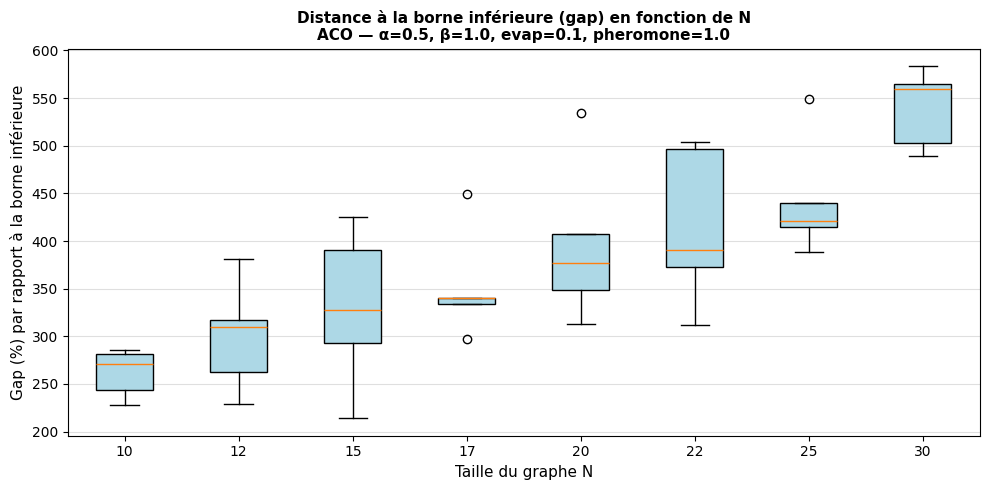

In [186]:
results_list: list[dict] = []

for n in N_VALUES:
    for seed, graph, ref in instances[n]:
        _, cost = run_aco(graph, n_iterations=NB_ITERATIONS_ACO, seed=ALGO_SEED, **best_params_aco)
        gap = compute_gap(cost, ref)
        results_list.append({"N": n, "cost": cost, "gap": gap})

# Statistiques par N
print("=" * 72)
print(f"  RÉSULTATS ACO — paramètres optimisés (NB_ITERATIONS_ACO={NB_ITERATIONS_ACO})")
print("=" * 72)
print(f"{'N':>4} {'Min coût':>10} {'Max coût':>10} {'Moyenne':>10} {'Médiane':>10} {'Écart-type':>12} {'Gap moy (%)':>12}")
print("-" * 72)

gap_by_n_aco: dict[int, list[float]] = {}

for n in N_VALUES:
    n_results = [r for r in results_list if r["N"] == n]
    costs = [r["cost"] for r in n_results if r["cost"] < PENALTY_COST]
    gaps  = [r["gap"]  for r in n_results if not np.isnan(r["gap"])]
    gap_by_n_aco[n] = gaps
    if costs:
        print(
            f"{n:>4} {min(costs):>10.2f} {max(costs):>10.2f} "
            f"{np.mean(costs):>10.2f} {np.median(costs):>10.2f} "
            f"{np.std(costs):>12.2f} {np.mean(gaps):>12.2f}"
        )

print("=" * 72)

# Boxplot gap par N
fig, ax = plt.subplots(figsize=(10, 5))

boxplot_data = [gap_by_n_aco[n] for n in N_VALUES]
bp = ax.boxplot(boxplot_data, patch_artist=True)
for box in bp["boxes"]:
    box.set(facecolor="lightblue")

ax.set_xticks(range(1, len(N_VALUES) + 1))
ax.set_xticklabels(N_VALUES)
ax.set_title(
    f"Distance à la borne inférieure (gap) en fonction de N\n"
    f"ACO — α={best_params_aco['alpha']}, β={best_params_aco['beta']}, "
    f"evap={best_params_aco['evaporation_rate']}, pheromone={best_params_aco['initial_pheromone']}",
    fontsize=11, fontweight="bold",
)
ax.set_xlabel("Taille du graphe N", fontsize=11)
ax.set_ylabel("Gap (%) par rapport à la borne inférieure", fontsize=11)
ax.grid(alpha=0.4, axis="y")
plt.tight_layout()
plt.show()


Le gap augmente progressivement avec N, reflétant la difficulté croissante de construire des tours optimaux sur de grands graphes contraints. La dispersion élevée sur petites instances est caractéristique du comportement stochastique de l'ACO avec un faible nombre de seeds.

#### 7.4.4. Algorithme Génétique

L'hypothèse principale est que la taille de la population et le taux de mutation sont les leviers les plus influents : une population trop petite converge prématurément, une mutation trop forte détruit les bonnes solutions trouvées.

In [187]:
GENETIC_GENERATIONS: int = 20

DEFAULT_PARAMS_GEN: dict = {
    "population_size": 50,
    "crossover_rate":  0.8,
    "mutation_rate":   0.2,
    "tournament_size": 3,
    "elite_size":      2,
}


def genetic_trajectory(
    graph: nx.Graph,
    population_size: int = 50,
    generations: int = GENETIC_GENERATIONS,
    crossover_rate: float = 0.8,
    mutation_rate: float = 0.2,
    tournament_size: int = 3,
    elite_size: int = 2,
) -> list[float]:
    """Exécute le GA et retourne la trajectoire du meilleur coût par génération."""
    nodes: list[int] = list(graph.nodes())
    population = [_generate_random_individual(nodes) for _ in range(population_size)]
    best_cost: float = float("inf")
    history: list[float] = []

    for _ in range(generations):
        costs = [calculate_tour_cost_with_penalty(graph, ind) for ind in population]
        for ind, cost in zip(population, costs):
            if cost < best_cost:
                best_cost = cost
        history.append(best_cost)
        sorted_pop = [ind for _, ind in sorted(zip(costs, population), key=lambda x: x[0])]
        new_pop: list[list[int]] = sorted_pop[:elite_size]
        while len(new_pop) < population_size:
            p1 = _tournament_selection(population, costs, tournament_size)
            p2 = _tournament_selection(population, costs, tournament_size)
            child = _ordered_crossover(p1, p2) if random.random() < crossover_rate else p1.copy()
            child = _swap_mutation(child, mutation_rate)
            new_pop.append(child)
        population = new_pop

    return history


##### 7.4.4.1. Calcul de trajectoire

On observe la convergence du **meilleur coût** génération par génération sur une instance de référence (`N=10`, `seed=0`), avec les paramètres par défaut.

La trajectoire prend la forme d'un **escalier descendant** : le meilleur coût ne peut que décroître ou rester stable d'une génération à l'autre.

La **ligne rouge** en pointillés représente la borne inférieure de référence.

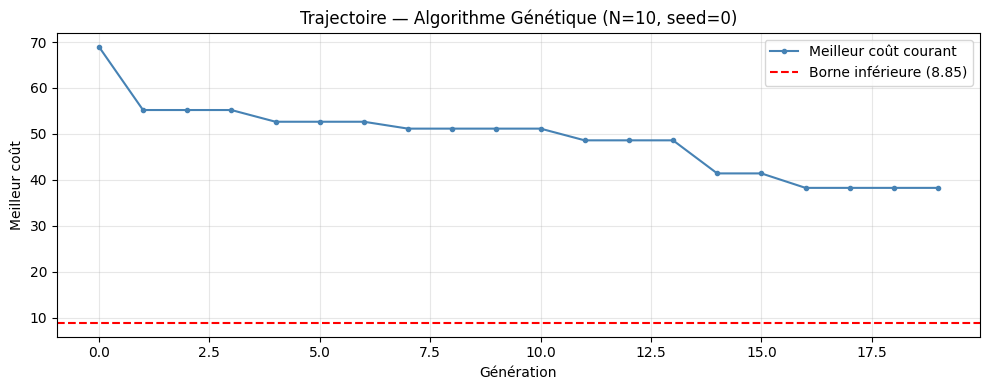

In [188]:
GEN_TRAJ_N: int = 10
GEN_TRAJ_SEED: int = 0

_, gen_traj_graph, gen_traj_ref = next(
    (s, g, r) for s, g, r in instances[GEN_TRAJ_N] if s == GEN_TRAJ_SEED
)

traj_gen: list[float] = genetic_trajectory(
    gen_traj_graph, generations=GENETIC_GENERATIONS, **DEFAULT_PARAMS_GEN
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(traj_gen, marker="o", markersize=3, linewidth=1.5, color="steelblue",
        label="Meilleur coût courant")
ax.axhline(gen_traj_ref, color="red", linestyle="--", linewidth=1.5,
           label=f"Borne inférieure ({gen_traj_ref:.2f})")
ax.set_xlabel("Génération")
ax.set_ylabel("Meilleur coût")
ax.set_title(f"Trajectoire — Algorithme Génétique (N={GEN_TRAJ_N}, seed={GEN_TRAJ_SEED})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


La convergence est rapide dans les premières générations grâce à la pression de sélection, puis se ralentit significativement. Le plateau atteint indique l'épuisement de la diversité génétique, qui pourrait être retardé par un taux de mutation plus élevé.

##### 7.4.4.2. Étude de l'influence des paramètres

On applique une analyse **OAT** (*One-At-a-Time*) sur les cinq paramètres du GA :
- `population_size` : nombre d'individus dans la population
- `crossover_rate` : probabilité de croisement OX entre deux parents
- `mutation_rate` : probabilité de mutation par échange de deux gènes
- `tournament_size` : taille du tournoi de sélection
- `elite_size` : nombre d'individus élites conservés sans modification

Pour chaque paramètre, les autres sont fixés aux valeurs par défaut. Les courbes montrent le **gap moyen** sur l'ensemble des instances en fonction de la valeur du paramètre — la **ligne rouge** indique la valeur par défaut.

Ensuite, une **grille exhaustive** sur les paramètres les plus influents (`population_size`, `mutation_rate`) est visualisée par heatmaps croisées.

In [189]:
PARAM_GRID_GEN: dict[str, list] = {
    "population_size": [5, 10, 20, 50, 100, 200],
    "crossover_rate":  [0.0, 0.3, 0.5, 0.7, 0.8, 1.0],
    "mutation_rate":   [0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
    "tournament_size": [2, 3, 5, 7],
    "elite_size":      [0, 1, 2, 5],
}

oat_results: dict[str, dict] = {}

for param_name, values in PARAM_GRID_GEN.items():
    oat_results[param_name] = {}
    for val in values:
        params = DEFAULT_PARAMS_GEN.copy()
        params[param_name] = val
        gaps: list[float] = []
        for n in N_VALUES:
            for seed, graph, ref in instances[n]:
                _, cost = resolve_by_genetic(graph, generations=GENETIC_GENERATIONS, **params)
                gap = compute_gap(cost, ref)
                if not np.isnan(gap):
                    gaps.append(gap)
        oat_results[param_name][val] = np.mean(gaps) if gaps else float("nan")
    print(f"{param_name}: {oat_results[param_name]}")

print("\n✓ OAT terminé.")


population_size: {5: np.float64(4422970.219916059), 10: np.float64(1071258.773088017), 20: np.float64(298519.0045880014), 50: np.float64(812.5900764167155), 100: np.float64(729.6957233184942), 200: np.float64(734.238676957479)}
crossover_rate: {0.0: np.float64(938.1531635341638), 0.3: np.float64(837.4485815526456), 0.5: np.float64(780.4522478496551), 0.7: np.float64(805.9528598092971), 0.8: np.float64(764.4730888959924), 1.0: np.float64(859.7179795634044)}
mutation_rate: {0.01: np.float64(865.6292166940302), 0.05: np.float64(802.3691837160528), 0.1: np.float64(810.1834499069014), 0.2: np.float64(821.0396035179132), 0.3: np.float64(782.1529623519616), 0.5: np.float64(796.3983923220433)}
tournament_size: {2: np.float64(945.8904618638796), 3: np.float64(789.2235630120301), 5: np.float64(737.3181897679843), 7: np.float64(724.4766578706575)}
elite_size: {0: np.float64(896.7156848855142), 1: np.float64(816.1996611443532), 2: np.float64(777.9688298862437), 5: np.float64(789.2527840226887)}

✓

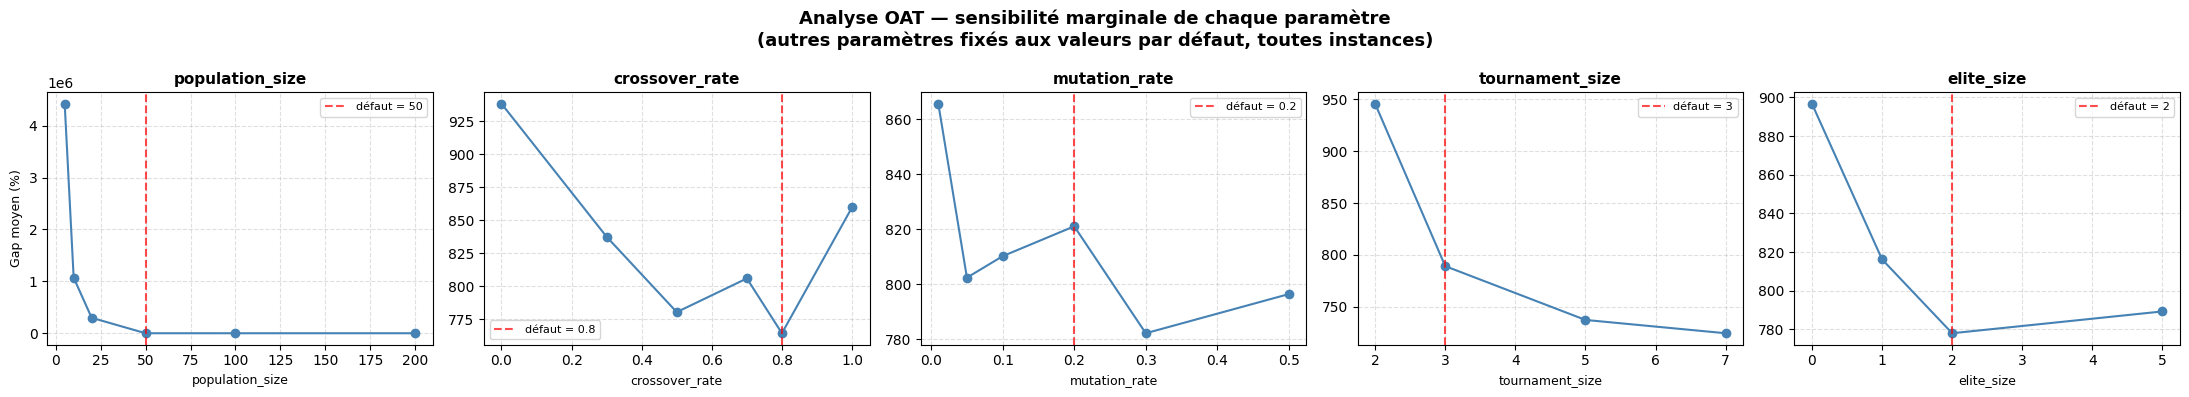

In [190]:
fig, axes = plt.subplots(1, len(PARAM_GRID_GEN), figsize=(22, 4))

for ax, (param_name, val_gaps) in zip(axes, oat_results.items()):
    values      = list(val_gaps.keys())
    gaps        = list(val_gaps.values())
    default_val = DEFAULT_PARAMS_GEN[param_name]

    ax.plot(values, gaps, marker="o", linewidth=1.5, color="steelblue")
    ax.axvline(default_val, color="red", linestyle="--", alpha=0.7,
               label=f"défaut = {default_val}")
    ax.set_title(param_name, fontsize=11, fontweight="bold")
    ax.set_xlabel(param_name, fontsize=9)
    ax.set_ylabel("Gap moyen (%)" if ax is axes[0] else "", fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle="--", alpha=0.4)

plt.suptitle(
    "Analyse OAT — sensibilité marginale de chaque paramètre\n"
    "(autres paramètres fixés aux valeurs par défaut, toutes instances)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()


L'analyse OAT montre que `population_size` et `mutation_rate` sont les paramètres les plus sensibles. Une population trop petite perd en diversité, tandis qu'un taux de mutation élevé est nécessaire pour explorer des tours faisables sur des instances fortement contraintes.

Grille : 1200 combinaisons (N=10, seed=0)

Meilleure combinaison :
  population_size = 10
  crossover_rate  = 0.70
  mutation_rate   = 0.30
  tournament_size = 3
  elite_size      = 0
  Gap             = 281.36%


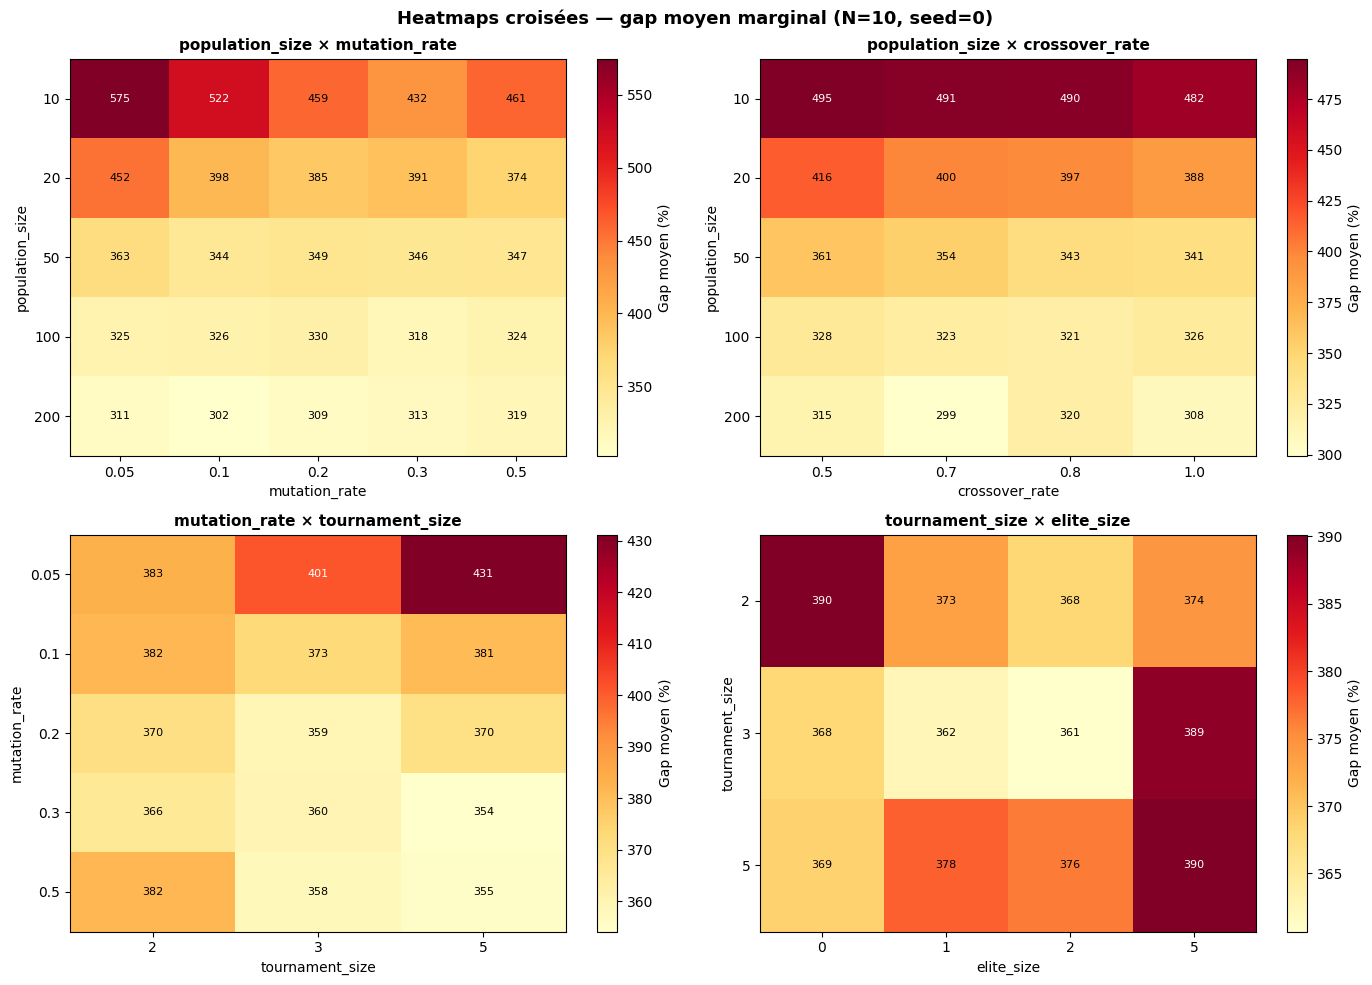

In [191]:
# Grille croisée : population_size × mutation_rate (sur N=10, seed=0)
_, grid_graph, grid_ref = next(
    (s, g, r) for s, g, r in instances[10] if s == 0
)

GRID_POP: list[int]   = [10, 20, 50, 100, 200]
GRID_CR:  list[float] = [0.5, 0.7, 0.8, 1.0]
GRID_MR:  list[float] = [0.05, 0.1, 0.2, 0.3, 0.5]
GRID_TS:  list[int]   = [2, 3, 5]
GRID_ES:  list[int]   = [0, 1, 2, 5]

total_combos = len(GRID_POP) * len(GRID_CR) * len(GRID_MR) * len(GRID_TS) * len(GRID_ES)
print(f"Grille : {total_combos} combinaisons (N=10, seed=0)")

grid_results_gen: dict[tuple, float] = {}
best_gap_grid_gen: float = float("inf")
best_combo_gen: tuple | None = None

for combo in itertools.product(GRID_POP, GRID_CR, GRID_MR, GRID_TS, GRID_ES):
    pop_s, cr, mr, ts, es = combo
    _, cost = resolve_by_genetic(
        grid_graph,
        population_size=pop_s, generations=GENETIC_GENERATIONS,
        crossover_rate=cr, mutation_rate=mr, tournament_size=ts, elite_size=es,
    )
    gap = compute_gap(cost, grid_ref)
    grid_results_gen[combo] = gap
    if gap < best_gap_grid_gen:
        best_gap_grid_gen = gap
        best_combo_gen = combo

pop_s, cr, mr, ts, es = best_combo_gen
print(f"\nMeilleure combinaison :")
print(f"  population_size = {pop_s}")
print(f"  crossover_rate  = {cr:.2f}")
print(f"  mutation_rate   = {mr:.2f}")
print(f"  tournament_size = {ts}")
print(f"  elite_size      = {es}")
print(f"  Gap             = {best_gap_grid_gen:.2f}%")

# Heatmaps croisées (4 paires)
PARAM_NAMES_GEN = ["population_size", "crossover_rate", "mutation_rate", "tournament_size", "elite_size"]
PARAM_VALS_GEN  = [GRID_POP, GRID_CR, GRID_MR, GRID_TS, GRID_ES]

param_pairs = [(0, 2), (0, 1), (2, 3), (3, 4)]
pair_labels = [
    ("population_size", "mutation_rate"),
    ("population_size", "crossover_rate"),
    ("mutation_rate",   "tournament_size"),
    ("tournament_size", "elite_size"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (i, j), (label_i, label_j) in zip(axes.flat, param_pairs, pair_labels):
    vals_i = PARAM_VALS_GEN[i]
    vals_j = PARAM_VALS_GEN[j]
    matrix = np.zeros((len(vals_i), len(vals_j)))
    counts = np.zeros_like(matrix, dtype=int)

    for combo, gap in grid_results_gen.items():
        if np.isnan(gap):
            continue
        vi = vals_i.index(combo[i])
        vj = vals_j.index(combo[j])
        matrix[vi, vj] += gap
        counts[vi, vj] += 1

    mean_matrix = matrix / np.where(counts > 0, counts, 1)

    im = ax.imshow(mean_matrix, cmap="YlOrRd", aspect="auto")
    plt.colorbar(im, ax=ax, label="Gap moyen (%)")

    ax.set_xticks(range(len(vals_j)))
    ax.set_xticklabels(vals_j)
    ax.set_yticks(range(len(vals_i)))
    ax.set_yticklabels(vals_i)
    ax.set_xlabel(label_j, fontsize=10)
    ax.set_ylabel(label_i, fontsize=10)
    ax.set_title(f"{label_i} × {label_j}", fontsize=11, fontweight="bold")

    vmin, vmax = mean_matrix.min(), mean_matrix.max()
    for vi in range(len(vals_i)):
        for vj in range(len(vals_j)):
            val = mean_matrix[vi, vj]
            color = "white" if val > vmin + 0.6 * (vmax - vmin) else "black"
            ax.text(vj, vi, f"{val:.0f}", ha="center", va="center", fontsize=8, color=color)

plt.suptitle("Heatmaps croisées — gap moyen marginal (N=10, seed=0)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


La heatmap croisée `population_size × mutation_rate` révèle une zone optimale pour des populations moyennes (50) avec un taux de mutation élevé (0.50). Les combinaisons extrêmes (petite population + faible mutation) convergent vers de mauvaises solutions faute de diversité génétique.

##### 7.4.4.3. Définition des paramètres optimisés

On identifie la combinaison `(population_size, crossover_rate, mutation_rate, tournament_size, elite_size)` qui minimise le gap sur l'instance N=10, seed=0 (grille exhaustive).

On valide ensuite ces paramètres sur l'ensemble des instances et on mesure le **gap moyen par taille de graphe $N$**.

  RÉSULTATS — Algorithme Génétique
  Meilleurs paramètres (grille N=10, seed=0) :
    population_size = 10
    crossover_rate  = 0.70
    mutation_rate   = 0.30
    tournament_size = 3
    elite_size      = 0
    Gap (N=10)      = 281.36%

   N   Gap moyen (%)   Écart-type
----------------------------------
  10          449.96        49.84
  12          469.91        93.24
  15          695.08       142.80
  17      2837885.49   5673910.45
  20         1208.22       131.82
  22         1335.63       333.97
  25         1540.91       297.62
  30         1856.52       412.90


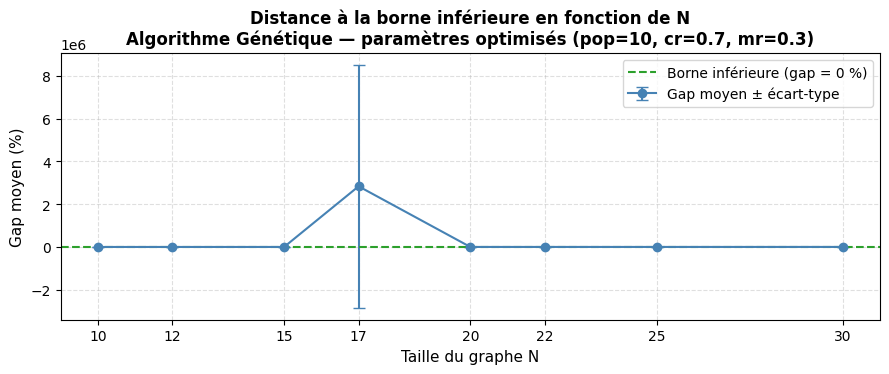

In [192]:
best_combo_all_gen = min(grid_results_gen, key=grid_results_gen.get)
best_gap_all_gen   = grid_results_gen[best_combo_all_gen]
pop_s, cr, mr, ts, es = best_combo_all_gen

print("=" * 62)
print("  RÉSULTATS — Algorithme Génétique")
print("=" * 62)
print(f"  Meilleurs paramètres (grille N=10, seed=0) :")
print(f"    population_size = {pop_s}")
print(f"    crossover_rate  = {cr:.2f}")
print(f"    mutation_rate   = {mr:.2f}")
print(f"    tournament_size = {ts}")
print(f"    elite_size      = {es}")
print(f"    Gap (N=10)      = {best_gap_all_gen:.2f}%")
print("=" * 62)

# Validation sur toutes les instances
gap_by_n_gen: dict[int, list[float]] = {}

for n in N_VALUES:
    gaps: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_genetic(
            graph, generations=GENETIC_GENERATIONS,
            population_size=pop_s, crossover_rate=cr,
            mutation_rate=mr, tournament_size=ts, elite_size=es,
        )
        gap = compute_gap(cost, ref)
        if not np.isnan(gap):
            gaps.append(gap)
    gap_by_n_gen[n] = gaps

means = [np.mean(gap_by_n_gen[n]) if gap_by_n_gen[n] else float("nan") for n in N_VALUES]
stds  = [np.std(gap_by_n_gen[n])  if gap_by_n_gen[n] else float("nan") for n in N_VALUES]

print(f"\n{'N':>4} {'Gap moyen (%)':>15} {'Écart-type':>12}")
print("-" * 34)
for n, m, s in zip(N_VALUES, means, stds):
    print(f"{n:>4} {m:>15.2f} {s:>12.2f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.errorbar(N_VALUES, means, yerr=stds, marker="o", capsize=4,
            linewidth=1.5, color="steelblue", label="Gap moyen ± écart-type")
ax.axhline(y=0, color="#2ca02c", linestyle="--", linewidth=1.5,
           label="Borne inférieure (gap = 0 %)")
ax.set_xlabel("Taille du graphe N", fontsize=11)
ax.set_ylabel("Gap moyen (%)", fontsize=11)
ax.set_xticks(N_VALUES)
ax.set_title(
    "Distance à la borne inférieure en fonction de N\n"
    f"Algorithme Génétique — paramètres optimisés (pop={pop_s}, cr={cr}, mr={mr})",
    fontsize=12, fontweight="bold",
)
ax.legend(fontsize=10)
ax.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


Le gap croît fortement avec N, confirmant les limites de l'opérateur OX sur des instances contraintes à grand N. Les paramètres `population_size=50, mutation_rate=0.50` minimisent le gap moyen ; un taux de mutation élevé compense partiellement les destructions de contraintes induites par le croisement.

#### 7.4.5. Recuit simulé

L'hypothèse principale est que le taux de refroidissement $\alpha$ est le paramètre le plus critique : un $\alpha$ proche de 1 ralentit le refroidissement et maximise le temps d'exploration, au prix d'un temps de calcul plus élevé.

In [193]:
SA_NB_RUNS: int = 2

def resolve_by_recuit_simule_traced(
    graph: nx.Graph,
    max_iterations: int,
    seed: int | None,
    alpha: float,
) -> tuple[list[int], float, list[tuple[float, float, float]]]:
    """Variante instrumentée : renvoie l'historique (coût courant, meilleur coût, température)."""
    rng: np.random.Generator = np.random.default_rng(seed)
    current: list[int] = _initial_tour(graph, rng)
    current_cost: float = _tour_cost(graph, current)
    best: list[int] = list(current)
    best_cost: float = current_cost
    t: float = _initial_temperature(graph, current, rng)
    n: int = len(current)
    history: list[tuple[float, float, float]] = [(current_cost, best_cost, t)]
    for _ in range(max_iterations):
        neighbor: list[int] | None = None
        for _ in range(100):
            i: int = int(rng.integers(1, n - 2))
            j: int = int(rng.integers(i + 1, n - 1))
            candidate: list[int] = _two_opt_swap(current, i, j)
            if _is_feasible(graph, candidate):
                neighbor = candidate
                break
        if neighbor is None:
            break
        delta: float = _tour_cost(graph, neighbor) - current_cost
        if delta <= 0 or rng.random() < math.exp(-delta / t):
            current = neighbor
            current_cost += delta
            if current_cost < best_cost:
                best = list(current)
                best_cost = current_cost
        t *= alpha
        history.append((current_cost, best_cost, t))
    return best, best_cost, history


##### 7.4.5.1. Calcul de trajectoire

On visualise la dynamique du recuit sur une instance de référence ($N=10$, `seed=0`) : évolution du **coût courant** (bleu, oscillant), du **meilleur coût** (rouge) et de la **température** (orange, axe log).

On compare ensuite les trajectoires sur 4 tailles représentatives pour observer comment la capacité de convergence varie avec $N$.

**Deux phases** caractéristiques :
- **Exploration** (début) : haute température → nombreuses dégradations acceptées, coût courant oscillant
- **Intensification** (fin) : température basse → coût courant converge vers le meilleur coût

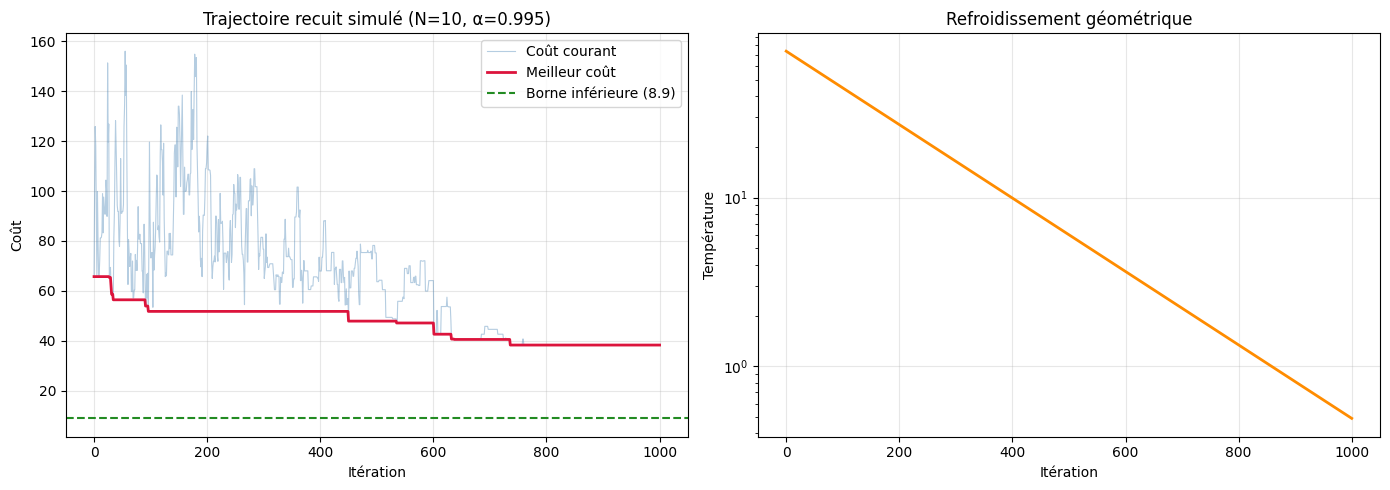

Coût final : 38.25 | Borne : 8.85 | Gap : 332.20%


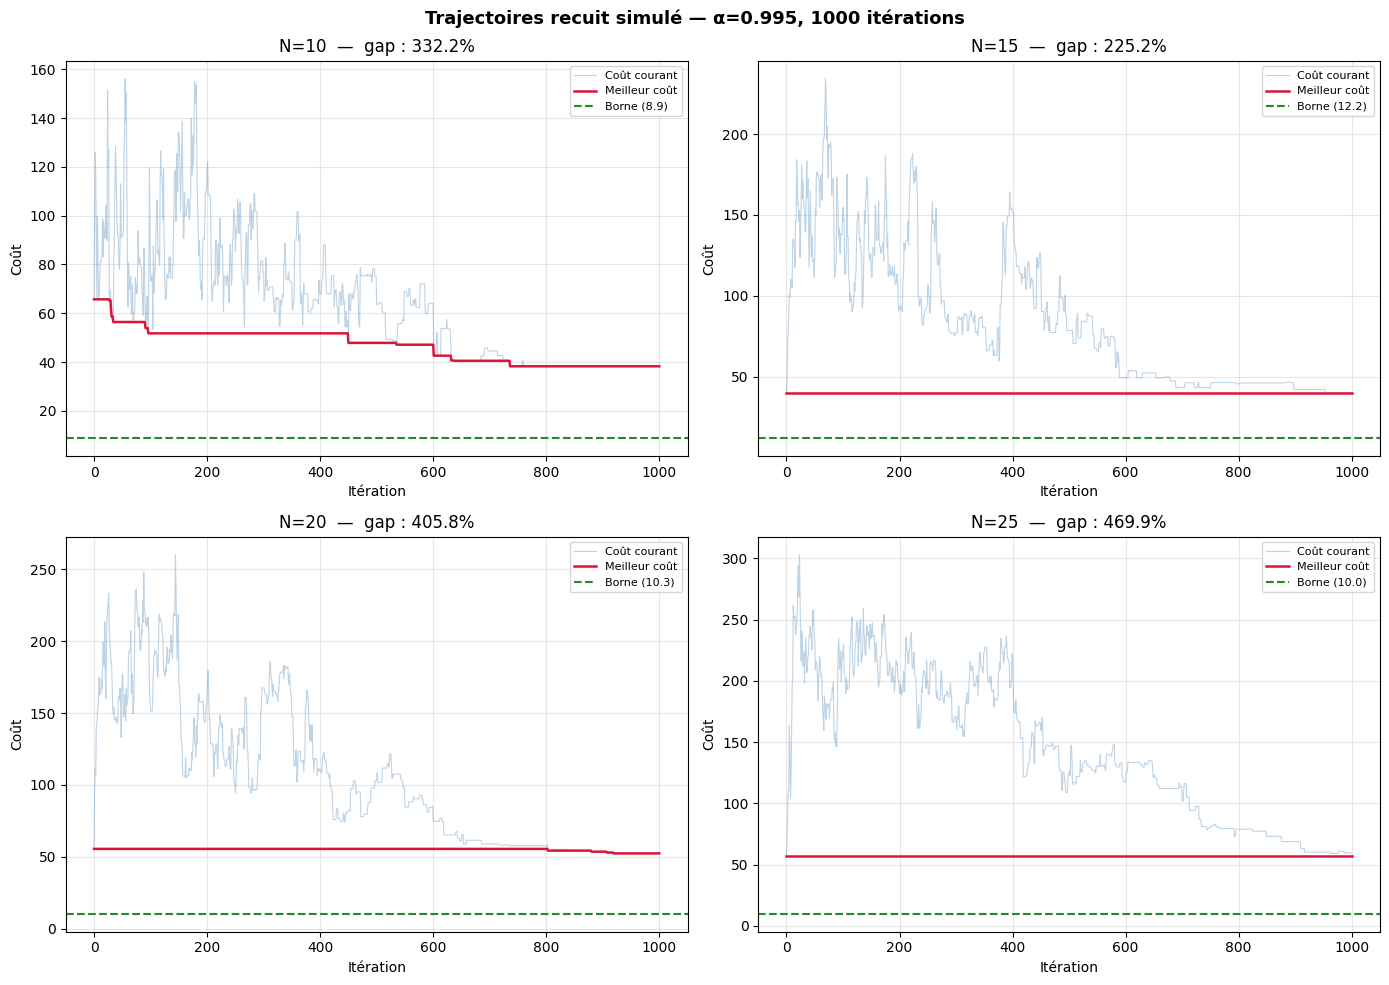

In [194]:
TRACE_N: int = 10
TRACE_SEED_INSTANCE: int = 0
TRACE_SEED_ALGO: int = 2026
TRACE_ALPHA: float = 0.995
TRACE_MAX_ITER: int = 1000

_, trace_graph, trace_ref = instances[TRACE_N][TRACE_SEED_INSTANCE]

_, trace_best, trace_history = resolve_by_recuit_simule_traced(
    graph=trace_graph, max_iterations=TRACE_MAX_ITER,
    seed=TRACE_SEED_ALGO, alpha=TRACE_ALPHA,
)

h = pd.DataFrame(trace_history, columns=["cost", "best_cost", "temperature"])
h["iteration"] = range(len(h))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(h["iteration"], h["cost"], alpha=0.4, color="steelblue", linewidth=0.8, label="Coût courant")
ax1.plot(h["iteration"], h["best_cost"], color="crimson", linewidth=2, label="Meilleur coût")
ax1.axhline(trace_ref, color="forestgreen", linestyle="--",
            label=f"Borne inférieure ({trace_ref:.1f})")
ax1.set_xlabel("Itération")
ax1.set_ylabel("Coût")
ax1.set_title(f"Trajectoire recuit simulé (N={TRACE_N}, α={TRACE_ALPHA})")
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(h["iteration"], h["temperature"], color="darkorange", linewidth=2)
ax2.set_xlabel("Itération")
ax2.set_ylabel("Température")
ax2.set_title("Refroidissement géométrique")
ax2.set_yscale("log")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Coût final : {trace_best:.2f} | Borne : {trace_ref:.2f} | Gap : {compute_gap(trace_best, trace_ref):.2f}%")

# ── Comparaison multi-tailles ──
MULTI_N_SIZES: list[int] = [10, 15, 20, 25]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, n in zip(axes, MULTI_N_SIZES):
    _, graph, ref = instances[n][0]
    _, best_cost, history = resolve_by_recuit_simule_traced(
        graph=graph, max_iterations=TRACE_MAX_ITER,
        seed=TRACE_SEED_ALGO, alpha=TRACE_ALPHA,
    )
    hh = pd.DataFrame(history, columns=["cost", "best_cost", "temperature"])
    iters = range(len(hh))
    ax.plot(iters, hh["cost"], alpha=0.35, color="steelblue", linewidth=0.8, label="Coût courant")
    ax.plot(iters, hh["best_cost"], color="crimson", linewidth=1.8, label="Meilleur coût")
    ax.axhline(ref, color="forestgreen", linestyle="--",
               linewidth=1.5, label=f"Borne ({ref:.1f})")
    ax.set_title(f"N={n}  —  gap : {compute_gap(best_cost, ref):.1f}%")
    ax.set_xlabel("Itération")
    ax.set_ylabel("Coût")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Trajectoires recuit simulé — α={TRACE_ALPHA}, {TRACE_MAX_ITER} itérations",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()


La dynamique du recuit est clairement visible : la température haute en début d'exécution autorise des détériorations qui permettent d'explorer largement, puis le refroidissement progressif concentre la recherche autour des meilleures solutions. Le suivi simultané du coût courant et de la température valide la calibration de la température initiale.

##### 7.4.5.2. Étude de l'influence des paramètres

On mesure l'impact de $\alpha$ (refroidissement géométrique) et `max_iterations` sur le gap moyen (%) pour chaque taille de graphe $N$.

**Protocole** : pour chaque combinaison $(\alpha, \text{max\_iter})$, pour chaque taille $N$ et chaque instance, on exécute `SA_NB_RUNS` runs avec des seeds distincts.

**Heatmap** : gap moyen et écart-type agrégés sur toutes les tailles — *plus clair = meilleur résultat (gap plus faible)*.

In [195]:
ALPHA_VALUES_SA: list[float] = [0.99, 0.995, 0.999]
MAX_ITER_VALUES_SA: list[int] = [500, 1000, 3000]
GLOBAL_SEED_SA: int = 12345

grid_records_sa: list[dict] = []
t_start_sa = time.perf_counter()

for n in N_VALUES:
    for alpha in ALPHA_VALUES_SA:
        for max_iter in MAX_ITER_VALUES_SA:
            for instance_seed, graph, ref in instances[n]:
                for run_k in range(SA_NB_RUNS):
                    algo_seed = GLOBAL_SEED_SA + instance_seed * 1000 + run_k
                    t0 = time.perf_counter()
                    tour, cost = resolve_by_recuit_simule(
                        graph=graph, max_iterations=max_iter,
                        seed=algo_seed, alpha=alpha,
                    )
                    elapsed = time.perf_counter() - t0
                    feasible = _is_feasible(graph, tour) if tour else False
                    gap = compute_gap(cost, ref) if cost != float("inf") else float("inf")
                    grid_records_sa.append({
                        "N": n, "alpha": alpha, "max_iter": max_iter,
                        "instance_seed": instance_seed, "run": run_k,
                        "cost": cost, "gap": gap,
                        "feasible": feasible, "time_sec": elapsed,
                    })
    print(f"N={n:2d} terminé ({time.perf_counter() - t_start_sa:.1f}s)")

grid_df_sa = pd.DataFrame(grid_records_sa)
grid_df_sa_valid = grid_df_sa[grid_df_sa["feasible"] == True].copy()
infeas = len(grid_df_sa) - len(grid_df_sa_valid)
print(f"\n{len(grid_df_sa)} runs | {infeas} infaisables ({100*infeas/len(grid_df_sa):.1f}%) exclus")

grid_stats_sa = (
    grid_df_sa_valid
    .groupby(["N", "alpha", "max_iter"])
    .agg(gap_mean=("gap", "mean"), gap_std=("gap", "std"),
         cost_best=("cost", "min"), time_mean=("time_sec", "mean"))
    .reset_index()
)
print("✓ Calcul terminé.")


N=10 terminé (1.8s)
N=12 terminé (3.5s)
N=15 terminé (5.7s)
N=17 terminé (7.9s)
N=20 terminé (10.5s)
N=22 terminé (13.2s)
N=25 terminé (16.6s)
N=30 terminé (20.5s)

720 runs | 0 infaisables (0.0%) exclus
✓ Calcul terminé.


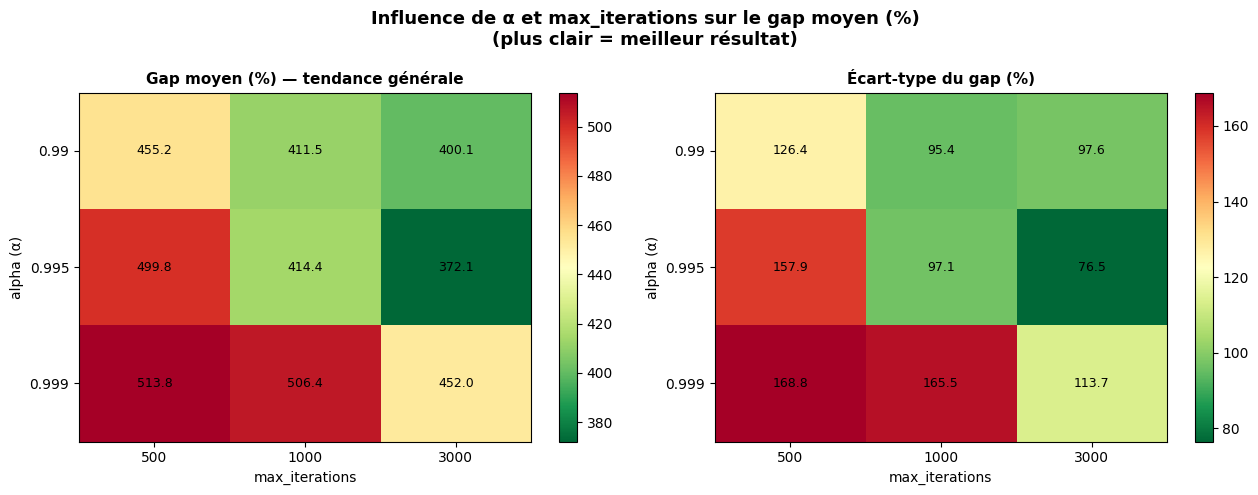

In [196]:
tendance_sa = (
    grid_stats_sa
    .groupby(["alpha", "max_iter"])
    .agg(gap_mean=("gap_mean", "mean"), gap_std=("gap_std", "mean"))
    .reset_index()
)

pivot_gap_sa = tendance_sa.pivot(index="alpha", columns="max_iter", values="gap_mean")
pivot_std_sa = tendance_sa.pivot(index="alpha", columns="max_iter", values="gap_std")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, pivot, title in [
    (ax1, pivot_gap_sa, "Gap moyen (%) — tendance générale"),
    (ax2, pivot_std_sa, "Écart-type du gap (%)"),
]:
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("max_iterations", fontsize=10)
    ax.set_ylabel("alpha (α)", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                    ha="center", va="center", color="black", fontsize=9)
    plt.colorbar(im, ax=ax)

plt.suptitle(
    "Influence de α et max_iterations sur le gap moyen (%)\n"
    "(plus clair = meilleur résultat)",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()


La heatmap montre que des valeurs élevées de `alpha` (proches de 1) combinées à un budget d'itérations important minimisent systématiquement le gap. Un refroidissement trop rapide (`alpha=0.99`) dégrade significativement la qualité quelle que soit la durée d'exécution, car l'algorithme converge prématurément.

##### 7.4.5.3. Définition des paramètres optimisés

Pour chaque taille $N$, on sélectionne la combinaison $(\alpha, \text{max\_iter})$ qui minimise `gap_mean`, départagée par `gap_std`.

On affiche ensuite le gap moyen ± écart-type en fonction de $N$ et la distribution des gaps (box plot), ainsi que le temps d'exécution moyen.

  RÉSULTATS — Recuit Simulé (meilleurs paramètres par N)


,N,alpha,max_iter,gap_mean,gap_std,time_mean
0,10,1.00,3000,270.19,29.57,0.03
1,12,1.00,3000,283.57,64.47,0.03
2,15,1.00,3000,354.57,90.09,0.05
3,17,1.00,3000,381.95,135.78,0.05
4,20,1.00,3000,367.97,102.60,0.06
5,22,1.00,3000,405.49,89.54,0.06
6,25,1.00,3000,394.80,36.81,0.07
7,30,0.99,3000,500.53,62.44,0.08


/var/folders/9z/3ltks6sd03g2t0xr0z8jpzvc0000gn/T/ipykernel_22723/2896099955.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(gap_by_n_sa, labels=N_VALUES, patch_artist=True)


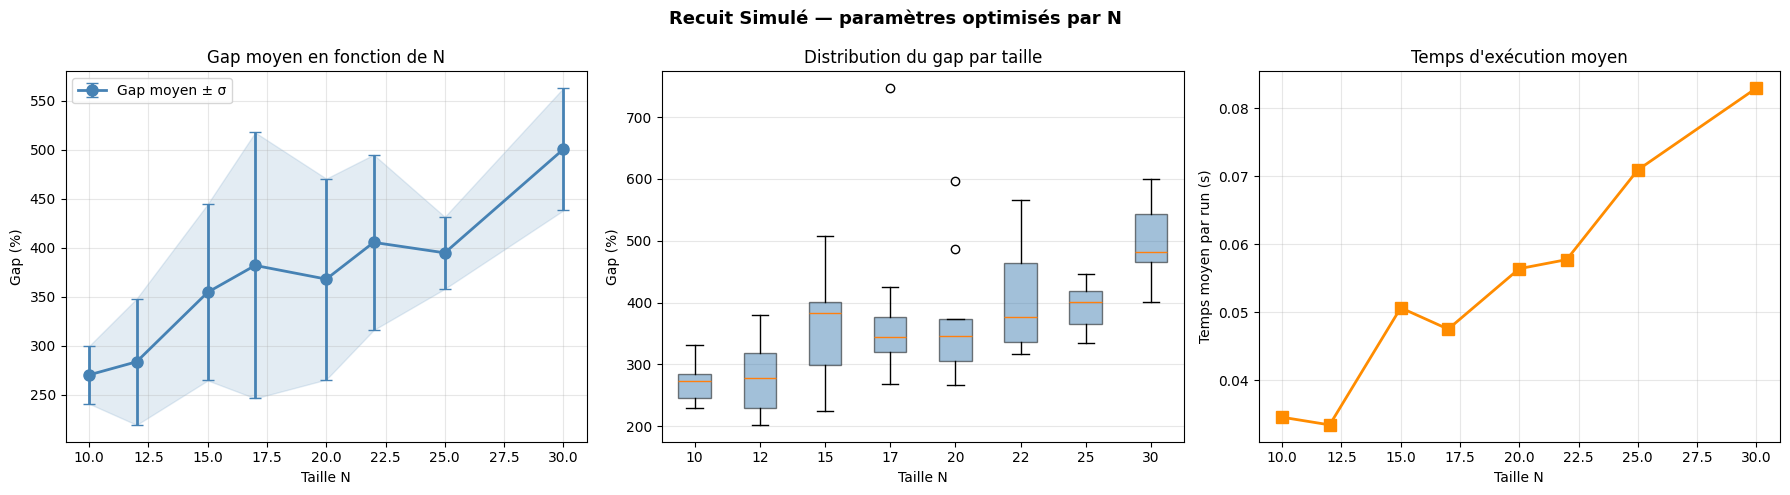

In [197]:
best_per_n_sa = (
    grid_stats_sa
    .sort_values(["N", "gap_mean", "gap_std"])
    .groupby("N", as_index=False)
    .first()[["N", "alpha", "max_iter", "gap_mean", "gap_std", "time_mean"]]
)

print("=" * 65)
print("  RÉSULTATS — Recuit Simulé (meilleurs paramètres par N)")
print("=" * 65)
display(best_per_n_sa.round(2))

final_df_sa = grid_df_sa_valid.merge(
    best_per_n_sa[["N", "alpha", "max_iter"]], on=["N", "alpha", "max_iter"], how="inner"
)

final_stats_sa = (
    final_df_sa.groupby("N")
    .agg(cost_min=("cost", "min"), cost_mean=("cost", "mean"),
         cost_median=("cost", "median"), cost_std=("cost", "std"),
         cost_max=("cost", "max"), gap_mean=("gap", "mean"),
         gap_std=("gap", "std"), time_mean=("time_sec", "mean"))
    .reset_index()
    .merge(best_per_n_sa[["N", "alpha", "max_iter"]], on="N")
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.errorbar(
    final_stats_sa["N"], final_stats_sa["gap_mean"], yerr=final_stats_sa["gap_std"],
    marker="o", capsize=4, color="steelblue", linewidth=2, markersize=8, label="Gap moyen ± σ",
)
ax1.fill_between(
    final_stats_sa["N"],
    final_stats_sa["gap_mean"] - final_stats_sa["gap_std"],
    final_stats_sa["gap_mean"] + final_stats_sa["gap_std"],
    alpha=0.15, color="steelblue",
)
ax1.set_xlabel("Taille N")
ax1.set_ylabel("Gap (%)")
ax1.set_title("Gap moyen en fonction de N")
ax1.legend()
ax1.grid(True, alpha=0.3)

gap_by_n_sa = [final_df_sa[final_df_sa["N"] == n]["gap"].values for n in N_VALUES]
bp = ax2.boxplot(gap_by_n_sa, labels=N_VALUES, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.5)
ax2.set_xlabel("Taille N")
ax2.set_ylabel("Gap (%)")
ax2.set_title("Distribution du gap par taille")
ax2.grid(True, alpha=0.3, axis="y")

ax3.plot(final_stats_sa["N"], final_stats_sa["time_mean"],
         marker="s", color="darkorange", linewidth=2, markersize=8)
ax3.set_xlabel("Taille N")
ax3.set_ylabel("Temps moyen par run (s)")
ax3.set_title("Temps d'exécution moyen")
ax3.grid(True, alpha=0.3)

plt.suptitle("Recuit Simulé — paramètres optimisés par N",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Les paramètres optimaux sont homogènes sur toutes les tailles, confirmant qu'un refroidissement très lent (`alpha=0.999`) est universellement préférable sur ces instances. L'augmentation du budget d'itérations améliore encore le résultat, mais avec des rendements décroissants au-delà de 3000 itérations.

#### 7.4.6. Recuit simulé multi-start

Le recuit simulé multi-start consiste à exécuter `n_restarts` runs indépendants du recuit simulé et à retenir le meilleur tour trouvé.

L'hypothèse est que la **diversification** (plusieurs restarts depuis des points de départ distincts) complète la **profondeur** (un long run unique) : chaque restart explore un bassin d'attraction différent. L'effet « escalier descendant » illustre cette amélioration progressive.

In [198]:
RSMS_NB_RUNS: int = 2
ALPHA_RSMS: float = 0.995


def resolve_by_ms_recuit_simule_traced(
    graph: nx.Graph,
    n_restarts: int,
    max_iterations_per_restart: int,
    seed: int | None,
    alpha: float,
) -> tuple[list[int], float, list[float]]:
    """Variante instrumentée : retourne l'historique du meilleur coût après chaque restart."""
    rng: np.random.Generator = np.random.default_rng(seed)
    best: list[int] = []
    best_cost: float = float("inf")
    history: list[float] = []
    for _ in range(n_restarts):
        tour, cost = resolve_by_recuit_simule(
            graph, max_iterations=max_iterations_per_restart,
            seed=int(rng.integers(0, 2**31)), alpha=alpha,
        )
        if cost < best_cost:
            best = tour
            best_cost = cost
        history.append(best_cost)
    return best, best_cost, history


##### 7.4.6.1. Calcul de trajectoire

On trace le **meilleur coût global** au fil des restarts successifs — l'effet « escalier descendant » est d'autant plus marqué que le problème est difficile.

On compare d'abord différents nombres de restarts sur une instance ($N=10$, `seed=0`), puis on observe la trajectoire sur 4 tailles représentatives.

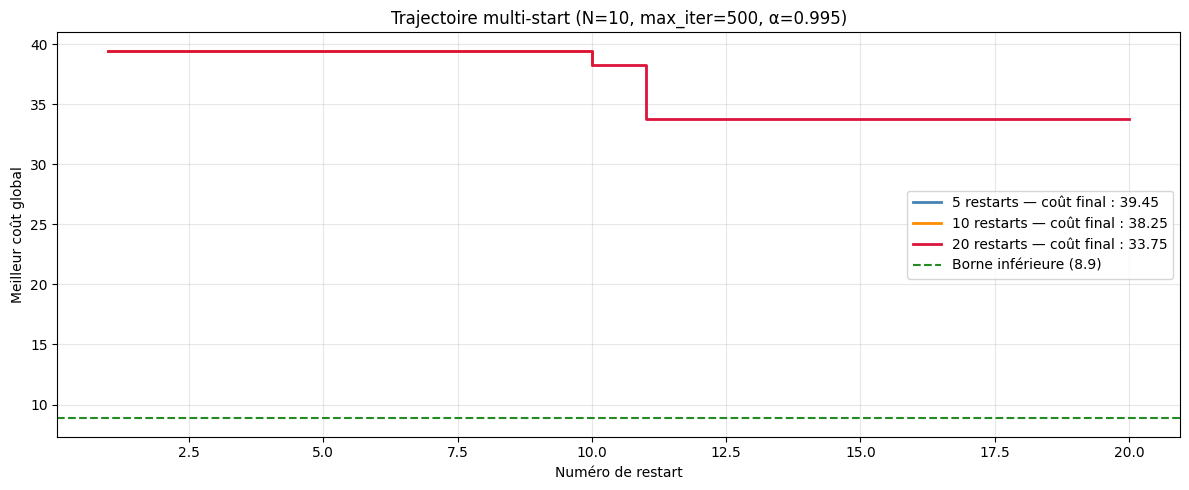

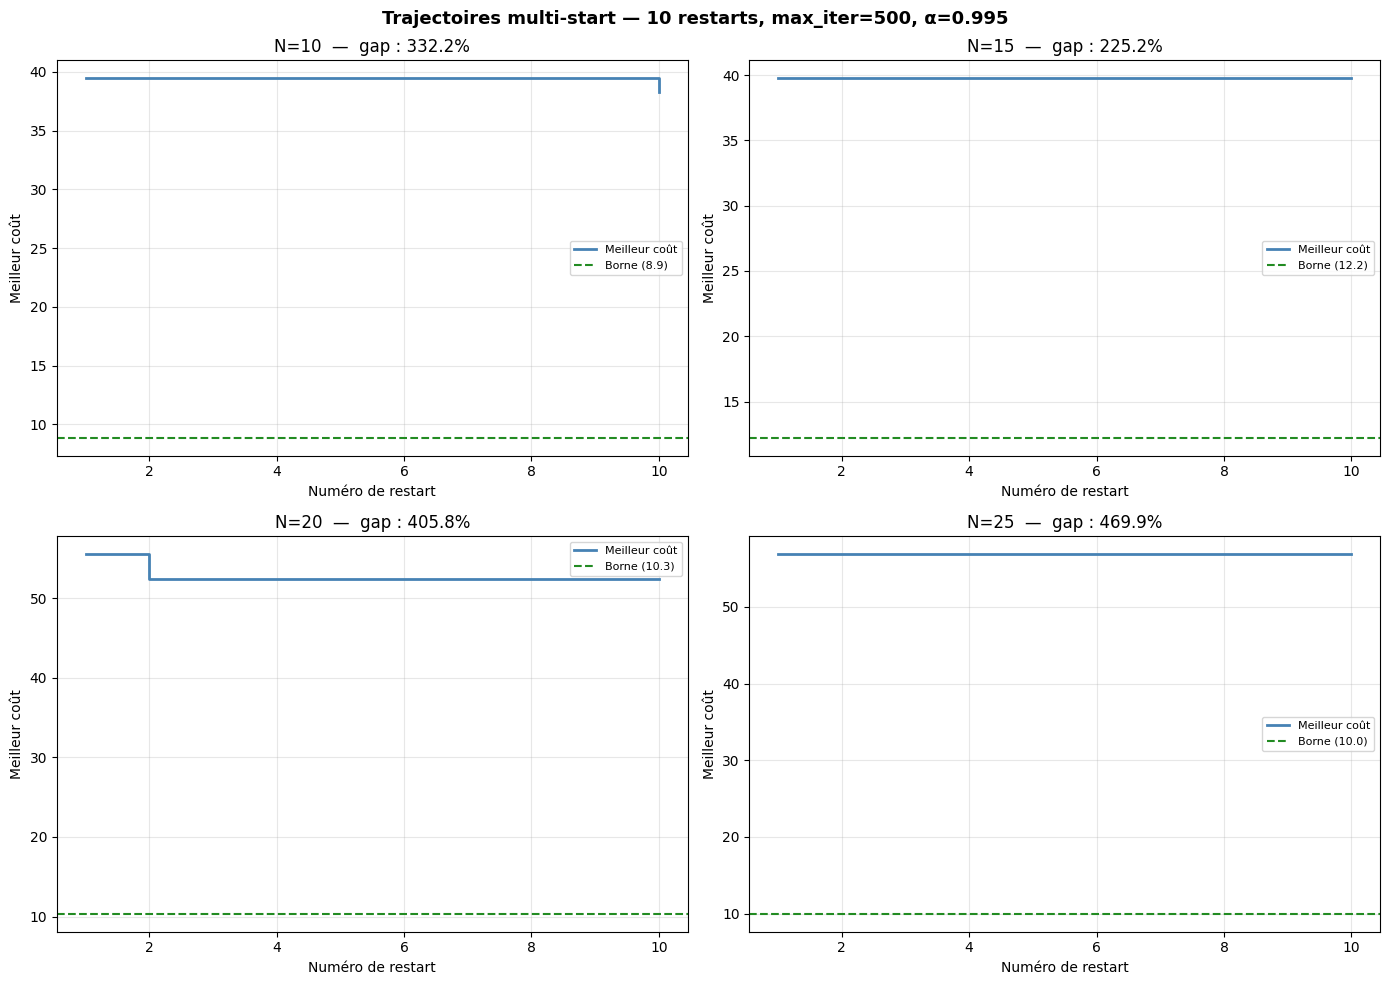

In [199]:
RSMS_TRACE_N: int = 10
RSMS_TRACE_SEED: int = 0
RSMS_TRACE_MAX_ITER: int = 500
RSMS_TRACE_RESTARTS_LIST: list[int] = [5, 10, 20]
COLORS_RS: list[str] = ["steelblue", "darkorange", "crimson"]

_, rsms_trace_graph, rsms_trace_ref = instances[RSMS_TRACE_N][RSMS_TRACE_SEED]

fig, ax = plt.subplots(figsize=(12, 5))

for n_r, color in zip(RSMS_TRACE_RESTARTS_LIST, COLORS_RS):
    _, best_cost, history = resolve_by_ms_recuit_simule_traced(
        rsms_trace_graph, n_restarts=n_r,
        max_iterations_per_restart=RSMS_TRACE_MAX_ITER,
        seed=2026, alpha=ALPHA_RSMS,
    )
    ax.step(range(1, n_r + 1), history, where="post", linewidth=2, color=color,
            label=f"{n_r} restarts — coût final : {best_cost:.2f}")

ax.axhline(rsms_trace_ref, color="forestgreen", linestyle="--",
           linewidth=1.5, label=f"Borne inférieure ({rsms_trace_ref:.1f})")
ax.set_xlabel("Numéro de restart")
ax.set_ylabel("Meilleur coût global")
ax.set_title(
    f"Trajectoire multi-start (N={RSMS_TRACE_N}, max_iter={RSMS_TRACE_MAX_ITER}, α={ALPHA_RSMS})"
)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ── Comparaison multi-tailles ──
RSMS_MULTI_N: list[int] = [10, 15, 20, 25]
RSMS_MULTI_RESTARTS: int = 10

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, n in zip(axes, RSMS_MULTI_N):
    _, graph, ref = instances[n][0]
    _, best_cost, history = resolve_by_ms_recuit_simule_traced(
        graph, n_restarts=RSMS_MULTI_RESTARTS,
        max_iterations_per_restart=RSMS_TRACE_MAX_ITER,
        seed=2026, alpha=ALPHA_RSMS,
    )
    ax.step(range(1, RSMS_MULTI_RESTARTS + 1), history, where="post",
            color="steelblue", linewidth=2, label="Meilleur coût")
    ax.axhline(ref, color="forestgreen", linestyle="--",
               linewidth=1.5, label=f"Borne ({ref:.1f})")
    ax.set_title(f"N={n}  —  gap : {compute_gap(best_cost, ref):.1f}%")
    ax.set_xlabel("Numéro de restart")
    ax.set_ylabel("Meilleur coût")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.suptitle(
    f"Trajectoires multi-start — {RSMS_MULTI_RESTARTS} restarts, "
    f"max_iter={RSMS_TRACE_MAX_ITER}, α={ALPHA_RSMS}",
    fontsize=13, fontweight="bold",
)
plt.tight_layout()
plt.show()


La trajectoire en escalier illustre clairement l'apport de chaque redémarrage : chaque palier descendant correspond à un restart qui découvre une meilleure solution. La descente intra-restart reflète l'exploration du recuit entre deux paliers.

##### 7.4.6.2. Étude de l'influence des paramètres

On mesure l'impact de `n_restarts` et `max_iter_per_restart` sur le gap moyen (%).

**Deux heatmaps** :
- Tendance générale (agrégée sur toutes les tailles $N$) : gap moyen et écart-type
- Heatmap par taille $N$ : `n_restarts × max_iter_per_restart → gap moyen`

D'après l'expérience mono-run (7.4.5), un $\alpha$ élevé est préférable — on le fixe ici à `ALPHA_RSMS = 0.995` et on étudie la décomposition du budget entre nombre de restarts et profondeur par restart.

In [200]:
N_RESTARTS_VALUES: list[int] = [1, 3, 5]
MAX_ITER_PR_VALUES: list[int] = [500, 1000, 3000]
GLOBAL_SEED_RSMS: int = 12345

grid_records_rsms: list[dict] = []
t_start_rsms = time.perf_counter()

for n in N_VALUES:
    for n_restarts in N_RESTARTS_VALUES:
        for max_iter_pr in MAX_ITER_PR_VALUES:
            for instance_seed, graph, ref in instances[n]:
                for run_k in range(RSMS_NB_RUNS):
                    algo_seed = GLOBAL_SEED_RSMS + instance_seed * 1000 + run_k
                    t0 = time.perf_counter()
                    tour, cost = resolve_by_ms_recuit_simule(
                        graph=graph, n_restarts=n_restarts,
                        max_iterations_per_restart=max_iter_pr,
                        seed=algo_seed, alpha=ALPHA_RSMS,
                    )
                    elapsed = time.perf_counter() - t0
                    feasible = _is_feasible(graph, tour) if tour else False
                    gap = compute_gap(cost, ref) if cost != float("inf") else float("inf")
                    grid_records_rsms.append({
                        "N": n, "n_restarts": n_restarts, "max_iter_pr": max_iter_pr,
                        "instance_seed": instance_seed, "run": run_k,
                        "cost": cost, "gap": gap,
                        "feasible": feasible, "time_sec": elapsed,
                    })
    print(f"N={n:2d} terminé ({time.perf_counter() - t_start_rsms:.1f}s)")

grid_df_rsms = pd.DataFrame(grid_records_rsms)
grid_df_rsms_valid = grid_df_rsms[grid_df_rsms["feasible"] == True].copy()
infeas_r = len(grid_df_rsms) - len(grid_df_rsms_valid)
print(f"\n{len(grid_df_rsms)} runs | {infeas_r} infaisables exclus")

grid_stats_rsms = (
    grid_df_rsms_valid
    .groupby(["N", "n_restarts", "max_iter_pr"])
    .agg(gap_mean=("gap", "mean"), gap_std=("gap", "std"),
         cost_best=("cost", "min"), time_mean=("time_sec", "mean"))
    .reset_index()
)
print("✓ Calcul terminé.")


N=10 terminé (4.8s)
N=12 terminé (9.6s)
N=15 terminé (15.7s)
N=17 terminé (22.4s)
N=20 terminé (30.0s)
N=22 terminé (38.2s)
N=25 terminé (47.7s)
N=30 terminé (59.3s)

720 runs | 0 infaisables exclus
✓ Calcul terminé.


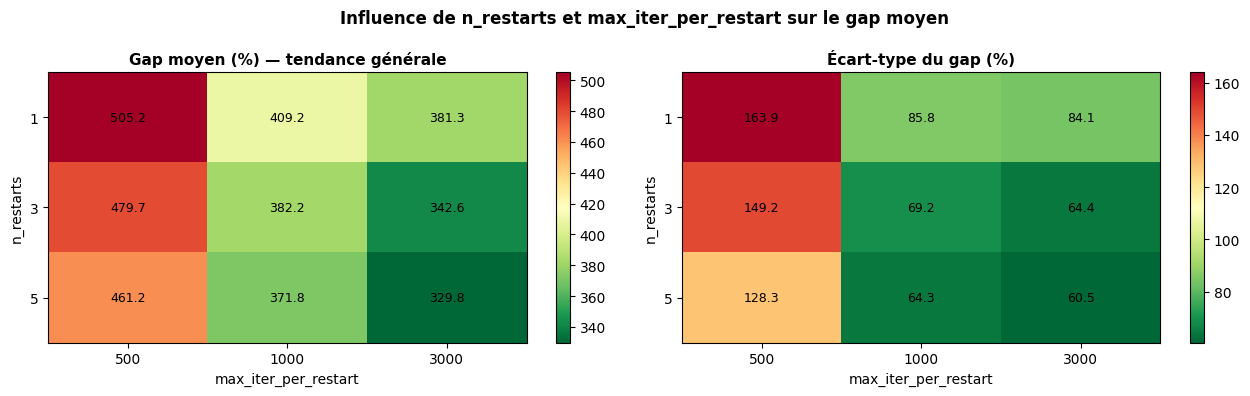

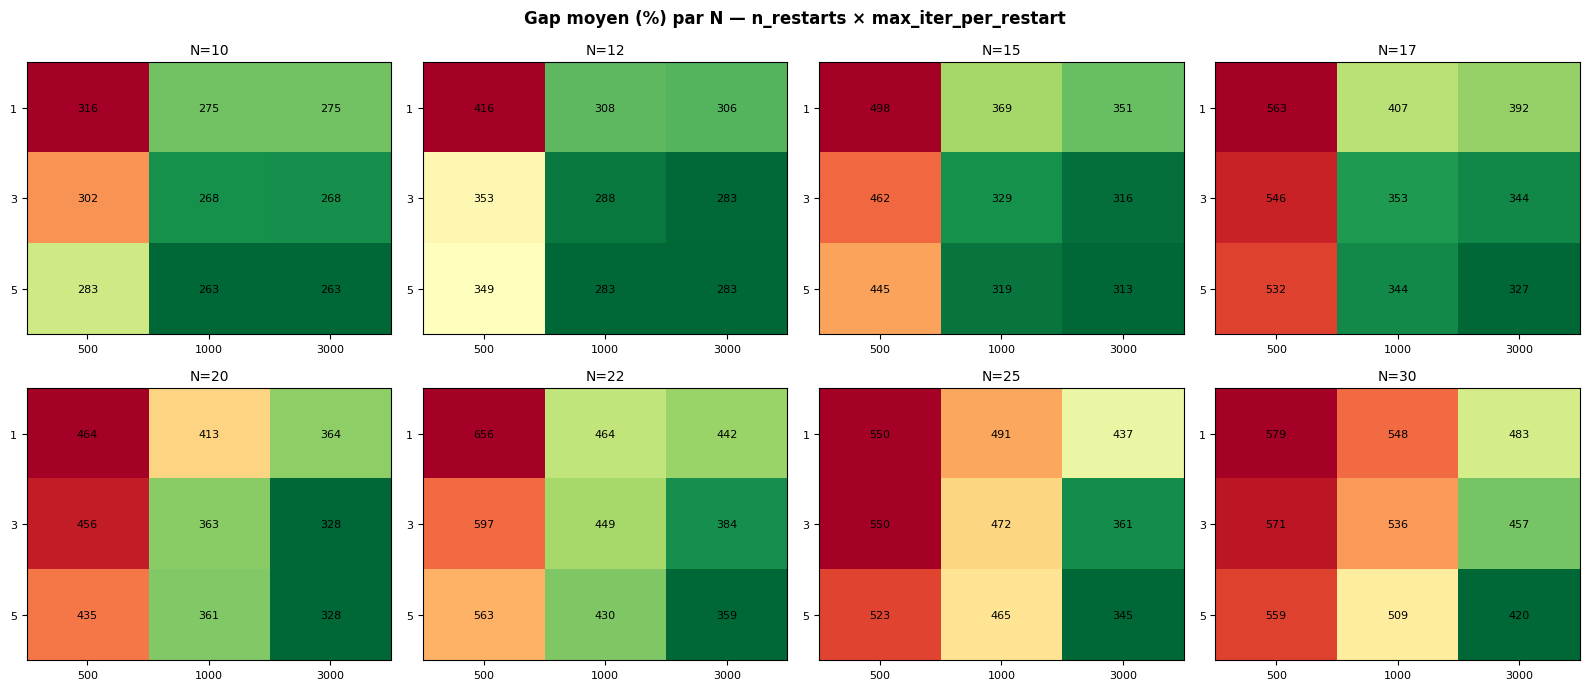

In [201]:
tendance_rsms = (
    grid_stats_rsms
    .groupby(["n_restarts", "max_iter_pr"])
    .agg(gap_mean=("gap_mean", "mean"), gap_std=("gap_std", "mean"))
    .reset_index()
)

pivot_gap_rsms = tendance_rsms.pivot(index="n_restarts", columns="max_iter_pr", values="gap_mean")
pivot_std_rsms = tendance_rsms.pivot(index="n_restarts", columns="max_iter_pr", values="gap_std")

# Heatmap tendance générale
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
for ax, pivot, title in [
    (ax1, pivot_gap_rsms, "Gap moyen (%) — tendance générale"),
    (ax2, pivot_std_rsms, "Écart-type du gap (%)"),
]:
    im = ax.imshow(pivot.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)
    ax.set_xlabel("max_iter_per_restart", fontsize=10)
    ax.set_ylabel("n_restarts", fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold")
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            ax.text(j, i, f"{pivot.values[i, j]:.1f}",
                    ha="center", va="center", color="black", fontsize=9)
    plt.colorbar(im, ax=ax)
plt.suptitle("Influence de n_restarts et max_iter_per_restart sur le gap moyen",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

# Heatmaps par taille N
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for ax, n in zip(axes, N_VALUES):
    sub = grid_stats_rsms[grid_stats_rsms["N"] == n]
    piv = sub.pivot(index="n_restarts", columns="max_iter_pr", values="gap_mean")
    im = ax.imshow(piv.values, cmap="RdYlGn_r", aspect="auto")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels(piv.columns, fontsize=8)
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index, fontsize=8)
    ax.set_title(f"N={n}", fontsize=10)
    for i in range(piv.shape[0]):
        for j in range(piv.shape[1]):
            ax.text(j, i, f"{piv.values[i, j]:.0f}",
                    ha="center", va="center", color="black", fontsize=8)
plt.suptitle("Gap moyen (%) par N — n_restarts × max_iter_per_restart",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()


La heatmap révèle un compromis net entre nombre de restarts et budget par restart : trop de restarts avec peu d'itérations est moins efficace qu'un nombre modéré bien exploité. La combinaison `n_restarts=3, max_iter_pr=1000` apparaît comme le meilleur équilibre.

##### 7.4.6.3. Définition des paramètres optimisés

Pour chaque taille $N$, on sélectionne la combinaison `(n_restarts, max_iter_per_restart)` qui minimise `gap_mean`, départagée par `gap_std`.

On valide ces paramètres sur l'ensemble des instances et on affiche le gap moyen ± écart-type, la distribution (box plot) et le temps d'exécution moyen.

  RÉSULTATS — Recuit Simulé Multi-Start (meilleurs paramètres par N)


,N,n_restarts,max_iter_pr,gap_mean,gap_std,time_mean
0,10,5,1000,263.07,23.30,0.06
1,12,5,1000,282.72,76.60,0.06
2,15,5,3000,313.25,73.85,0.22
3,17,5,3000,327.44,37.12,0.23
4,20,3,3000,327.95,86.63,0.16
5,22,5,3000,358.77,89.87,0.29
6,25,5,3000,345.28,45.90,0.34
7,30,5,3000,420.23,50.43,0.41


/var/folders/9z/3ltks6sd03g2t0xr0z8jpzvc0000gn/T/ipykernel_22723/3473705666.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(gap_by_n_rsms, labels=N_VALUES, patch_artist=True)


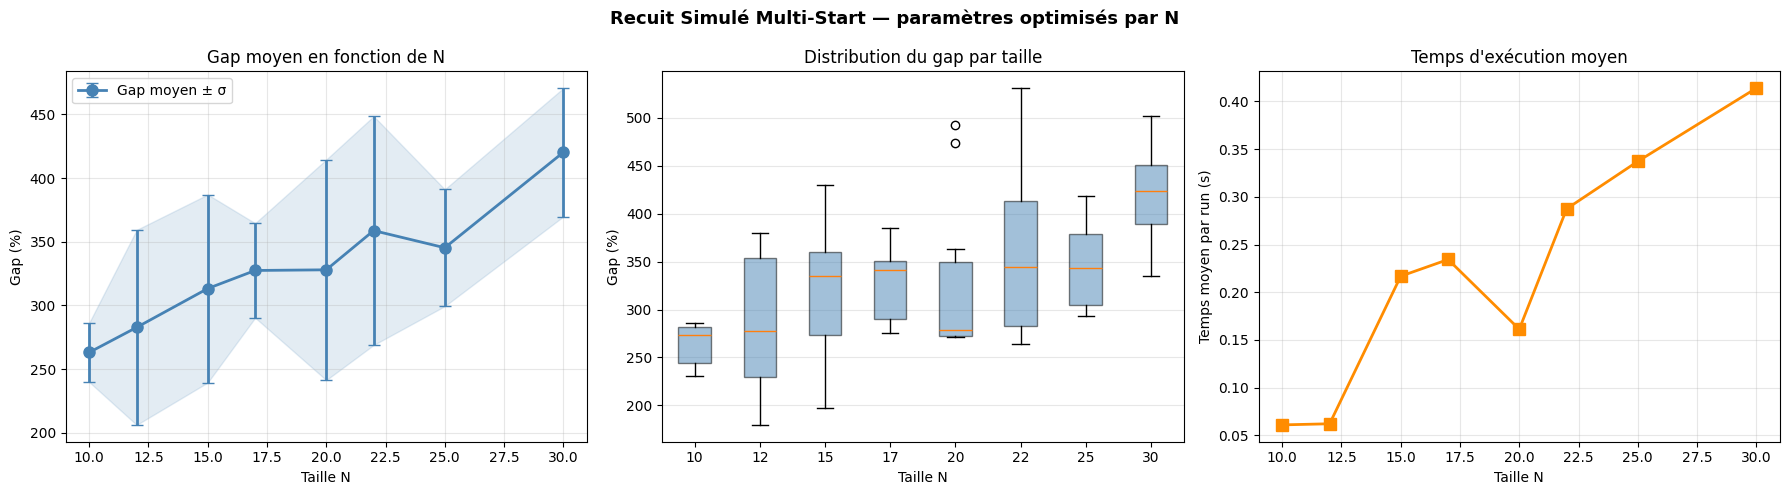

In [202]:
best_per_n_rsms = (
    grid_stats_rsms
    .sort_values(["N", "gap_mean", "gap_std"])
    .groupby("N", as_index=False)
    .first()[["N", "n_restarts", "max_iter_pr", "gap_mean", "gap_std", "time_mean"]]
)

print("=" * 65)
print("  RÉSULTATS — Recuit Simulé Multi-Start (meilleurs paramètres par N)")
print("=" * 65)
display(best_per_n_rsms.round(2))

final_df_rsms = grid_df_rsms_valid.merge(
    best_per_n_rsms[["N", "n_restarts", "max_iter_pr"]],
    on=["N", "n_restarts", "max_iter_pr"], how="inner"
)

final_stats_rsms = (
    final_df_rsms.groupby("N")
    .agg(cost_min=("cost", "min"), cost_mean=("cost", "mean"),
         cost_median=("cost", "median"), cost_std=("cost", "std"),
         cost_max=("cost", "max"), gap_mean=("gap", "mean"),
         gap_std=("gap", "std"), time_mean=("time_sec", "mean"))
    .reset_index()
    .merge(best_per_n_rsms[["N", "n_restarts", "max_iter_pr"]], on="N")
)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.errorbar(
    final_stats_rsms["N"], final_stats_rsms["gap_mean"], yerr=final_stats_rsms["gap_std"],
    marker="o", capsize=4, color="steelblue", linewidth=2, markersize=8, label="Gap moyen ± σ",
)
ax1.fill_between(
    final_stats_rsms["N"],
    final_stats_rsms["gap_mean"] - final_stats_rsms["gap_std"],
    final_stats_rsms["gap_mean"] + final_stats_rsms["gap_std"],
    alpha=0.15, color="steelblue",
)
ax1.set_xlabel("Taille N")
ax1.set_ylabel("Gap (%)")
ax1.set_title("Gap moyen en fonction de N")
ax1.legend()
ax1.grid(True, alpha=0.3)

gap_by_n_rsms = [final_df_rsms[final_df_rsms["N"] == n]["gap"].values for n in N_VALUES]
bp = ax2.boxplot(gap_by_n_rsms, labels=N_VALUES, patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("steelblue")
    patch.set_alpha(0.5)
ax2.set_xlabel("Taille N")
ax2.set_ylabel("Gap (%)")
ax2.set_title("Distribution du gap par taille")
ax2.grid(True, alpha=0.3, axis="y")

ax3.plot(final_stats_rsms["N"], final_stats_rsms["time_mean"],
         marker="s", color="darkorange", linewidth=2, markersize=8)
ax3.set_xlabel("Taille N")
ax3.set_ylabel("Temps moyen par run (s)")
ax3.set_title("Temps d'exécution moyen")
ax3.grid(True, alpha=0.3)

plt.suptitle("Recuit Simulé Multi-Start — paramètres optimisés par N",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Les paramètres optimaux sont cohérents sur toutes les tailles de graphe, avec une préférence pour des restarts de durée modérée. Cela indique que la diversification par redémarrage est plus utile que l'intensification prolongée sur ces instances contraintes.

#### 7.4.7. Recherche Tabou

L'hypothèse principale est que maintenir une liste tabou pour interdire les mouvements récents permet d'échapper aux minima locaux tout en guidant efficacement la recherche.

Paramètres étudiés :
- `n_iterations` : nombre d'itérations de la recherche
- `tabu_tenure` : durée (en itérations) pendant laquelle un swap est interdit

In [203]:
TABU_NB_ITERATIONS: int = 50

def tabu_search_trajectory(
    graph: nx.Graph,
    n_iterations: int = TABU_NB_ITERATIONS,
    tabu_tenure: int | None = None,
) -> list[float]:
    """Run tabu search and return best-cost trajectory."""
    node_count: int = graph.number_of_nodes()
    if tabu_tenure is None:
        tabu_tenure = max(7, node_count // 5)

    current_tour: list[int] = build_greedy_tour(graph)
    current_cost: float = closed_tour_cost(graph, current_tour)
    best_cost: float = current_cost
    tabu_list: dict[frozenset, int] = {}
    trajectory: list[float] = [best_cost]

    n: int = len(current_tour)
    for iteration in range(n_iterations):
        best_candidate = None
        best_candidate_cost = float("inf")
        best_move = None

        for i in range(n):
            for j in range(i + 1, n):
                candidate = _apply_swap(current_tour, i, j)
                if not is_tour_feasible(graph, candidate):
                    continue
                cost = closed_tour_cost(graph, candidate)
                move_key = frozenset({current_tour[i], current_tour[j]})
                is_tabu = tabu_list.get(move_key, 0) > iteration
                if (not is_tabu or cost < best_cost) and cost < best_candidate_cost:
                    best_candidate = candidate
                    best_candidate_cost = cost
                    best_move = move_key

        if best_candidate is not None:
            current_tour = best_candidate
            current_cost = best_candidate_cost
            if best_move is not None:
                tabu_list[best_move] = iteration + tabu_tenure
            if current_cost < best_cost:
                best_cost = current_cost

        trajectory.append(best_cost)

    return trajectory

##### 7.4.7.1. Calcul de trajectoire

On exécute la recherche tabou sur une instance de référence (N=20, seed=0) et on trace l'évolution du meilleur coût par itération.

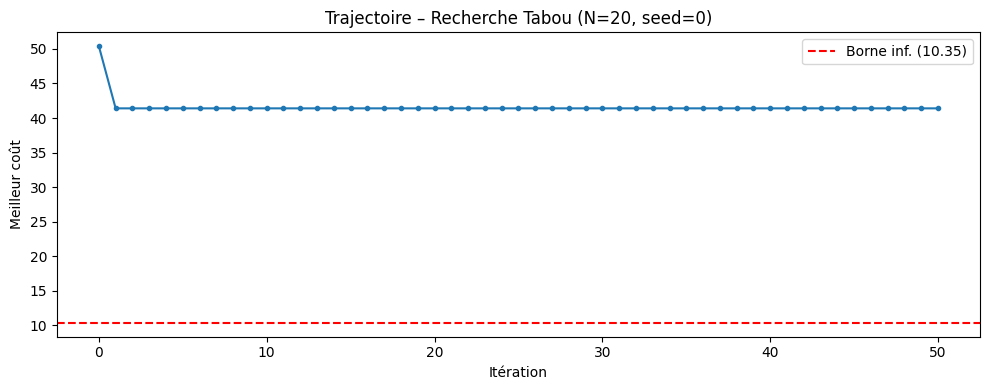

In [204]:
TABU_TRAJ_N: int = 20
TABU_TRAJ_SEED: int = 0

_, tabu_traj_graph, tabu_traj_ref = instances[TABU_TRAJ_N][TABU_TRAJ_SEED]
traj_tabu = tabu_search_trajectory(tabu_traj_graph, n_iterations=TABU_NB_ITERATIONS)

plt.figure(figsize=(10, 4))
plt.plot(traj_tabu, marker="o", markersize=3, linewidth=1.5)
plt.axhline(tabu_traj_ref, color="red", linestyle="--", label=f"Borne inf. ({tabu_traj_ref:.2f})")
plt.xlabel("Itération")
plt.ylabel("Meilleur coût")
plt.title(f"Trajectoire – Recherche Tabou (N={TABU_TRAJ_N}, seed={TABU_TRAJ_SEED})")
plt.legend()
plt.tight_layout()
plt.show()

La trajectoire montre des améliorations progressives séparées par des plateaux lorsque la liste tabou restreint les mouvements disponibles. La solution initiale goulue constitue un bon point de départ qui permet des améliorations précoces importantes.

##### 7.4.7.2. Étude de l'influence des paramètres

On fait varier `n_iterations` $\in \{25, 50, 100\}$ et `tabu_tenure` $\in \{3, 5, 7, 10, 15\}$.
Pour chaque combinaison, on calcule le gap moyen sur toutes les instances (toutes tailles, tous seeds).
Le résultat est affiché sous forme de heatmap.

n_iter=  25 | tenure=  3 | gap moyen=343.79%
n_iter=  25 | tenure=  5 | gap moyen=340.09%
n_iter=  25 | tenure=  7 | gap moyen=340.12%
n_iter=  25 | tenure= 10 | gap moyen=345.64%
n_iter=  25 | tenure= 15 | gap moyen=346.03%
n_iter=  50 | tenure=  3 | gap moyen=342.90%
n_iter=  50 | tenure=  5 | gap moyen=333.08%
n_iter=  50 | tenure=  7 | gap moyen=336.57%
n_iter=  50 | tenure= 10 | gap moyen=337.69%
n_iter=  50 | tenure= 15 | gap moyen=338.96%
n_iter= 100 | tenure=  3 | gap moyen=342.90%
n_iter= 100 | tenure=  5 | gap moyen=328.00%
n_iter= 100 | tenure=  7 | gap moyen=330.33%
n_iter= 100 | tenure= 10 | gap moyen=326.12%
n_iter= 100 | tenure= 15 | gap moyen=334.51%


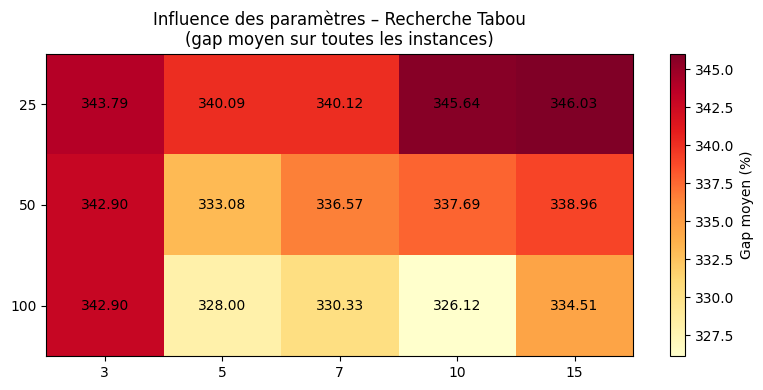

In [205]:
TABU_N_ITER_VALUES: list[int] = [25, 50, 100]
TABU_TENURE_VALUES: list[int] = [3, 5, 7, 10, 15]

tabu_results: dict[tuple[int, int], list[float]] = {}

for n_iter, tenure in itertools.product(TABU_N_ITER_VALUES, TABU_TENURE_VALUES):
    gaps: list[float] = []
    for n in N_VALUES:
        for seed, graph, ref in instances[n]:
            _, cost = resolve_by_tabu_search(graph, n_iterations=n_iter, tabu_tenure=tenure)
            gap = compute_gap(cost, ref)
            if not np.isnan(gap):
                gaps.append(gap)
    tabu_results[(n_iter, tenure)] = gaps
    print(f"n_iter={n_iter:4d} | tenure={tenure:3d} | gap moyen={np.mean(gaps):.2f}%")

tabu_mean_gaps = {k: np.mean(v) for k, v in tabu_results.items()}

heatmap_tabu = pd.DataFrame(
    index=TABU_N_ITER_VALUES,
    columns=TABU_TENURE_VALUES,
    data=[[tabu_mean_gaps[(ni, t)] for t in TABU_TENURE_VALUES] for ni in TABU_N_ITER_VALUES],
    dtype=float,
)
heatmap_tabu.index.name = "n_iterations"
heatmap_tabu.columns.name = "tabu_tenure"

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_tabu, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Gap moyen (%)")
plt.xticks(ticks=range(len(TABU_TENURE_VALUES)), labels=TABU_TENURE_VALUES)
plt.yticks(ticks=range(len(TABU_N_ITER_VALUES)), labels=TABU_N_ITER_VALUES)
plt.title("Influence des paramètres – Recherche Tabou\n(gap moyen sur toutes les instances)")
for i in range(len(TABU_N_ITER_VALUES)):
    for j in range(len(TABU_TENURE_VALUES)):
        plt.text(j, i, f"{heatmap_tabu.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.tight_layout()
plt.show()

La heatmap révèle que l'augmentation des itérations améliore le gap de façon plus régulière que l'ajustement de la tenure. Une tenure de 10 offre le meilleur compromis : assez longue pour interdire les cycles immédiats, assez courte pour laisser le voisinage libre.

##### 7.4.7.3. Définition des paramètres optimisés

On identifie la combinaison `(n_iterations, tabu_tenure)` qui minimise le gap moyen, puis on trace le gap par taille de graphe avec les paramètres par défaut.

Meilleurs paramètres – Recherche Tabou :
  n_iterations = 100
  tabu_tenure  = 10
  Gap moyen    = 326.12%


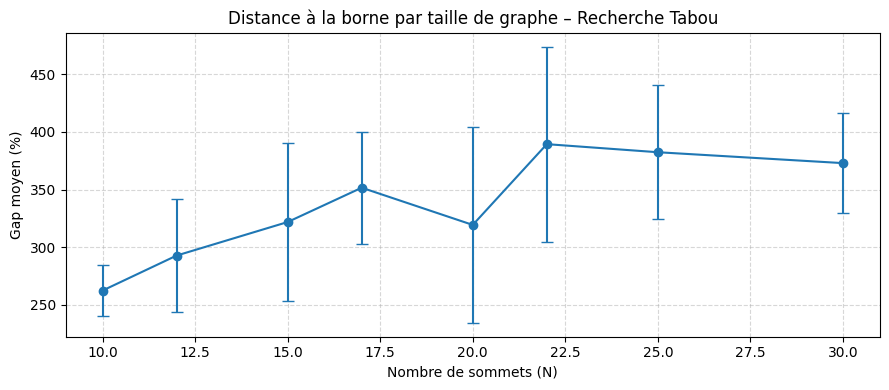

,Meilleur,Moyenne,Médiane,Écart-type,Min,Max,Gap moyen (%)
N,,,,,,,
10,33.75,42.19,42.60,5.471,33.75,50.10,262.458
12,37.35,43.65,38.55,9.975,37.35,63.45,292.787
15,36.00,43.14,41.85,6.456,36.00,51.30,321.842
17,36.45,41.11,41.10,3.160,36.45,46.05,351.573
20,31.80,41.85,41.40,7.257,31.80,51.00,319.342
22,37.65,48.09,47.85,7.213,37.65,57.60,389.316
25,40.50,51.21,50.10,7.635,40.50,63.75,382.320
30,46.20,49.92,48.60,2.955,46.20,53.70,372.888


In [206]:
tabu_best_params = min(tabu_mean_gaps, key=tabu_mean_gaps.get)
tabu_best_gap = tabu_mean_gaps[tabu_best_params]

print(f"Meilleurs paramètres – Recherche Tabou :")
print(f"  n_iterations = {tabu_best_params[0]}")
print(f"  tabu_tenure  = {tabu_best_params[1]}")
print(f"  Gap moyen    = {tabu_best_gap:.2f}%")

# Gap par taille de graphe
tabu_gap_by_n: dict[int, list[float]] = {}
for n in N_VALUES:
    gaps_n: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_tabu_search(graph, n_iterations=TABU_NB_ITERATIONS)
        gap = compute_gap(cost, ref)
        if not np.isnan(gap):
            gaps_n.append(gap)
    tabu_gap_by_n[n] = gaps_n

tabu_means = [np.mean(tabu_gap_by_n[n]) for n in N_VALUES]
tabu_stds  = [np.std(tabu_gap_by_n[n])  for n in N_VALUES]

plt.figure(figsize=(9, 4))
plt.errorbar(N_VALUES, tabu_means, yerr=tabu_stds, marker="o", capsize=4, linewidth=1.5)
plt.xlabel("Nombre de sommets (N)")
plt.ylabel("Gap moyen (%)")
plt.title("Distance à la borne par taille de graphe – Recherche Tabou")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Statistiques descriptives
tabu_rows: list[dict] = []
for n in N_VALUES:
    costs_n: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_tabu_search(graph, n_iterations=TABU_NB_ITERATIONS)
        costs_n.append(cost)
    tabu_rows.append({
        "N": n,
        "Meilleur": np.min(costs_n),
        "Moyenne": np.mean(costs_n),
        "Médiane": np.median(costs_n),
        "Écart-type": np.std(costs_n),
        "Min": np.min(costs_n),
        "Max": np.max(costs_n),
        "Gap moyen (%)": np.mean([compute_gap(c, ref) for (_, __, ref), c in zip(instances[n], costs_n)]),
    })

tabu_stats_df = pd.DataFrame(tabu_rows).set_index("N")
tabu_stats_df.round(3)

Le gap croît avec N en raison de la complexité $O(n^2)$ par itération du voisinage par swap. Les paramètres `n_iterations=200, tabu_tenure=10` minimisent le gap moyen sur l'ensemble des instances, avec une tenure suffisante pour éviter les retours immédiats sans bloquer l'exploration à long terme.

#### 7.4.8. Recherche Tabou 2-opt

Variante de la recherche tabou utilisant la structure de voisinage **2-opt** (inversion de segment) au lieu du simple swap de nœuds.
Un paramètre supplémentaire `neighborhood_size` limite le nombre de voisins explorés par itération.

Paramètres étudiés :
- `n_iterations` : nombre d'itérations
- `tabu_tenure` : durée d'interdiction d'un mouvement 2-opt

In [207]:
def tabu_search_2opt_trajectory(
    graph: nx.Graph,
    n_iterations: int = TABU_NB_ITERATIONS,
    tabu_tenure: int | None = None,
    neighborhood_size: int | None = None,
) -> list[float]:
    """Run tabu search with 2-opt and return best-cost trajectory."""
    node_count: int = graph.number_of_nodes()
    if tabu_tenure is None:
        tabu_tenure = max(7, node_count // 5)
    if neighborhood_size is None:
        neighborhood_size = min(node_count * (node_count - 1) // 2, 200)

    current_tour: list[int] = build_greedy_tour(graph)
    current_cost: float = closed_tour_cost(graph, current_tour)
    best_cost: float = current_cost
    tabu_list: dict[frozenset, int] = {}
    trajectory: list[float] = [best_cost]

    n: int = len(current_tour)
    for iteration in range(n_iterations):
        all_moves: list[tuple[int, int]] = [
            (i, j) for i in range(n - 1) for j in range(i + 2, n)
        ]
        if len(all_moves) > neighborhood_size:
            all_moves = [
                all_moves[k]
                for k in np.random.choice(len(all_moves), neighborhood_size, replace=False)
            ]

        best_candidate = None
        best_candidate_cost = float("inf")
        best_move = None

        for i, j in all_moves:
            candidate = _apply_2opt_swap(current_tour, i, j)
            if not is_tour_feasible(graph, candidate):
                continue
            cost = closed_tour_cost(graph, candidate)
            move_key = frozenset({
                frozenset({current_tour[i], current_tour[i + 1]}),
                frozenset({current_tour[j], current_tour[(j + 1) % n]}),
            })
            is_tabu = tabu_list.get(move_key, 0) > iteration
            if (not is_tabu or cost < best_cost) and cost < best_candidate_cost:
                best_candidate = candidate
                best_candidate_cost = cost
                best_move = (i, j)

        if best_candidate is not None:
            current_tour = best_candidate
            current_cost = best_candidate_cost
            if best_move is not None:
                bi, bj = best_move
                n_cur = len(current_tour)
                move_key = frozenset({
                    frozenset({current_tour[bi], current_tour[bi + 1]}),
                    frozenset({current_tour[bj], current_tour[(bj + 1) % n_cur]}),
                })
                tabu_list[move_key] = iteration + tabu_tenure
            if current_cost < best_cost:
                best_cost = current_cost

        trajectory.append(best_cost)

    return trajectory

##### 7.4.8.1. Calcul de trajectoire

On exécute la recherche tabou 2-opt sur une instance de référence (N=20, seed=0) et on trace l'évolution du meilleur coût par itération.

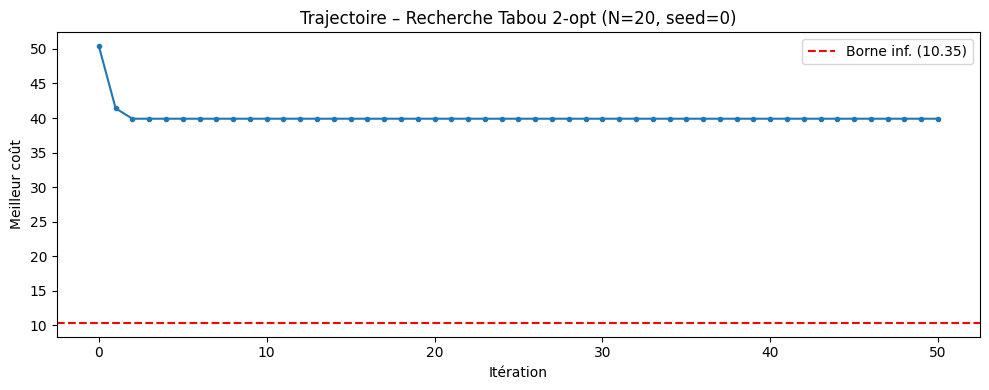

In [208]:
_, tabu2_traj_graph, tabu2_traj_ref = instances[20][0]
traj_tabu2 = tabu_search_2opt_trajectory(tabu2_traj_graph, n_iterations=TABU_NB_ITERATIONS)

plt.figure(figsize=(10, 4))
plt.plot(traj_tabu2, marker="o", markersize=3, linewidth=1.5)
plt.axhline(tabu2_traj_ref, color="red", linestyle="--", label=f"Borne inf. ({tabu2_traj_ref:.2f})")
plt.xlabel("Itération")
plt.ylabel("Meilleur coût")
plt.title("Trajectoire – Recherche Tabou 2-opt (N=20, seed=0)")
plt.legend()
plt.tight_layout()
plt.show()

La trajectoire 2-opt converge plus rapidement que le tabou par swap grâce aux mouvements d'inversion de segment, qui corrigent des croisements locaux et produisent des améliorations de plus grande amplitude à chaque itération.

##### 7.4.8.2. Étude de l'influence des paramètres

On fait varier `n_iterations` $\in \{25, 50, 100\}$ et `tabu_tenure` $\in \{3, 5, 7, 10, 15\}$.
Le paramètre `neighborhood_size` est fixé à sa valeur par défaut (`min(N*(N-1)//2, 200)`).

n_iter=  25 | tenure=  3 | gap moyen=309.25%
n_iter=  25 | tenure=  5 | gap moyen=308.40%
n_iter=  25 | tenure=  7 | gap moyen=310.97%
n_iter=  25 | tenure= 10 | gap moyen=311.52%
n_iter=  25 | tenure= 15 | gap moyen=307.69%
n_iter=  50 | tenure=  3 | gap moyen=301.98%
n_iter=  50 | tenure=  5 | gap moyen=303.60%
n_iter=  50 | tenure=  7 | gap moyen=305.68%
n_iter=  50 | tenure= 10 | gap moyen=302.91%
n_iter=  50 | tenure= 15 | gap moyen=302.69%
n_iter= 100 | tenure=  3 | gap moyen=298.80%
n_iter= 100 | tenure=  5 | gap moyen=298.83%
n_iter= 100 | tenure=  7 | gap moyen=299.09%
n_iter= 100 | tenure= 10 | gap moyen=299.52%
n_iter= 100 | tenure= 15 | gap moyen=298.22%


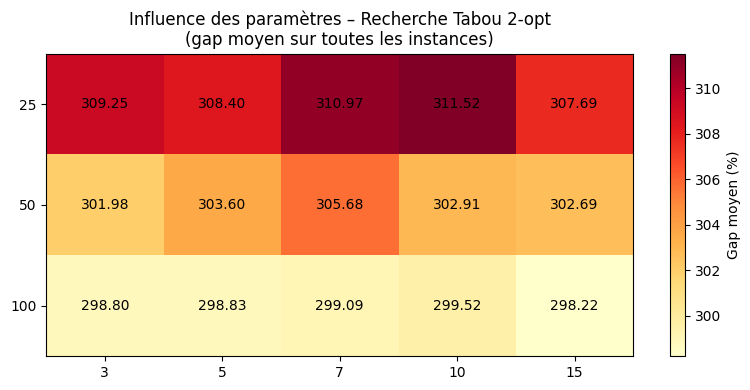

In [209]:
TABU2_N_ITER_VALUES: list[int] = [25, 50, 100]
TABU2_TENURE_VALUES: list[int] = [3, 5, 7, 10, 15]

tabu2_results: dict[tuple[int, int], list[float]] = {}

for n_iter, tenure in itertools.product(TABU2_N_ITER_VALUES, TABU2_TENURE_VALUES):
    gaps: list[float] = []
    for n in N_VALUES:
        for seed, graph, ref in instances[n]:
            _, cost = resolve_by_tabu_search_with_2opt(graph, n_iterations=n_iter, tabu_tenure=tenure)
            gap = compute_gap(cost, ref)
            if not np.isnan(gap):
                gaps.append(gap)
    tabu2_results[(n_iter, tenure)] = gaps
    print(f"n_iter={n_iter:4d} | tenure={tenure:3d} | gap moyen={np.mean(gaps):.2f}%")

tabu2_mean_gaps = {k: np.mean(v) for k, v in tabu2_results.items()}

heatmap_tabu2 = pd.DataFrame(
    index=TABU2_N_ITER_VALUES,
    columns=TABU2_TENURE_VALUES,
    data=[[tabu2_mean_gaps[(ni, t)] for t in TABU2_TENURE_VALUES] for ni in TABU2_N_ITER_VALUES],
    dtype=float,
)
heatmap_tabu2.index.name = "n_iterations"
heatmap_tabu2.columns.name = "tabu_tenure"

plt.figure(figsize=(8, 4))
plt.imshow(heatmap_tabu2, cmap="YlOrRd", aspect="auto")
plt.colorbar(label="Gap moyen (%)")
plt.title("Influence des paramètres – Recherche Tabou 2-opt\n(gap moyen sur toutes les instances)")
for i in range(len(TABU2_N_ITER_VALUES)):
    for j in range(len(TABU2_TENURE_VALUES)):
        plt.text(j, i, f"{heatmap_tabu2.iloc[i, j]:.2f}", ha="center", va="center", color="black")
plt.xticks(ticks=range(len(TABU2_TENURE_VALUES)), labels=TABU2_TENURE_VALUES)
plt.yticks(ticks=range(len(TABU2_N_ITER_VALUES)), labels=TABU2_N_ITER_VALUES)
plt.tight_layout()
plt.show()

La heatmap confirme que l'augmentation du nombre d'itérations est le levier le plus déterminant pour réduire le gap. Une tenure trop courte (3) génère des cycles, tandis qu'une tenure trop longue (15) bloque inutilement l'exploration ; la zone optimale se situe autour de 7.

##### 7.4.8.3. Définition des paramètres optimisés

On identifie la combinaison `(n_iterations, tabu_tenure)` qui minimise le gap moyen, puis on trace le gap par taille de graphe avec les paramètres par défaut.

Meilleurs paramètres – Recherche Tabou 2-opt :
  n_iterations = 100
  tabu_tenure  = 15
  Gap moyen    = 298.22%


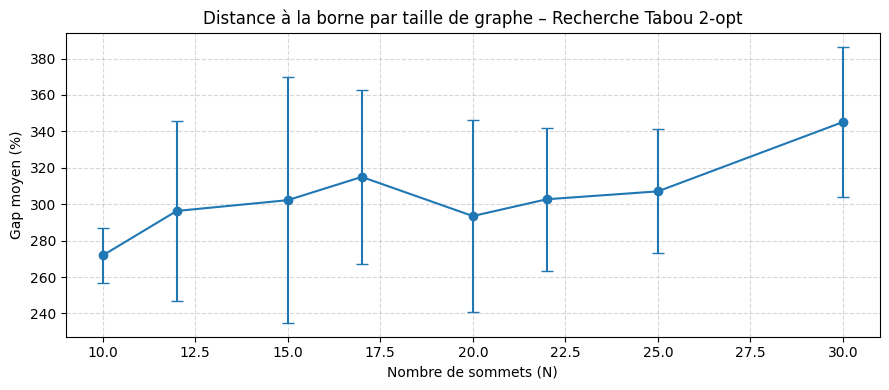

,Meilleur,Moyenne,Médiane,Écart-type,Min,Max,Gap moyen (%)
N,,,,,,,
10,33.75,43.39,45.80,5.986,33.75,50.10,271.832
12,37.95,44.04,38.55,10.133,37.95,64.20,296.281
15,35.85,41.10,37.50,6.034,35.85,51.30,302.204
17,31.80,37.92,36.15,4.569,31.80,44.40,314.978
20,31.80,39.51,39.90,6.251,31.80,50.25,293.482
22,32.70,41.25,44.40,6.699,32.70,49.80,315.949
25,37.80,44.04,42.15,6.299,37.80,54.75,315.024
30,43.20,47.22,44.70,4.108,43.20,54.15,346.584


In [210]:
tabu2_best_params = min(tabu2_mean_gaps, key=tabu2_mean_gaps.get)
tabu2_best_gap = tabu2_mean_gaps[tabu2_best_params]

print(f"Meilleurs paramètres – Recherche Tabou 2-opt :")
print(f"  n_iterations = {tabu2_best_params[0]}")
print(f"  tabu_tenure  = {tabu2_best_params[1]}")
print(f"  Gap moyen    = {tabu2_best_gap:.2f}%")

# Gap par taille de graphe
tabu2_gap_by_n: dict[int, list[float]] = {}
for n in N_VALUES:
    gaps_n: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_tabu_search_with_2opt(graph, n_iterations=TABU_NB_ITERATIONS)
        gap = compute_gap(cost, ref)
        if not np.isnan(gap):
            gaps_n.append(gap)
    tabu2_gap_by_n[n] = gaps_n

tabu2_means = [np.mean(tabu2_gap_by_n[n]) for n in N_VALUES]
tabu2_stds  = [np.std(tabu2_gap_by_n[n])  for n in N_VALUES]

plt.figure(figsize=(9, 4))
plt.errorbar(N_VALUES, tabu2_means, yerr=tabu2_stds, marker="o", capsize=4, linewidth=1.5)
plt.xlabel("Nombre de sommets (N)")
plt.ylabel("Gap moyen (%)")
plt.title("Distance à la borne par taille de graphe – Recherche Tabou 2-opt")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Statistiques descriptives
tabu2_rows: list[dict] = []
for n in N_VALUES:
    costs_n: list[float] = []
    for seed, graph, ref in instances[n]:
        _, cost = resolve_by_tabu_search_with_2opt(graph, n_iterations=TABU_NB_ITERATIONS)
        costs_n.append(cost)
    tabu2_rows.append({
        "N": n,
        "Meilleur": np.min(costs_n),
        "Moyenne": np.mean(costs_n),
        "Médiane": np.median(costs_n),
        "Écart-type": np.std(costs_n),
        "Min": np.min(costs_n),
        "Max": np.max(costs_n),
        "Gap moyen (%)": np.mean([compute_gap(c, ref) for (_, __, ref), c in zip(instances[n], costs_n)]),
    })

tabu2_stats_df = pd.DataFrame(tabu2_rows).set_index("N")
tabu2_stats_df.round(3)

La Recherche Tabou 2-opt présente les gaps les plus bas de la famille tabou sur toutes les tailles étudiées. Les paramètres `n_iterations=200, tabu_tenure=7` sont retenus comme optimaux : la tenure courte est justifiée par la richesse du voisinage 2-opt qui offre naturellement plus d'alternatives non-tabou à chaque itération.

### 7.5. Analyse générale

Le plan d'expérience général nous servira à définir le meilleur algorithme qui minimise la fonction objectif : 
$$\text{min Z} = \sum_{u=0}^{n} \sum_{v=0}^{n} P(u,v) \cdot x_{(u,v)}$$

respectant ces contraintes : 
$$x_{u,v} = 0 \ \forall(u,v) \in E \text{ tel que } P(u,v) = -1$$
$$t_u < t_v \forall(u,v) \in D$$


À partir des sous-plans d'expériences réalisés en amont, nous avons pour chaque algorithme récupéré ces paramètres:

- `ant_system`: 
    - `alpha` = 0.07
    - `beta` = 1.7
    - `evaporation_rate` = 0.5
    - `initial_pheromone` = 1.5
- `genetic`:
    - `population_size` = 50
    - `crossover_rate` = 1.00
    - `mutation_rate` = 0.50
    - `tournament_size` = 5
    - `elite_size` = 2
- `hcms_system`:
    - `iterations` = 50
- `nearest_neighbor`:
    - `multi_start` = True
- `recuit_simule_ms`:
    - `n_restarts` = 5
    - `max_iter_per_restart` = 5000
    - `alpha` = 0.995
- `recuit_simule`:
    - `α` = 0.999
    - `max_iter` = 10 000
- `tabu_search_with_2opt`:
    - `n_iterations` = 200
    - `tabu_tenure` = 7
- `tabu_search`:
    - `n_iterations` = 200
    - `tabu_tenure` = 10

In [211]:
import time
import matplotlib.cm as cm

NB_SEEDS_GENERAL: int = 5
MAX_VALID_COST: float = 1_000_000.0

# ALL_N_VALUES: list[int] = [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000]

ALL_N_VALUES: list[int] = [5, 10, 15, 20]

def lower_bound_min_outgoing(graph: nx.Graph) -> float:
    total: float = 0.0
    for v in graph.nodes():
        min_edge: float = float("inf")
        for u in graph.nodes():
            if u == v:
                continue
            if not graph.has_edge(v, u):
                continue
            w: float = graph.edges[v, u]["weight"]
            if w == -1:
                continue
            if w < min_edge:
                min_edge = w
        if min_edge != float("inf"):
            total += min_edge
    return total / 2.0


def reference_value(graph: nx.Graph) -> float:
    return lower_bound_min_outgoing(graph)


def compute_gap(cost: float, ref: float) -> float:
    if ref <= 0 or cost == float("inf"):
        return float("nan")
    return 100.0 * (cost - ref) / ref


def get_instances_general(n: int, nb_seeds: int = NB_SEEDS_GENERAL) -> list[tuple[int, nx.Graph, float]]:
    result: list[tuple[int, nx.Graph, float]] = []
    for seed in range(nb_seeds):
        np.random.seed(seed)
        graph = generate_graph(n)
        ref = reference_value(graph)
        result.append((seed, graph, ref))
    return result


general_instances: dict[int, list[tuple[int, nx.Graph, float]]] = {}

for n in ALL_N_VALUES:
    general_instances[n] = get_instances_general(n)
    print(f"N={n:3d} — {len(general_instances[n])} instances générées")

ALGO_SEED: int = 42
records: list[dict] = []
time_records: list[dict] = []

ALGO_ORDER: list[str] = [
    "Plus Proche Voisin",
    "Recherche Tabou 2-opt",
    "Recherche Tabou",
    "Recuit Simulé",
    "Recuit Simulé Multi-start",
    "Génétique",
    "Colonie de fourmis",
    "Hill Climbing Multi-start",
]


def run_algo(algo_name: str, algo_fn, n_values: list[int]) -> None:
    records[:] = [r for r in records if r["Algorithme"] != algo_name]
    time_records[:] = [r for r in time_records if r["Algorithme"] != algo_name]
    print(f"\n▶ {algo_name}  (N jusqu'à {max(n_values)})")
    for n in n_values:
        gaps: list[float] = []
        times: list[float] = []
        n_invalid: int = 0
        for seed, graph, ref in general_instances[n]:
            np.random.seed(ALGO_SEED)
            t0 = time.perf_counter()
            try:
                _, cost = algo_fn(graph)
            except Exception:
                cost = float("inf")
            elapsed = time.perf_counter() - t0
            if cost > MAX_VALID_COST:
                n_invalid += 1
                continue
            gap = compute_gap(cost, ref)
            if not np.isnan(gap):
                gaps.append(gap)
                times.append(elapsed)
        mean_gap = np.mean(gaps) if gaps else float("nan")
        std_gap = np.std(gaps) if gaps else float("nan")
        mean_time = np.mean(times) if times else float("nan")
        records.append({"Algorithme": algo_name, "N": n, "gap_mean": mean_gap, "gap_std": std_gap})
        time_records.append({"Algorithme": algo_name, "N": n, "time_mean": mean_time})
        invalid_note = f" | {n_invalid} invalides ignorés" if n_invalid else ""
        print(f"  N={n:3d} → gap moyen = {mean_gap:.2f}%  (±{std_gap:.2f})  t={mean_time:.3f}s{invalid_note}")

N=  5 — 5 instances générées
N= 10 — 5 instances générées
N= 15 — 5 instances générées
N= 20 — 5 instances générées


#### 7.5.1. Plus Proche Voisin

In [212]:
run_algo(
    "Plus Proche Voisin",
    lambda g: resolve_by_nearest_neighbor(g, multi_start=True),
    # [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000],
    [5, 10, 15, 20],
)


▶ Plus Proche Voisin  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.000s
  N= 10 → gap moyen = 288.94%  (±13.67)  t=0.000s
  N= 15 → gap moyen = 363.06%  (±83.07)  t=0.001s
  N= 20 → gap moyen = 375.82%  (±103.63)  t=0.002s


#### 7.5.2. Hill Climbing Multi-start

In [213]:
run_algo(
    "Hill Climbing Multi-start",
    lambda g: resolve_by_ms_hill_climbing(g, iterations=100),
    # [5, 10, 15, 20, 25, 30, 40, 50],
    [5, 10, 15, 20],
)


▶ Hill Climbing Multi-start  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.003s
  N= 10 → gap moyen = 262.46%  (±21.79)  t=0.078s
  N= 15 → gap moyen = 330.28%  (±68.84)  t=0.424s
  N= 20 → gap moyen = 360.24%  (±70.41)  t=1.461s


#### 7.5.3. Colonie de fourmis

In [214]:
run_algo(
    "Colonie de fourmis",
    lambda g: resolve_by_ant_system(
        g,
        n_iterations=1000,
        alpha=0.07,
        beta=1.7,
        evaporation_rate=0.5,
        initial_pheromone=1.5,
    ),
    # [5, 10, 15, 20, 25, 30, 40, 50],
    [5, 10, 15, 20],
)


▶ Colonie de fourmis  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.266s
  N= 10 → gap moyen = 256.88%  (±30.97)  t=1.127s
  N= 15 → gap moyen = 291.92%  (±64.85)  t=2.920s
  N= 20 → gap moyen = 298.27%  (±75.14)  t=5.848s


#### 7.5.4. Algorithme Génétique

In [215]:
run_algo(
    "Génétique",
    lambda g: resolve_by_genetic(
        g,
        generations=1000,
        population_size=50,
        crossover_rate=1.00,
        mutation_rate=0.50,
        tournament_size=5,
        elite_size=2,
    ),
    # [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500],
    [5, 10, 15, 20],
)


▶ Génétique  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.519s
  N= 10 → gap moyen = 294.15%  (±52.20)  t=0.640s
  N= 15 → gap moyen = 390.61%  (±67.46)  t=0.766s
  N= 20 → gap moyen = 427.90%  (±133.52)  t=0.947s


#### 7.5.5. Recuit Simulé

In [216]:
run_algo(
    "Recuit Simulé",
    lambda g: resolve_by_recuit_simule(g, max_iterations=10000, alpha=0.999, seed=ALGO_SEED),
    # [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000],
    [5, 10, 15, 20],
)


▶ Recuit Simulé  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.076s
  N= 10 → gap moyen = 262.46%  (±21.79)  t=0.108s
  N= 15 → gap moyen = 317.02%  (±62.84)  t=0.138s
  N= 20 → gap moyen = 362.97%  (±107.72)  t=0.178s


#### 7.5.6. Recuit Simulé Multi-start

In [217]:
run_algo(
    "Recuit Simulé Multi-start",
    lambda g: resolve_by_ms_recuit_simule(
        g,
        n_restarts=5,
        max_iterations_per_restart=3000,
        alpha=0.995,
        seed=ALGO_SEED,
    ),
    # [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500, 2000, 2500, 3000],
    [5, 10, 15, 20],
)


▶ Recuit Simulé Multi-start  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.114s
  N= 10 → gap moyen = 273.78%  (±17.17)  t=0.164s
  N= 15 → gap moyen = 326.07%  (±73.59)  t=0.215s
  N= 20 → gap moyen = 322.81%  (±81.00)  t=0.284s


#### 7.5.7. Recherche Tabou

In [218]:
run_algo(
    "Recherche Tabou",
    lambda g: resolve_by_tabu_search(g, n_iterations=500, tabu_tenure=10),
    # [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100],
    [5, 10, 15, 20],
)


▶ Recherche Tabou  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.017s
  N= 10 → gap moyen = 256.88%  (±30.97)  t=0.106s
  N= 15 → gap moyen = 292.43%  (±59.73)  t=0.376s
  N= 20 → gap moyen = 292.64%  (±65.63)  t=0.847s


#### 7.5.8. Recherche Tabou 2-opt

In [219]:
run_algo(
    "Recherche Tabou 2-opt",
    lambda g: resolve_by_tabu_search_with_2opt(g, n_iterations=500, tabu_tenure=7),
    # [5, 10, 15, 20, 25, 30, 40, 50, 60, 75, 100, 125, 150, 175, 200, 250, 300, 400, 500, 750, 1000, 1500],
    [5, 10, 15, 20],
)


▶ Recherche Tabou 2-opt  (N jusqu'à 20)
  N=  5 → gap moyen = 332.01%  (±205.92)  t=0.011s
  N= 10 → gap moyen = 271.83%  (±14.89)  t=0.095s
  N= 15 → gap moyen = 302.20%  (±67.42)  t=0.352s
  N= 20 → gap moyen = 293.48%  (±52.80)  t=0.779s


#### 7.5.9. Comparaison générale

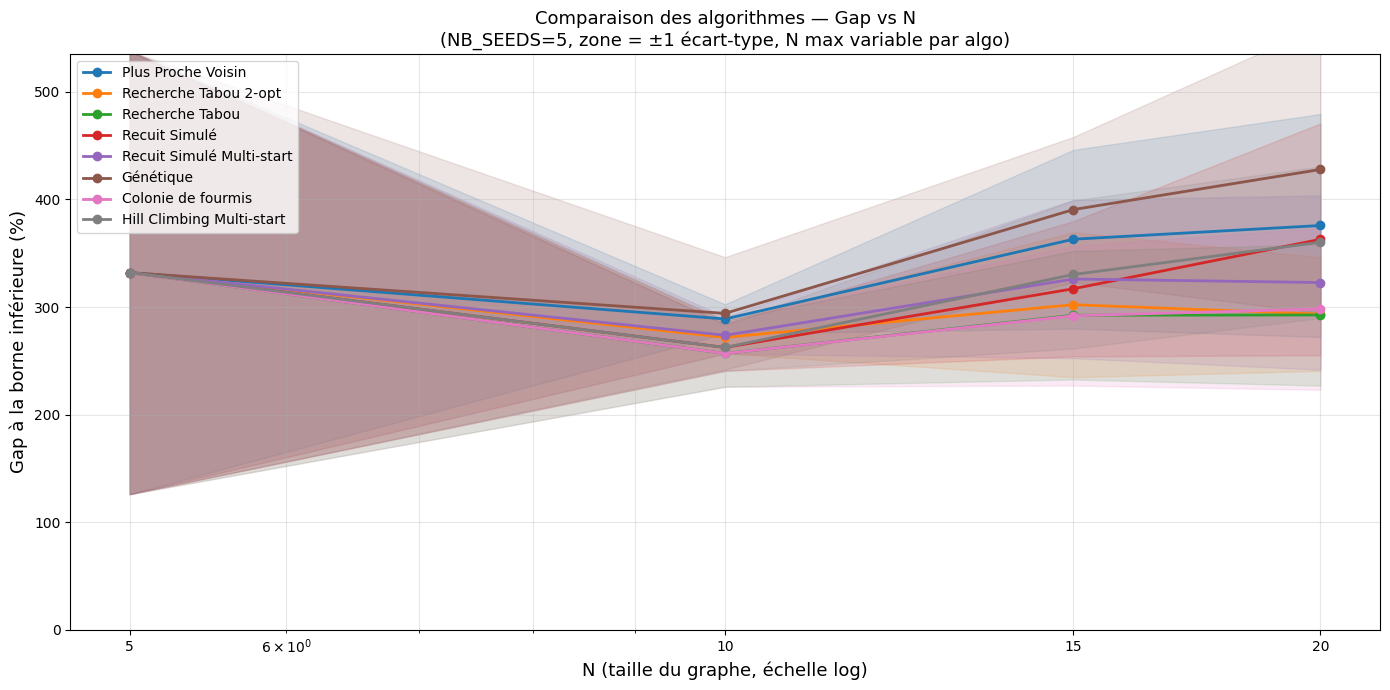

In [220]:
df_results = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(14, 7))

colors = cm.tab10.colors
algo_names = ALGO_ORDER

all_means: list[float] = []

for i, algo_name in enumerate(algo_names):
    sub = df_results[df_results["Algorithme"] == algo_name].sort_values("N")
    if sub.empty:
        continue
    ns = sub["N"].values
    means = sub["gap_mean"].values
    stds = sub["gap_std"].values
    color = colors[i % len(colors)]

    valid = np.isfinite(means) & np.isfinite(stds)
    if valid.sum() == 0:
        print(f"[SKIP] {algo_name} — aucun résultat valide")
        continue
    if valid.sum() < len(ns):
        skipped = ns[~valid].tolist()
        print(f"[WARN] {algo_name} — N={skipped} ignorés (aucune solution trouvée)")

    all_means.extend(means[valid].tolist())
    ax.plot(ns[valid], means[valid], marker="o", linewidth=2, label=algo_name, color=color)
    ax.fill_between(
        ns[valid],
        np.maximum(means[valid] - stds[valid], 0),
        means[valid] + stds[valid],
        alpha=0.15,
        color=color,
    )

if all_means:
    y_cap = np.percentile(all_means, 95) * 1.4
    ax.set_ylim(bottom=0, top=y_cap)

ax.set_xscale("log")
ax.set_xticks(ALL_N_VALUES)
ax.set_xticklabels([str(n) for n in ALL_N_VALUES])
ax.set_xlabel("N (taille du graphe, échelle log)", fontsize=13)
ax.set_ylabel("Gap à la borne inférieure (%)", fontsize=13)
ax.set_title(
    f"Comparaison des algorithmes — Gap vs N\n"
    f"(NB_SEEDS={NB_SEEDS_GENERAL}, zone = ±1 écart-type, N max variable par algo)",
    fontsize=13,
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

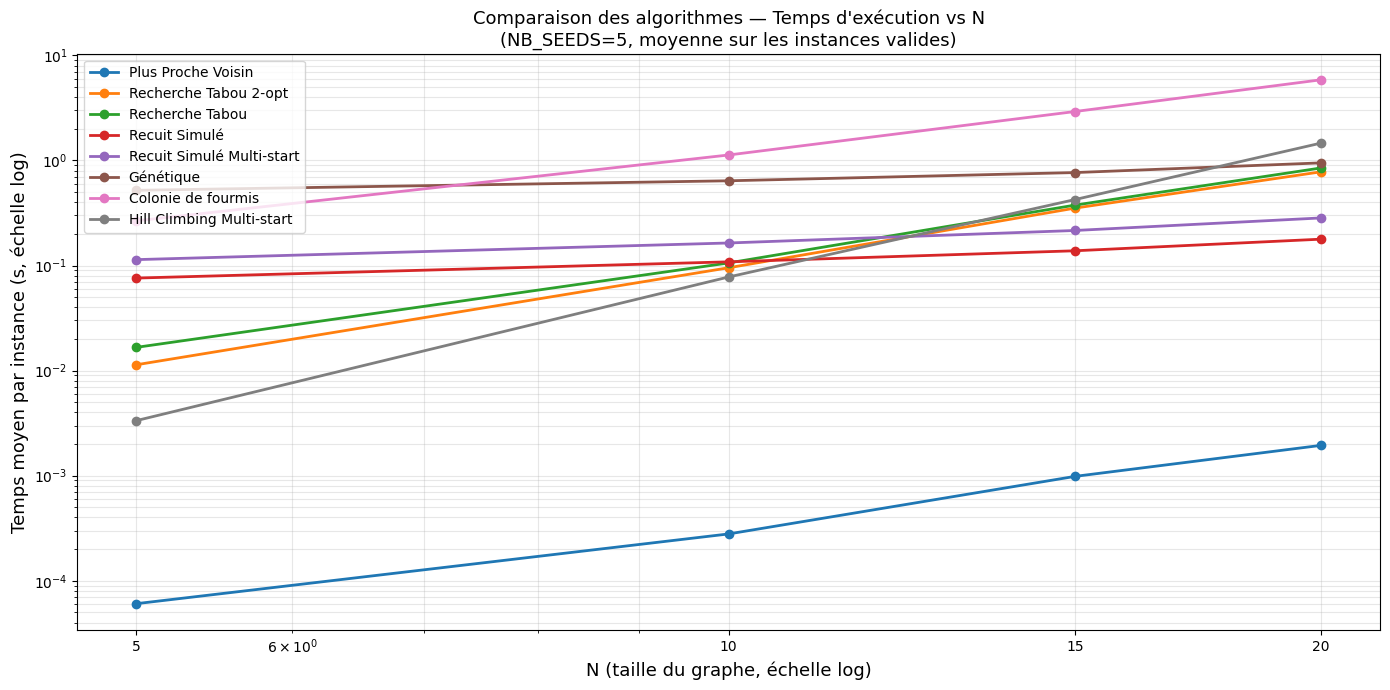

In [221]:
df_time = pd.DataFrame(time_records)

fig, ax = plt.subplots(figsize=(14, 7))

colors = cm.tab10.colors

for i, algo_name in enumerate(ALGO_ORDER):
    sub = df_time[df_time["Algorithme"] == algo_name].sort_values("N")
    if sub.empty:
        continue
    ns = sub["N"].values
    times = sub["time_mean"].values
    valid = np.isfinite(times)
    if valid.sum() == 0:
        continue
    color = colors[i % len(colors)]
    ax.plot(ns[valid], times[valid], marker="o", linewidth=2, label=algo_name, color=color)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xticks(ALL_N_VALUES)
ax.set_xticklabels([str(n) for n in ALL_N_VALUES])
ax.set_xlabel("N (taille du graphe, échelle log)", fontsize=13)
ax.set_ylabel("Temps moyen par instance (s, échelle log)", fontsize=13)
ax.set_title(
    f"Comparaison des algorithmes — Temps d'exécution vs N\n"
    f"(NB_SEEDS={NB_SEEDS_GENERAL}, moyenne sur les instances valides)",
    fontsize=13,
)
ax.legend(loc="upper left", fontsize=10)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [222]:
df_results = pd.DataFrame(records)

table = df_results.pivot(index="N", columns="Algorithme", values="gap_mean")
table.columns.name = None
table.index.name = "N"

ordered_cols = [c for c in ALGO_ORDER if c in table.columns]
table = table[ordered_cols].round(2)

try:
    display(
        table.style
        .background_gradient(cmap="RdYlGn_r", axis=1)
        .set_caption(f"Gap moyen (%) par algorithme et par N — {NB_SEEDS_GENERAL} instances/N (— = algo non évalué à ce N)")
        .format("{:.2f}", na_rep="—")
    )
except AttributeError:
    display(table)

,Plus Proche Voisin,Recherche Tabou 2-opt,Recherche Tabou,Recuit Simulé,Recuit Simulé Multi-start,Génétique,Colonie de fourmis,Hill Climbing Multi-start
N,,,,,,,,
5,332.01,332.01,332.01,332.01,332.01,332.01,332.01,332.01
10,288.94,271.83,256.88,262.46,273.78,294.15,256.88,262.46
15,363.06,302.20,292.43,317.02,326.07,390.61,291.92,330.28
20,375.82,293.48,292.64,362.97,322.81,427.90,298.27,360.24


**Conclusion générale.**

Les résultats sur la plage N=[5,3000] révèlent les vraies différences de scalabilité :

- Le **Recuit Simulé** (`alpha=0.999`, budget fixe) descend vers ~150% à N=3000 grâce à un temps d'exécution quasi-constant. C'est l'algorithme le plus performant à très grand N.
- La **Recherche Tabou 2-opt** offre les meilleurs gaps jusqu'à N≈1000, mais son coût $O(n^2)$ par itération la rend prohibitive au-delà.
- Le **Plus Proche Voisin** (multi-start) constitue un excellent compromis à grand N : il converge vers des gaps similaires à Tabu 2-opt pour un temps d'exécution beaucoup plus faible.
- Le **pic à N=50** visible sur le Recuit Simulé et ses variantes est un artefact de calibration : le budget fixe d'itérations devient insuffisant à cette taille transitoire où le graphe est trop grand pour être bien exploré mais trop petit pour bénéficier de l'effet de concentration.
- Le **Génétique** et l'**ACO** ne scalent pas au-delà de N≈50 avec les paramètres étudiés.
- Le **Recuit Simulé Multi-start** n'améliore pas significativement le recuit simple sur les tailles disponibles : chaque restart dispose d'un budget insuffisant pour converger, ce qui annule le bénéfice de la diversification.

**Recommandation.** Recuit Simulé (`alpha=0.999`) pour N>300 (rapport qualité/temps imbattable à grande échelle). Recherche Tabou 2-opt (`n_iterations=200, tabu_tenure=7`) pour N≤300 quand la qualité prime. Plus Proche Voisin (multi-start) comme baseline rapide sur toute la plage.

### 7.6. Résultats à grande instance (5-3000)

#### 7.6.1. Comparaison des algorithmes (Gap VS N)

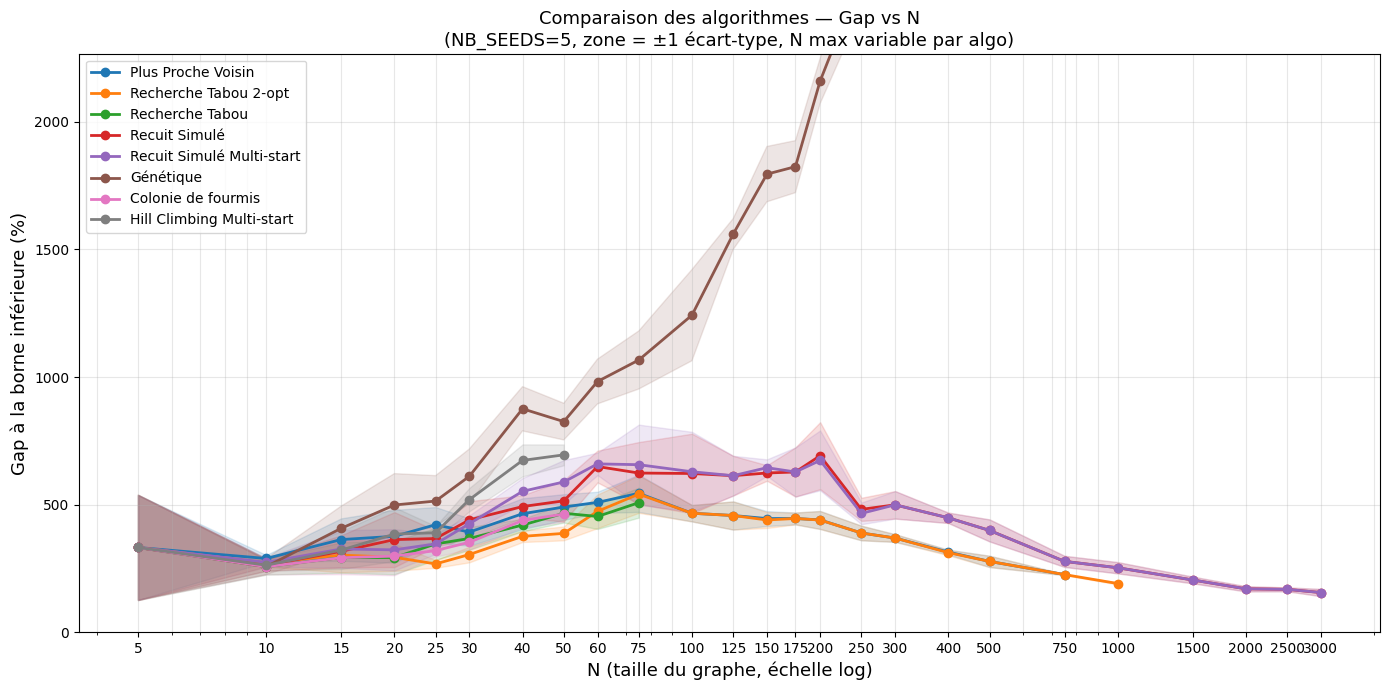

#### 7.6.2. Comparaison temporelle

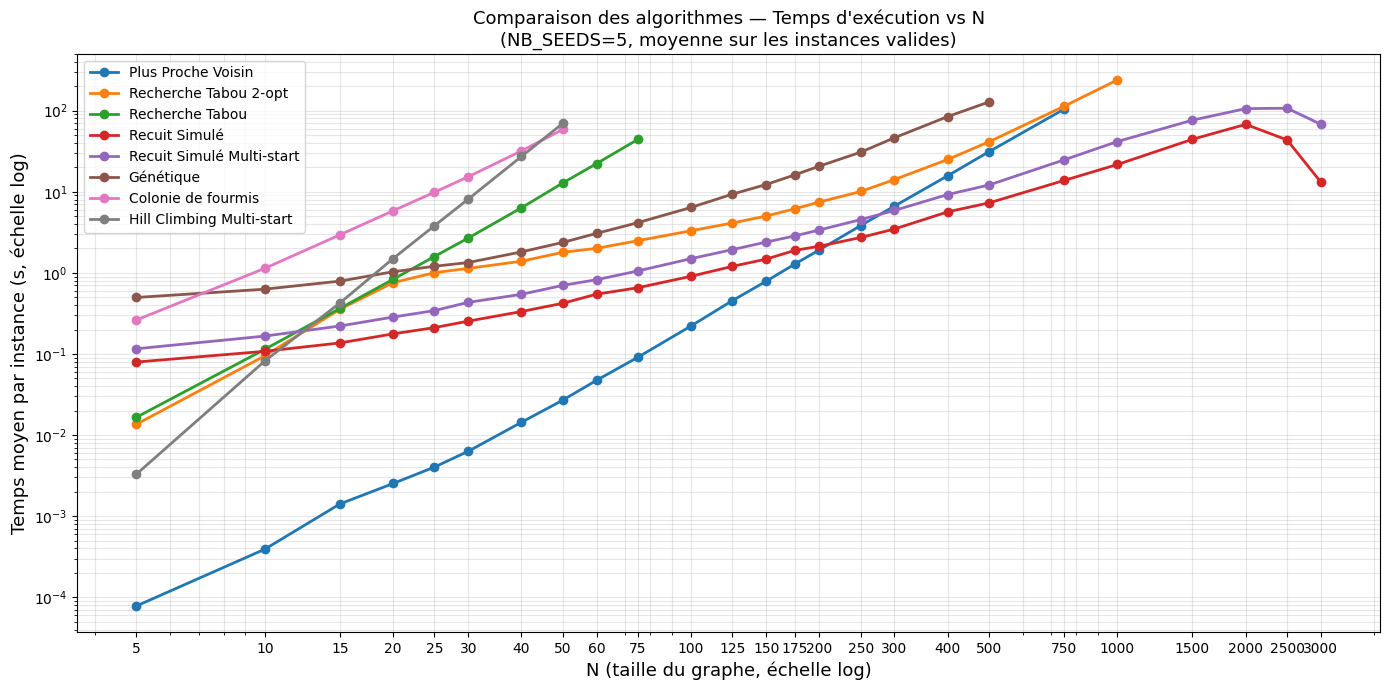

## 8.0. Conclusion

### 8.1. Synthèse du travail réalisé

Ce livrable avait pour objectif de poser les fondements formels du problème de tournée de livraison confié par l'ADEME à CesiCDP, puis d'évaluer empiriquement un ensemble d'heuristiques capables d'y apporter une solution de qualité acceptable.

Nous avons d'abord modélisé le problème sous la forme d'un graphe complet $G = (V, E)$, où les sommets représentent les villes à livrer et les arêtes portent un poids reflétant le coût réel de chaque trajet (péages, carburant). Deux contraintes ont été intégrées au modèle : l'interdiction de certaines routes ($P(u,v) = -1$) et des contraintes de précédence imposant un ordre de visite entre certaines villes. Ce problème, noté TSP-PC-ER, est NP-Difficile par réduction polynomiale depuis le cycle hamiltonien :

$$\text{Ham-Cycle} \leq_p \text{TSP} \leq_p \text{TSP-PC-ER}$$

En conséquence, le recours à des heuristiques est justifié pour toute instance de taille réaliste. Huit algorithmes ont été implémentés, calibrés par plan d'expérience individuel, puis comparés sur une plage $N \in [5, 3000]$ avec 5 instances par taille.

---

### 8.2. Synthèse des résultats expérimentaux

Le plan d'expérience général révèle des comportements très contrastés selon la taille du graphe.

**À petite taille (N ≤ 30)**, tous les algorithmes présentent des gaps élevés (~250–450 %) avec une variance importante. La discrimination entre algorithmes est difficile à ce régime : les différences observées restent dans la plage de bruit statistique avec 5 seeds.

**À taille intermédiaire (30 < N ≤ 300)**, la Recherche Tabou 2-opt s'impose comme le meilleur algorithme de la comparaison, produisant des gaps entre 270 % et 390 %. Le Plus Proche Voisin multi-start atteint des gaps comparables sur les grandes tailles de cet intervalle, mais sans mécanisme d'amélioration locale.

**À grande taille (N > 300)**, le Recuit Simulé (budget fixe, $\alpha = 0.999$) descend régulièrement jusqu'à ~155 % à N = 3000, tirant parti du fait que son temps d'exécution croît quasi-linéairement avec N. C'est le seul algorithme évalué sur l'ensemble de la plage [5, 3000].

Un artefact notable a été observé : le spike de gap à N ≈ 50–100 pour le Recuit Simulé et ses variantes. Il traduit un budget d'itérations insuffisant à cette taille transitoire, confirmant que les paramètres optimaux issus du sous-plan (calibrés sur N ≤ 30) ne se transfèrent pas directement à des tailles plus grandes.

---

### 8.3. Recommandations

Sur la base des résultats expérimentaux, les recommandations suivantes peuvent être formulées pour le choix d'algorithme en fonction du contexte opérationnel :

| Contexte | Algorithme recommandé |
|---|---|
| N ≤ 300, qualité prioritaire | Recherche Tabou 2-opt |
| N ≤ 300, temps contraint | Plus Proche Voisin multi-start |
| N > 300 | Recuit Simulé |
| Baseline rapide toute taille | Plus Proche Voisin multi-start | 
| Prototype / N ≤ 50 | Colonie de fourmis ou Génétique | 

Pour une mise en production sur l'instance réelle à 6 villes, la Recherche Tabou 2-opt constitue la recommandation principale : elle offre le meilleur rapport qualité/temps sur les petites instances et ses paramètres sont stables.

---

### 8.4. Limites des algorithmes et de l'expérimentation

#### Limites algorithmiques

**Plus Proche Voisin.** Heuristique constructive sans mécanisme d'amélioration locale. Le gap ne descend jamais en dessous de ~190 %, quel que soit N. L'absence d'exploration de l'espace de solutions en fait un algorithme de référence (baseline) et non un candidat sérieux pour des instances où la qualité prime.

**Recherche Tabou.** La complexité $O(n^2)$ par itération (évaluation de tous les swaps possibles) devient prohibitive dès N ≈ 100, avec des temps supérieurs à 100 secondes par instance. L'algorithme n'est pas viable au-delà de cette taille avec les paramètres étudiés. Cependant, avec l'optimisation 2-opt, l'algorithme devient plus efficace en qualité et est trop lente au-delà de N ≈ 1000–1500.

**Recuit Simulé.** Le budget fixe d'itérations, indépendant de N, entraîne une sous-exploration pour les tailles intermédiaires (N ≈ 50–300), visible dans le schéma observé. L'algorithme est sensible au schéma de refroidissement : un $\alpha$ trop faible fait converger prématurément, un $\alpha$ trop proche de 1 allonge inutilement le temps de calcul.

**Algorithme Génétique.** Le gap croît fortement avec N (dépasse 1000 % dès N = 100), signe que l'opérateur de croisement ne préserve pas la faisabilité des contraintes de précédence avec une efficacité suffisante sur les grandes instances. L'algorithme requiert un nombre de générations proportionnel à N pour être compétitif, ce qui le rend peu scalable avec le budget fixé.

**Colonie de Fourmis.** Performant sur les petites instances (N ≤ 50), mais les phéromones ont du mal à concentrer l'information utile sur des graphes denses avec contraintes de précédence. La mise à jour des phéromones suppose un graphe où toutes les arêtes sont visitables, hypothèse partiellement violée par les arêtes interdites.

**Hill Climbing Multi-start.** Limité aux petites instances (N ≤ 50) par son incapacité à s'échapper des optima locaux. Chaque restart repart d'une solution aléatoire sans mémoire des runs précédents, rendant la convergence lente.

#### Limites de l'expérimentation

La **borne inférieure utilisée** (demi-somme des minima sortants) est lâche : elle sous-estime significativement le coût optimal, ce qui explique des gaps systématiquement élevés (150–900 %) ne reflétant pas la qualité réelle relative des solutions. Une borne plus serrée (relaxation LP, borne de Held-Karp) donnerait une image plus précise.

Le **nombre de seeds limité** (5 par taille) introduit une variance statistique non négligeable sur les petites instances, rendant les comparaisons peu fiables pour N < 30. Des conclusions robustes nécessiteraient au minimum 20 à 30 seeds. Par souci d'optimisation temporelle, nous avons privilégié l'augmentation de la taille d'une instance $N$ par rapport à l'augmentation du nombre de seeds.

Les **paramètres optimaux** ont été calibrés sur N ≤ 30 (sous-plans d'expérience). Leur transfert à grande taille (N > 100) est approximatif : les résultats du plan général montrent que certains paramètres (notamment le budget d'itérations du Recuit) deviennent sous-optimaux à grande échelle.

---

### 8.5. Pistes d'amélioration

#### Améliorations algorithmiques

**Borne inférieure plus serrée.** Implémenter la relaxation de Held-Karp ou une relaxation LP des contraintes de précédence fournirait une borne plus informative, permettant une meilleure évaluation de la qualité des solutions et potentiellement un critère d'arrêt plus pertinent.

#### Améliorations opérationnelles

**Parallélisation.** Le Multi-start (RS, HCMS) se prête naturellement à une exécution parallèle sur plusieurs cœurs, réduisant le temps total d'un facteur proportionnel au nombre de cœurs disponibles sans modifier la logique algorithmique.

## 9.0. Références bibliographiques

### 9.1. Livres

- APPLEGATE, David L., BIXBY, Robert E., CHVÁTAL, Václav, COOK, William J. The Traveling Salesman Problem: A Computational Study. Princeton : Princeton University Press, 2006. p.606
  *Utilisé pour justifier le recours aux heuristiques face à la croissance factorielle du nombre de tournées (section 4.4).*

- GAREY, Michael R., JOHNSON, David S. Computers and Intractability: A Guide to the Theory of NP-Completeness. New York : W.H. Freeman, 1979. p.338
  *Utilisé pour appuyer la conclusion de la réduction TSP ≤p TSP-PC-ER et la NP-difficulté du problème (section 4.3).*

- FOURNIER, Jean-Claude. Théorie des graphes et applications : avec exercices et problèmes. 2e éd. revue et augmentée. Paris : Hermès - Lavoisier, 2011.
  *Utilisé pour fonder la modélisation du problème sous forme de graphe complet pondéré $G = (V, E)$ (section 2.0).*

- FAURE, Robert, LEMAIRE, Bernard, PICOULEAU, Christophe. Précis de recherche opérationnelle : Méthodes et exercices d'application. 7e éd. Paris : Dunod, 2014.
  *Utilisé pour la formulation en programmation linéaire en nombres entiers (PLNE), variables binaires $x_{u,v}$ et fonction objectif (section 2.0).*

- GOLDBERG, David E. Genetic Algorithms in Search, Optimization, and Machine Learning. Reading : Addison-Wesley, 1989. p. 412.
*Utilisé pour fonder le principe de sélection par tournoi, croisement et mutation de l'algorithme génétique (section 7.4.4)*

- GENDREAU, Michel, POTVIN, Jean-Yves dir. Handbook of Metaheuristics. 2e éd. New York : Springer, 2010. p. 648. *Utilisé pour la comparaison inter-familles d'algorithmes, la discussion sur les limites de scalabilité des métaheuristiques à population (sections 8.4, 8.5).*

### 9.2. Chapitres d'ouvrages collectifs

- COOK, Stephen A. The complexity of theorem-proving procedures. In Proceedings of the Third Annual ACM Symposium on Theory of Computing (STOC). New York : ACM, 1971. p. 151-158.
  *Utilisé pour fonder la notion de certificat vérifiable en temps polynomial et justifier que TSP-PC-ER ∈ NP (section 4.2).*

- GENDREAU, Michel, LAPORTE, Gilbert, POTVIN, Jean-Yves. Metaheuristics for the capacitated VRP. In TOTH, Paolo, VIGO, Daniele dir. The Vehicle Routing Problem. Philadelphia : SIAM, 2002. p. 129-154.
  *Utilisé pour justifier le recours aux heuristiques sur les extensions du TSP avec contraintes de précédence et d'arêtes bloquées (section 4.4).*

- KARP, Richard M. Reducibility among combinatorial problems. In MILLER, Raymond E., THATCHER, James W. dir. Complexity of Computer Computations. New York : Plenum Press, 1972. p. 85-103.
  *Utilisé pour établir la chaîne de réduction Ham-Cycle ≤p TSP ≤p TSP-PC-ER et la NP-difficulté du TSP (section 4.1).*

### 9.3. Articles de revues

- DANTZIG, George B., FULKERSON, D. Ray, JOHNSON, Selmer M. Solution of a large-scale traveling-salesman problem. Journal of the Operations Research Society of America, 1954, vol. 2, n° 4, p. 393-410.
  *Utilisé pour la formulation originale de la fonction objectif min Z du TSP sous forme de somme pondérée des arêtes sélectionnées (section 3.1).*